# **Forecasting NHS 111 Daily Call Demand in England Using Machine Learning**

This project aims to answer:

**Can machine learning models using flu rates, weather conditions and seasonal factors forecast daily NHS 111 call demand in England, and which factors have the greatest influence on demand?**

This notebook prepares and checks the datasets before modelling. The NHS 111 target is kept as originally reported. Missing contract contributions are investigated and flagged, but no target values are estimated or replaced before the time-series split.

# **0. Setup**

Additional Python packages needed for this project are installed here.

In [1]:
# Install required packages

!pip install -q xgboost lightgbm catboost prophet shap optuna odfpy streamlit

print("Installation complete.")

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 717.0/717.0 kB 19.0 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 97.1/97.1 MB 24.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 425.6/425.6 kB 39.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.5/10.5 MB 128.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 267.4/267.4 kB 27.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.4/11.4 MB 121.4 MB/s eta 0:00:00
Installation complete.


# **1. Importing Libraries**

Every library needed for the project is imported here. Google Drive is also mounted and a folder is created so that all prepared outputs can be saved.

In [2]:
import os
import glob
import time
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as stats

from google.colab import drive
drive.mount("/content/drive")

Saved_Outputs = Path("/content/drive/MyDrive/NHS111_Dissertation_Outputs")
Saved_Outputs.mkdir(parents=True, exist_ok=True)
Figures = Saved_Outputs / "Figures"
Models = Saved_Outputs / "Models"
Figures.mkdir(exist_ok=True)
Models.mkdir(exist_ok=True)

from statsmodels.tsa.seasonal import STL
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.stattools import adfuller, kpss
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.stats.diagnostic import acorr_ljungbox
from statsmodels.stats.multitest import multipletests
from prophet import Prophet

from xgboost import XGBRegressor
from lightgbm import LGBMRegressor
from catboost import CatBoostRegressor

from sklearn.model_selection import TimeSeriesSplit
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.inspection import permutation_importance

import optuna
import shap
import joblib

optuna.logging.set_verbosity(optuna.logging.WARNING)

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

plt.rcParams.update({"figure.dpi": 120, "figure.figsize": (10, 5), "font.size": 11})

sns.set_theme(style="whitegrid")

print("Imports complete.")
print(f"Outputs will be saved to: {Saved_Outputs}")

Mounted at /content/drive
Imports complete.
Outputs will be saved to: /content/drive/MyDrive/NHS111_Dissertation_Outputs


# **2. Preparing the Weather Dataset**

The daily mean temperature dataset is loaded and checked for missing values, duplicate dates and date coverage. Only the project period is kept. No temperature values are changed because the prepared file already contains complete daily coverage for the study period.

In [3]:
# Load the weather dataset

weather = pd.read_csv("/content/drive/MyDrive/Datasets for Project/Weather Dataset/meantemp_daily_totals.txt", sep=r"\s+")

# Rename columns and convert data types

weather = weather.rename(columns={"Value": "temp_c"})
weather["Date"] = pd.to_datetime(weather["Date"], errors="coerce")
weather["temp_c"] = pd.to_numeric(weather["temp_c"], errors="coerce")

# Keep the project period

weather = weather[(weather["Date"] >= "2022-07-04") & (weather["Date"] <= "2026-05-31")].copy()

weather = weather.sort_values("Date").reset_index(drop=True)

# Check the dataset

print("Dataset shape:")
print(weather.shape)

print("\nDate range:")
print(weather["Date"].min(), "to", weather["Date"].max())

print("\nMissing values:")
print(weather.isna().sum())

print("\nDuplicate dates:")
print(weather["Date"].duplicated().sum())

display(weather.head())

# Save

weather.to_csv(Saved_Outputs / "weather_prepared.csv", index=False)

print("\nWeather dataset saved.")

Dataset shape:
(1428, 2)

Date range:
2022-07-04 00:00:00 to 2026-05-31 00:00:00

Missing values:
Date      0
temp_c    0
dtype: int64

Duplicate dates:
0


,Date,temp_c
0,2022-07-04,14.7
1,2022-07-05,14.6
2,2022-07-06,16.4
3,2022-07-07,17.9
4,2022-07-08,17.8



Weather dataset saved.


### **Decision**

The larger feature pool is treated as a set of candidates, not as the final model input.

Feature screening is carried out only on an early part of the training period. Hyperparameter tuning then uses later training-period validation windows. Final model comparison uses a still later set of training-period windows. The held-out test remains last.

# **3. Preparing the Flu Dataset**

The influenza positivity data is extracted from the UK Health Security Agency file. Only the date and influenza positivity columns needed for this project are kept. The data is checked before it is joined with the other datasets.

In [4]:
# Load the flu dataset

flu = pd.read_excel(
    "/content/drive/MyDrive/Datasets for Project/Flu Dataset/weekly-influenza-and-COVID-19-report-data-week-27-2026.ods",
    sheet_name="Figure_2",
    engine="odf",
    header=3
)

# Keep and rename required columns

flu = flu.rename(columns={"Positivity (%)": "flu_positivity"})
flu = flu[["Date", "flu_positivity"]].copy()

# Convert data types

flu["Date"] = pd.to_datetime(flu["Date"], errors="coerce")
flu["flu_positivity"] = pd.to_numeric(flu["flu_positivity"], errors="coerce")

# Keep the project period

flu = flu[(flu["Date"] >= "2022-07-04") & (flu["Date"] <= "2026-05-31")].copy()

flu = flu.sort_values("Date").reset_index(drop=True)

# Check the dataset

print("Dataset shape:")
print(flu.shape)

print("\nDate range:")
print(flu["Date"].min(), "to", flu["Date"].max())

print("\nMissing values:")
print(flu.isna().sum())

print("\nDuplicate dates:")
print(flu["Date"].duplicated().sum())

display(flu.head())

# Save

flu.to_csv(Saved_Outputs / "flu_prepared.csv", index=False)

print("\nFlu dataset saved.")

Dataset shape:
(1428, 2)

Date range:
2022-07-04 00:00:00 to 2026-05-31 00:00:00

Missing values:
Date              0
flu_positivity    0
dtype: int64

Duplicate dates:
0


,Date,flu_positivity
0,2022-07-04,0.3
1,2022-07-05,0.4
2,2022-07-06,0.5
3,2022-07-07,0.5
4,2022-07-08,0.5



Flu dataset saved.


### **Decision**

The flu dataset also has daily coverage for the project period. It is kept unchanged at this stage. Whether same-day flu information would genuinely have been available at forecast time will be checked later before modelling.

# **4. Preparing the Bank Holiday Dataset**

The bank holiday data is obtained from the GOV.UK Bank Holidays API. Only England and Wales bank holidays within the project period are kept.

In [5]:
# Load the bank holiday data

bank_holidays_url = "https://www.gov.uk/bank-holidays.json"
bank_holidays = pd.read_json(bank_holidays_url)

# Keep England and Wales

bank_holidays = pd.DataFrame(bank_holidays["england-and-wales"]["events"])

# Keep and rename required columns

bank_holidays = bank_holidays[["date", "title"]].copy()

bank_holidays = bank_holidays.rename(columns={"date": "Date", "title": "holiday_name"})

# Convert date

bank_holidays["Date"] = pd.to_datetime(bank_holidays["Date"], errors="coerce")

# Keep the project period

bank_holidays = bank_holidays[(bank_holidays["Date"] >= "2022-07-04") & (bank_holidays["Date"] <= "2026-05-31")].copy()

bank_holidays = bank_holidays.sort_values("Date").reset_index(drop=True)

# Check

print("Dataset shape:")
print(bank_holidays.shape)

print("\nDate range:")
print(bank_holidays["Date"].min(), "to", bank_holidays["Date"].max())

print("\nMissing values:")
print(bank_holidays.isna().sum())

print("\nDuplicate dates:")
print(bank_holidays["Date"].duplicated().sum())

display(bank_holidays.head())

# Save

bank_holidays.to_csv(Saved_Outputs / "bank_holidays_prepared.csv", index=False)

print("\nBank holiday dataset saved.")

Dataset shape:
(34, 2)

Date range:
2022-08-29 00:00:00 to 2026-05-25 00:00:00

Missing values:
Date            0
holiday_name    0
dtype: int64

Duplicate dates:
0


,Date,holiday_name
0,2022-08-29,Summer bank holiday
1,2022-09-19,Bank Holiday for the State Funeral of Queen El...
2,2022-12-26,Boxing Day
3,2022-12-27,Christmas Day
4,2023-01-02,New Year’s Day



Bank holiday dataset saved.


# **5. Preparing the NHS 111 Dataset**

The monthly NHS 111 files are combined and only A01 records are kept. A01 represents total calls offered. Dates and call values are converted to the correct data types and only the project period is retained.

Missing and zero A01 values are **not changed here**. They are kept exactly as reported so that the reporting structure can be investigated first.

In [6]:
# Get all monthly NHS 111 files

files = sorted(glob.glob("/content/drive/MyDrive/Datasets for Project/nhs111 data/Provisional-IUCADC*.csv"))

print("Number of files:", len(files))

if len(files) == 0:
    raise FileNotFoundError("No NHS 111 files were found.")

# Read and combine the files

datasets = []

for file in files:
    df = pd.read_csv(file, low_memory=False)

    df.columns = df.columns.str.strip()
    df = df.rename(columns={"DATE": "Date"})
    df = df.loc[:, ~df.columns.str.startswith("Unnamed")]
    df["source_file"] = Path(file).name

    datasets.append(df)

nhs111 = pd.concat(datasets, ignore_index=True)

print("\nCombined dataset size:")
print(nhs111.shape)

print("\nColumn names:")
print(nhs111.columns.tolist())

Number of files: 62

Combined dataset size:
(1937468, 10)

Column names:
['REPORTING_PERIOD', 'ORG_CODE', 'ORG_NAME', 'CONTRACT_CODE', 'CONTRACT_NAME', 'DAY', 'ITEM_NUMBER', 'VALUE', 'Date', 'source_file']


In [7]:
# Keep A01 records

nhs111["ITEM_NUMBER"] = nhs111["ITEM_NUMBER"].astype(str).str.strip()
nhs111 = nhs111[nhs111["ITEM_NUMBER"] == "A01"].copy()

# Convert dates

original_date = nhs111["Date"].astype(str).str.strip()

nhs111["Date"] = pd.to_datetime(original_date, dayfirst=True, errors="coerce")

# Convert Excel serial dates if needed

date_mask = nhs111["Date"].isna()

nhs111.loc[date_mask, "Date"] = pd.to_datetime(
    pd.to_numeric(original_date[date_mask], errors="coerce"),
    unit="D",
    origin="1899-12-30",
    errors="coerce"
)

# Convert A01 values

nhs111["VALUE"] = nhs111["VALUE"].replace("-", np.nan)

nhs111["VALUE"] = pd.to_numeric(nhs111["VALUE"], errors="coerce")

# Keep the project period

nhs111 = nhs111[(nhs111["Date"] >= "2022-07-04") & (nhs111["Date"] <= "2026-05-31")].copy()

nhs111 = nhs111.sort_values(["Date", "CONTRACT_CODE"]).reset_index(drop=True)

# Check

print("Dataset size:")
print(nhs111.shape)

print("\nDate range:")
print(nhs111["Date"].min(), "to", nhs111["Date"].max())

display(nhs111.head())

# Save

nhs111.to_csv(Saved_Outputs / "nhs111_A01_prepared.csv", index=False)

print("\nPrepared NHS 111 A01 data saved.")

Dataset size:
(45748, 10)

Date range:
2022-07-04 00:00:00 to 2026-05-31 00:00:00


,REPORTING_PERIOD,ORG_CODE,ORG_NAME,CONTRACT_CODE,CONTRACT_NAME,DAY,ITEM_NUMBER,VALUE,Date,source_file
0,IUCADC-WEEK-ENDING-10-Jul-2022,RX6,North East Ambulance Service NHS Foundation Trust,111AA1,North East,Mon,A01,3093.0,2022-07-04,Provisional-IUCADC-Raw-Jul22-1.csv
1,IUCADC-WEEK-ENDING-10-Jul-2022,R1F,Isle of Wight NHS Trust,111AA6,Isle of Wight,Mon,A01,312.0,2022-07-04,Provisional-IUCADC-Raw-Jul22-1.csv
2,IUCADC-WEEK-ENDING-10-Jul-2022,Y00415,HUC,111AB2,Hertfordshire,Mon,A01,1368.0,2022-07-04,Provisional-IUCADC-Raw-Jul22-1.csv
3,IUCADC-WEEK-ENDING-10-Jul-2022,Y00415,HUC,111AC5,Cambridgeshire and Peterborough,Mon,A01,1167.0,2022-07-04,Provisional-IUCADC-Raw-Jul22-1.csv
4,IUCADC-WEEK-ENDING-10-Jul-2022,NNJ,DHU HealthCare CIC,111AC6,Northamptonshire,Mon,A01,929.0,2022-07-04,Provisional-IUCADC-Raw-Jul22-1.csv



Prepared NHS 111 A01 data saved.


# **6. NHS 111 Data Quality**

Before calculating the England daily total, the NHS 111 reporting structure is investigated. This is important because a contract can start, stop, change name or be replaced. A missing value does not automatically mean England demand is missing.

The aim of this section is to separate normal contract changes from genuine reporting problems. The original A01 values remain unchanged throughout this section.

## **6.1 Initial Data Quality Checks**

The first check looks for missing values, duplicate reporting records, negative values, zero values and completely missing calendar dates.

In [8]:
# Missing values

print("Missing values:")
print(nhs111[["Date", "VALUE"]].isna().sum())

# Duplicate reporting records

key_columns = ["Date", "ORG_CODE", "CONTRACT_CODE", "ITEM_NUMBER"]

print("\nDuplicate reporting records:")
print(nhs111.duplicated(subset=key_columns).sum())

# Invalid values

print("\nNegative call values:")
print((nhs111["VALUE"] < 0).sum())

print("\nZero call values:")
print((nhs111["VALUE"] == 0).sum())

# Calendar coverage

expected_dates = pd.date_range("2022-07-04", "2026-05-31", freq="D")

missing_dates = expected_dates.difference(nhs111["Date"].dropna().unique())

print("\nCompletely missing calendar dates:")
print(len(missing_dates))

Missing values:
Date       0
VALUE    143
dtype: int64

Duplicate reporting records:
0

Negative call values:
0

Zero call values:
13

Completely missing calendar dates:
0


### **Finding**

The source contains **143 missing A01 values** and some zero values, but every calendar date in the study period appears somewhere in the NHS 111 data. Therefore, the main question is whether all expected contracts contributed to each England daily total.

## **6.2 Checking Daily Reporting Coverage**

The number of organisations and contracts appearing each day is checked. Contract counts can change because of service changes, so a lower daily count is not automatically treated as missing reporting.

In [9]:
# Daily reporting coverage

daily_coverage = nhs111.groupby("Date").agg(
    records=("VALUE", "size"),
    organisations=("ORG_CODE", "nunique"),
    contracts=("CONTRACT_CODE", "nunique")
).reset_index()

missing_A01 = (nhs111[nhs111["VALUE"].isna()] .groupby("Date") .size())

daily_coverage["missing_A01"] = (daily_coverage["Date"] .map(missing_A01) .fillna(0) .astype(int))

print("Daily reporting coverage:")
display(daily_coverage.head())

print("\nContract count range:")
print(daily_coverage["contracts"].min(), "to", daily_coverage["contracts"].max())

print("\nNumber of days by contract count:")

coverage_counts = (daily_coverage["contracts"] .value_counts() .sort_index() .reset_index())

coverage_counts.columns = ["contracts", "days"]

display(coverage_counts)

daily_coverage.to_csv(Saved_Outputs / "nhs111_daily_coverage.csv", index=False)

Daily reporting coverage:


,Date,records,organisations,contracts,missing_A01
0,2022-07-04,35,19,35,0
1,2022-07-05,35,19,35,0
2,2022-07-06,35,19,35,0
3,2022-07-07,35,19,35,0
4,2022-07-08,35,19,35,0



Contract count range:
27 to 38

Number of days by contract count:


,contracts,days
0,27,7
1,28,462
2,29,123
3,30,185
4,32,7
5,33,14
6,34,21
7,35,189
8,36,63
9,37,343


### **Decision**

The number of contracts changes across the study period, so I will not assume that England should always have a fixed number of reporting contracts. Contract starts, endings and replacements are checked next.

## **6.3 Understanding Organisations and Contracts**

Organisation and contract codes are checked against their names. Names can change even when the same contract continues, so the most stable identifier is needed for the reporting checks.

In [10]:
# Count unique codes

print("Unique organisation codes:")
print(nhs111["ORG_CODE"].nunique())

print("\nUnique contract codes:")
print(nhs111["CONTRACT_CODE"].nunique())

# Organisation names per organisation code

org_name_count = (nhs111.groupby("ORG_CODE")["ORG_NAME"] .nunique() .reset_index(name="organisation_names"))

org_name_changes = org_name_count[org_name_count["organisation_names"] > 1]

print("\nOrganisation codes with more than one name:")
display(org_name_changes)

# Contract names per contract code

contract_name_count = (nhs111.groupby("CONTRACT_CODE")["CONTRACT_NAME"] .nunique() .reset_index(name="contract_names"))

contract_name_changes = contract_name_count[contract_name_count["contract_names"] > 1]

print("\nContract codes with more than one name:")
display(contract_name_changes)

# Organisation codes per contract

contract_org_count = (nhs111.groupby("CONTRACT_CODE")["ORG_CODE"] .nunique() .reset_index(name="organisation_codes"))

contract_org_changes = contract_org_count[contract_org_count["organisation_codes"] > 1]

print("\nContracts linked to more than one organisation code:")
display(contract_org_changes)

Unique organisation codes:
21

Unique contract codes:
47

Organisation codes with more than one name:


,ORG_CODE,organisation_names
0,00R,9
1,0AR,7
4,8J296,8
5,D2P2L,8
6,NBP,5
7,NKB,6
8,NLO,5
9,NNJ,9
11,NTP,13
12,NVE,12



Contract codes with more than one name:


,CONTRACT_CODE,contract_names
40,111AL6,2
46,111SA1,2



Contracts linked to more than one organisation code:


,CONTRACT_CODE,organisation_codes


In [11]:
# Save simple organisation and contract maps

organisation_map = (nhs111[["ORG_CODE", "ORG_NAME"]] .drop_duplicates() .sort_values("ORG_CODE"))

contract_map = (
    nhs111[["ORG_CODE", "ORG_NAME", "CONTRACT_CODE", "CONTRACT_NAME"]]
    .drop_duplicates()
    .sort_values(["ORG_CODE", "CONTRACT_CODE"])
)

organisation_map.to_csv(Saved_Outputs / "nhs111_organisation_map.csv", index=False)

contract_map.to_csv(Saved_Outputs / "nhs111_contract_map.csv", index=False)

print("Organisation and contract maps saved.")

Organisation and contract maps saved.


### **Decision**

Contract names are not fully stable, while each `CONTRACT_CODE` stays linked to one organisation code. I therefore use `CONTRACT_CODE` as the main reporting identifier for the remaining checks.

## **6.4 Checking Contract Reporting Periods**

The first and last date on which each contract appears is checked. Contracts that end before May 2026 are investigated rather than automatically being treated as missing.

In [12]:
# Reporting period for each contract code

contract_periods = nhs111.groupby("CONTRACT_CODE").agg(start_date=("Date", "min"), end_date=("Date", "max")).reset_index()

print("Contract reporting periods:")
display(contract_periods.sort_values("end_date"))

# Contracts that ended before the project ended

ended_contracts = contract_periods[contract_periods["end_date"] < pd.Timestamp("2026-05-31")].copy()

print("\nNumber of contracts that ended:")
print(len(ended_contracts))

display(ended_contracts.sort_values("end_date"))

Contract reporting periods:


,CONTRACT_CODE,start_date,end_date
29,111AJ4,2022-07-04,2022-07-31
23,111AI6,2022-07-04,2022-10-02
8,111AF1,2022-07-04,2022-12-04
31,111AK5,2022-07-04,2023-03-05
17,111AH8,2022-07-04,2023-04-02
27,111AJ2,2022-07-04,2023-04-30
46,111SA1,2023-02-06,2024-03-03
9,111AF4,2022-07-04,2024-04-14
32,111AK6,2022-07-04,2024-04-14
33,111AK7,2022-07-04,2024-04-14



Number of contracts that ended:
19


,CONTRACT_CODE,start_date,end_date
29,111AJ4,2022-07-04,2022-07-31
23,111AI6,2022-07-04,2022-10-02
8,111AF1,2022-07-04,2022-12-04
31,111AK5,2022-07-04,2023-03-05
17,111AH8,2022-07-04,2023-04-02
27,111AJ2,2022-07-04,2023-04-30
46,111SA1,2023-02-06,2024-03-03
9,111AF4,2022-07-04,2024-04-14
30,111AJ8,2022-07-04,2024-04-14
4,111AC6,2022-07-04,2024-04-14


### **Finding**

Nineteen contract codes end before the end of the study period. Their endings are checked against new contract starts before deciding whether they represent missing reporting.

## **6.5 Checking Possible Contract Replacements**

For each ended contract, contracts starting within 14 days of the end date are identified. This is only a screening check: a similar date does not by itself prove that one contract replaced another.

In [13]:
# Find contracts starting around each ended contract

possible_replacements = []

for _, old in ended_contracts.iterrows():

    nearby = contract_periods[
        (contract_periods["start_date"] >= old["end_date"] - pd.Timedelta(days=14)) &
        (contract_periods["start_date"] <= old["end_date"] + pd.Timedelta(days=14)) &
        (contract_periods["CONTRACT_CODE"] != old["CONTRACT_CODE"])
    ]

    for _, new in nearby.iterrows():

        possible_replacements.append([
            old["CONTRACT_CODE"],
            old["end_date"],
            new["CONTRACT_CODE"],
            new["start_date"],
            new["end_date"]
        ])

possible_replacements = pd.DataFrame(possible_replacements, columns=["old_code", "old_end", "new_code", "new_start", "new_end"])

possible_replacements["gap_days"] = (possible_replacements["new_start"] - possible_replacements["old_end"]).dt.days - 1

print("Possible contract replacements:")
display(possible_replacements)

matched_codes = possible_replacements["old_code"].unique()

no_replacement = ended_contracts[~ended_contracts["CONTRACT_CODE"].isin(matched_codes)]

print("\nEnded contracts with no nearby replacement:")
display(no_replacement)

Possible contract replacements:


,old_code,old_end,new_code,new_start,new_end,gap_days
0,111AB2,2024-10-13,111AM1,2024-10-14,2026-05-31,0
1,111AC6,2024-04-14,111AL7,2024-04-08,2026-05-31,-7
2,111AD5,2024-07-31,111AL9,2024-08-05,2026-05-31,4
3,111AF1,2022-12-04,111AL3,2022-11-28,2026-05-31,-7
4,111AF4,2024-04-14,111AL7,2024-04-08,2026-05-31,-7
5,111AH2,2024-11-24,111AL8,2024-11-18,2026-05-31,-7
6,111AH8,2023-04-02,111AL5,2023-03-27,2026-05-31,-7
7,111AI3,2024-10-13,111AM1,2024-10-14,2026-05-31,0
8,111AI6,2022-10-02,111AL2,2022-09-26,2026-05-31,-7
9,111AJ2,2023-04-30,111AL6,2023-04-24,2026-05-31,-7



Ended contracts with no nearby replacement:


,CONTRACT_CODE,start_date,end_date
45,111NR1,2023-02-06,2025-02-16
46,111SA1,2023-02-06,2024-03-03


### **Finding**

Most ended contracts have another contract starting around the same period. Two contracts, `111NR1` and `111SA1`, do not have a nearby replacement and are checked separately as national support services.

## **6.6 Checking Gaps Between Contract Transitions**

A positive gap means the old contract stopped before the possible replacement started. These gaps are important because an area may be absent from the England total for those dates.

In [14]:
# Positive transition gaps

transition_gaps = possible_replacements[possible_replacements["gap_days"] > 0].copy()

print("Contract transitions with a positive gap:")
display(transition_gaps)

print("\nNumber of transitions with a gap:")
print(len(transition_gaps))

Contract transitions with a positive gap:


,old_code,old_end,new_code,new_start,new_end,gap_days
2,111AD5,2024-07-31,111AL9,2024-08-05,2026-05-31,4



Number of transitions with a gap:
1


### **Finding**

The main positive gap is the North Central London transition. The old contract ends on 31 July 2024 and the new contract starts on 5 August 2024, leaving four dates with no North Central London contract reporting.

## **6.7 Investigating the North Central London Gap**

North Central London is checked directly around the transition to confirm whether any A01 records exist during the four-day gap.

In [15]:
# North Central London records

ncl = nhs111[nhs111["CONTRACT_NAME"].str.contains("North Central London", case=False, na=False)].copy()

ncl_transition = ncl[(ncl["Date"] >= "2024-07-25") & (ncl["Date"] <= "2024-08-10")]

print("North Central London transition:")
display(ncl_transition[["Date", "CONTRACT_CODE", "CONTRACT_NAME", "VALUE"]].sort_values("Date"))

# Four dates with no North Central London record

ncl_gap_dates = pd.DataFrame({"Date": pd.date_range("2024-08-01", "2024-08-04")})

print("\nKnown North Central London coverage gap:")
display(ncl_gap_dates)

ncl_gap_dates.to_csv(Saved_Outputs / "nhs111_ncl_gap_dates.csv", index=False)

North Central London transition:


,Date,CONTRACT_CODE,CONTRACT_NAME,VALUE
26541,2024-07-25,111AD5,North Central London,1020.0
26571,2024-07-26,111AD5,North Central London,1163.0
26601,2024-07-27,111AD5,North Central London,1290.0
26631,2024-07-28,111AD5,North Central London,1126.0
26661,2024-07-29,111AD5,North Central London,1194.0
26691,2024-07-30,111AD5,North Central London,1150.0
26721,2024-07-31,111AD5,North Central London,592.0
26890,2024-08-05,111AL9,North Central London (LAS),1076.0
26920,2024-08-06,111AL9,North Central London (LAS),927.0
26950,2024-08-07,111AL9,North Central London (LAS),1032.0



Known North Central London coverage gap:


,Date
0,2024-08-01
1,2024-08-02
2,2024-08-03
3,2024-08-04


### **Decision**

The four dates are **not removed and not estimated at this stage**. The rest of England still reported on those dates, so the reported national total is kept but the dates will be flagged as having a known coverage gap.

## **6.8 Checking Overlapping Contract Transitions**

Some contract replacements overlap. An overlap does not automatically mean double counting because calls may gradually move from the old contract to the new one. Cornwall and the large Midlands transition are checked before deciding how overlapping values should be treated.

In [16]:
# Cornwall transition

cornwall = nhs111[nhs111["CONTRACT_CODE"].isin(["111AF1", "111AL3"])].copy()

cornwall = cornwall[(cornwall["Date"] >= "2022-11-21") & (cornwall["Date"] <= "2022-12-11")]

cornwall_check = cornwall.pivot(index="Date", columns="CONTRACT_CODE", values="VALUE").reset_index()

cornwall_check["combined_A01"] = (cornwall_check[["111AF1", "111AL3"]] .sum(axis=1))

cornwall_check["period"] = "Before"

cornwall_check.loc[(cornwall_check["Date"] >= "2022-11-28") & (cornwall_check["Date"] <= "2022-12-04"), "period"] = "Overlap"

cornwall_check.loc[cornwall_check["Date"] > "2022-12-04", "period"] = "After"

print("Cornwall calls around the transition:")
display(cornwall_check)

print("\nCornwall transition summary:")

cornwall_summary = (cornwall_check.groupby("period")["combined_A01"] .agg(["count", "mean", "median"]) .reset_index())

display(cornwall_summary)

Cornwall calls around the transition:


CONTRACT_CODE,Date,111AF1,111AL3,combined_A01,period
0,2022-11-21,494.0,NaN,494.0,Before
1,2022-11-22,424.0,NaN,424.0,Before
2,2022-11-23,447.0,NaN,447.0,Before
3,2022-11-24,347.0,NaN,347.0,Before
4,2022-11-25,475.0,NaN,475.0,Before
5,2022-11-26,980.0,NaN,980.0,Before
6,2022-11-27,865.0,NaN,865.0,Before
7,2022-11-28,492.0,0.0,492.0,Overlap
8,2022-11-29,292.0,0.0,292.0,Overlap
9,2022-11-30,107.0,316.0,423.0,Overlap



Cornwall transition summary:


,period,count,mean,median
0,After,7,1165.285714,910.0
1,Before,7,576.000000,475.0
2,Overlap,7,613.142857,466.0


### **Cornwall Decision**

The old Cornwall contract falls as the new contract begins reporting, while the combined overlap total remains close to the preceding week. This looks like a handover rather than obvious double counting. Both reported values are therefore retained.

In [17]:
# Midlands transition

old_midlands = ["111AC6", "111AF4", "111AJ8", "111AK6", "111AK7", "111AL1", "111AL4"]

midlands_codes = old_midlands + ["111AL7"]

midlands_transition = nhs111[
    nhs111["CONTRACT_CODE"].isin(midlands_codes) &
    (nhs111["Date"] >= "2024-04-08") &
    (nhs111["Date"] <= "2024-04-14")
].copy()

# Old contracts

old_transition = midlands_transition[midlands_transition["CONTRACT_CODE"].isin(old_midlands)]

old_daily = (old_transition.groupby("Date")["VALUE"] .agg(["sum", "count"]) .reset_index())

old_daily.columns = ["Date", "old_A01", "old_contracts_reported"]

old_daily["old_contracts_missing"] = (len(old_midlands) - old_daily["old_contracts_reported"])

# New Midlands contract

new_daily = midlands_transition[midlands_transition["CONTRACT_CODE"] == "111AL7"][["Date", "VALUE"]].copy()

new_daily = new_daily.rename(columns={"VALUE": "new_midlands_A01"})

# Combine

midlands_reporting = old_daily.merge(new_daily, on="Date", how="outer").sort_values("Date")

print("Midlands reporting around the transition:")
display(midlands_reporting)

Midlands reporting around the transition:


,Date,old_A01,old_contracts_reported,old_contracts_missing,new_midlands_A01
0,2024-04-08,11776.0,7,0,NaN
1,2024-04-09,365.0,1,6,9335.0
2,2024-04-10,0.0,0,7,9482.0
3,2024-04-11,0.0,0,7,9074.0
4,2024-04-12,0.0,0,7,9679.0
5,2024-04-13,0.0,0,7,13210.0
6,2024-04-14,0.0,0,7,10783.0


### **Midlands Decision**

The old Midlands contracts stop providing A01 values as the new `111AL7` contract takes over. These boundary NaNs are part of the contract transition and are **not imputed**. The new Midlands values are retained, and there is no evidence that the transition requires removing the overlap dates.

## **6.9 Accounting for All Missing A01 Values**

The 143 missing A01 values are classified using each contract's first and last positive reporting date. This separates missing values at contract boundaries from missing values inside a period when the contract was actively reporting.

In [18]:
# First and last positive reporting date for each contract

active_period = (nhs111[nhs111["VALUE"] > 0] .groupby("CONTRACT_CODE")["Date"] .agg(["min", "max"]) .reset_index())

active_period.columns = ["CONTRACT_CODE", "first_valid", "last_valid"]

# Get all missing A01 records

missing_values = nhs111[nhs111["VALUE"].isna()].copy()

missing_values = missing_values.merge(active_period, on="CONTRACT_CODE", how="left")

# Classify missing records

missing_values["missing_type"] = "Within active period"

missing_values.loc[missing_values["Date"] < missing_values["first_valid"], "missing_type"] = "Before first valid value"

missing_values.loc[missing_values["Date"] > missing_values["last_valid"], "missing_type"] = "After last valid value"

print("Total missing A01 values:")
print(len(missing_values))

print("\nMissing values by type:")

missing_summary = (missing_values["missing_type"] .value_counts() .reset_index())

display(missing_summary)

print("\nMissing values by contract:")

missing_by_contract = (
    missing_values.groupby(["CONTRACT_CODE", "CONTRACT_NAME", "missing_type"])
    .size()
    .reset_index(name="missing_records")
)

display(missing_by_contract)

Total missing A01 values:
143

Missing values by type:


,missing_type,count
0,After last valid value,70
1,Before first valid value,60
2,Within active period,13



Missing values by contract:


,CONTRACT_CODE,CONTRACT_NAME,missing_type,missing_records
0,111AC6,Northamptonshire,After last valid value,6
1,111AF4,Staffordshire,After last valid value,5
2,111AF4,Staffordshire,Within active period,2
3,111AH2,Gloucestershire,After last valid value,5
4,111AH7,North East Essex & Suffolk,Within active period,1
5,111AH8,Somerset (Devon Doctors),After last valid value,4
6,111AI2,Surrey Heartlands,Within active period,1
7,111AI6,Devon (Devon Doctors),After last valid value,5
8,111AJ2,"BaNES, Swindon & Wiltshire (Medvivo)",After last valid value,5
9,111AJ8,Derbyshire (DHU),After last valid value,6


### **Finding**

All **143 missing A01 values** are accounted for:

- **60** occur before the contract's first valid positive A01 value.
- **70** occur after the contract's last valid positive A01 value.
- **13** occur inside an active reporting period.

The 130 boundary values are not automatically filled because many are explained by contract starts, endings and transitions. The 13 internal missing values require separate quality flags.

## **6.10 Checking Missing and Zero Values Inside Active Contracts**

Missing or zero values that occur between a contract's first and last positive value are more concerning because the contract was reporting before and after the affected date. These records are checked using the immediately previous and next reported values.

In [19]:
# Add active period to all NHS 111 records

reporting_check = nhs111.merge(active_period, on="CONTRACT_CODE", how="left")

# Find missing or zero records inside active periods

active_problems = reporting_check[
    (reporting_check["VALUE"].isna() | (reporting_check["VALUE"] == 0)) &
    (reporting_check["Date"] > reporting_check["first_valid"]) &
    (reporting_check["Date"] < reporting_check["last_valid"])
].copy()

print("Problem records within active contracts:")
print(len(active_problems))

display(active_problems[["Date", "CONTRACT_CODE", "CONTRACT_NAME", "VALUE"]].sort_values("Date"))

Problem records within active contracts:
16


,Date,CONTRACT_CODE,CONTRACT_NAME,VALUE
3535,2022-10-13,111AI4,Dorset (DHC),0.0
4553,2022-11-11,111AI9,"Kent, Medway & Sussex",0.0
7533,2023-02-05,111AF4,Staffordshire,NaN
8475,2023-03-03,111AF4,Staffordshire,NaN
8500,2023-03-03,111NR1,National Resilience (Vocare),NaN
9272,2023-03-25,111SA1,Service Advisor Modules (IC24) 111SA1,NaN
9309,2023-03-26,111SA1,Service Advisor Modules (IC24) 111SA1,NaN
9575,2023-04-02,111SA1,Service Advisor Modules (IC24) 111SA1,NaN
9612,2023-04-03,111SA1,Service Advisor Modules (IC24) 111SA1,NaN
9649,2023-04-04,111SA1,Service Advisor Modules (IC24) 111SA1,NaN


In [20]:
# Check the value immediately before and after each problem

nhs111_check = nhs111.sort_values(["CONTRACT_CODE", "Date"]).copy()

nhs111_check["previous_value"] = (nhs111_check.groupby("CONTRACT_CODE")["VALUE"] .shift(1))

nhs111_check["next_value"] = (nhs111_check.groupby("CONTRACT_CODE")["VALUE"] .shift(-1))

problem_check = active_problems.merge(
    nhs111_check[["Date", "CONTRACT_CODE", "previous_value", "next_value"]],
    on=["Date", "CONTRACT_CODE"],
    how="left"
)

print("Values before and after each problem:")

display(problem_check[["Date", "CONTRACT_CODE", "CONTRACT_NAME", "previous_value", "VALUE", "next_value"]].sort_values("Date"))

active_problems.to_csv(Saved_Outputs / "nhs111_active_contract_problems.csv", index=False)

Values before and after each problem:


,Date,CONTRACT_CODE,CONTRACT_NAME,previous_value,VALUE,next_value
0,2022-10-13,111AI4,Dorset (DHC),296.0,0.0,876.0
1,2022-11-11,111AI9,"Kent, Medway & Sussex",1013.0,0.0,3057.0
2,2023-02-05,111AF4,Staffordshire,1557.0,NaN,904.0
3,2023-03-03,111AF4,Staffordshire,844.0,NaN,1519.0
4,2023-03-03,111NR1,National Resilience (Vocare),1063.0,NaN,1685.0
5,2023-03-25,111SA1,Service Advisor Modules (IC24) 111SA1,156.0,NaN,NaN
6,2023-03-26,111SA1,Service Advisor Modules (IC24) 111SA1,NaN,NaN,85.0
7,2023-04-02,111SA1,Service Advisor Modules (IC24) 111SA1,225.0,NaN,NaN
8,2023-04-03,111SA1,Service Advisor Modules (IC24) 111SA1,NaN,NaN,NaN
9,2023-04-04,111SA1,Service Advisor Modules (IC24) 111SA1,NaN,NaN,540.0


### **Decision**

The internal missing and zero values sit between normal positive values for the same contracts, so they are treated as genuine reporting-quality problems. They are **flagged but not estimated or replaced before the time-series split**.

## **6.11 Checking the National Support Services**

`111NR1` and `111SA1` do not have nearby replacement contracts. Their contribution to the England total is checked, followed by the England call level before and after each service stopped reporting. This helps decide whether their closure creates an artificial drop in the national series.

In [21]:
# England reported total for this quality check

england_check = (nhs111.groupby("Date")["VALUE"] .sum() .reset_index())

england_check = england_check.rename(columns={"VALUE": "england_reported"})

# Daily calls from the two support services

support = nhs111[nhs111["CONTRACT_CODE"].isin(["111NR1", "111SA1"])].copy()

support_daily = (support.groupby(["Date", "CONTRACT_CODE"])["VALUE"] .sum() .unstack(fill_value=0) .reset_index())

support_daily = support_daily.rename(columns={"111NR1": "vocare_A01", "111SA1": "service_advisor_A01"})

support_daily["support_total"] = (support_daily["vocare_A01"] + support_daily["service_advisor_A01"])

england_support = england_check.merge(support_daily, on="Date", how="left")

support_columns = ["vocare_A01", "service_advisor_A01", "support_total"]

england_support[support_columns] = (england_support[support_columns] .fillna(0))

print("Overall England reported calls:")
print(england_support["england_reported"].sum())

print("\nVocare reported calls:")
print(england_support["vocare_A01"].sum())

print("\nService Advisor reported calls:")
print(england_support["service_advisor_A01"].sum())

print("\nBoth support services:")
print(england_support["support_total"].sum())

support_share = (england_support["support_total"].sum() / england_support["england_reported"].sum() * 100)

print("\nPercentage of England calls from both services:")
print(support_share)

Overall England reported calls:
81231647.0

Vocare reported calls:
1407857.0

Service Advisor reported calls:
443342.0

Both support services:
1851199.0

Percentage of England calls from both services:
2.278913537232601


In [22]:
# Check England call levels before and after each service stopped

support_codes = ["111SA1", "111NR1"]
closure_results = []

for code_value in support_codes:

    service = nhs111[(nhs111["CONTRACT_CODE"] == code_value) & (nhs111["VALUE"].notna()) & (nhs111["VALUE"] > 0)].copy()

    last_valid = service["Date"].max()

    before_start = last_valid - pd.Timedelta(days=27)
    after_end = last_valid + pd.Timedelta(days=28)

    before = england_check[(england_check["Date"] >= before_start) & (england_check["Date"] <= last_valid)]

    after = england_check[(england_check["Date"] > last_valid) & (england_check["Date"] <= after_end)]

    service_before = service[(service["Date"] >= before_start) & (service["Date"] <= last_valid)]

    closure_results.append([
        code_value,
        last_valid,
        before["england_reported"].mean(),
        after["england_reported"].mean(),
        before["england_reported"].median(),
        after["england_reported"].median(),
        service_before["VALUE"].mean()
    ])

closure_results = pd.DataFrame(
    closure_results,
    columns=[
        "CONTRACT_CODE",
        "last_valid_date",
        "england_mean_before",
        "england_mean_after",
        "england_median_before",
        "england_median_after",
        "service_mean_before_closure"
    ]
)

closure_results["change_in_england"] = (closure_results["england_mean_after"] - closure_results["england_mean_before"])

closure_results["change_pct"] = (closure_results["change_in_england"] / closure_results["england_mean_before"] * 100)

display(closure_results)

closure_results.to_csv(Saved_Outputs / "nhs111_support_service_closure_check.csv", index=False)

,CONTRACT_CODE,last_valid_date,england_mean_before,england_mean_after,england_median_before,england_median_after,service_mean_before_closure,change_in_england,change_pct
0,111SA1,2024-02-28,61898.928571,61334.571429,57960.0,57201.5,1214.857143,-564.357143,-0.91174
1,111NR1,2025-02-14,53367.071429,53787.678571,49568.0,49639.0,1388.107143,420.607143,0.78814


### **Decision**

The two support services contribute a meaningful share of historical England A01 calls, so their valid historical values are retained. Their closure does not produce a matching fall in the England total. Missing rows before they began reporting or after they stopped are therefore treated as structural absence, not as missing England demand.

No post-closure values are created.

## **6.12 Creating Daily Reporting Quality Measures**

The final data-quality step records how many active contracts were expected, how many supplied an A01 value, how many were missing and how many reported zero. The known North Central London gap is also recorded.

These columns are **quality-control information only**. They will not be used as forecasting predictors because their values would not be known in advance when making a forecast.

In [23]:
# Add active reporting periods

quality_data = nhs111.merge(active_period, on="CONTRACT_CODE", how="left")

quality_data["expected_active"] = (
    (quality_data["Date"] >= quality_data["first_valid"]) &
    (quality_data["Date"] <= quality_data["last_valid"])
)

# Expected active contracts

expected = (quality_data[quality_data["expected_active"]] .groupby("Date")["CONTRACT_CODE"] .nunique() .reset_index())

expected = expected.rename(columns={"CONTRACT_CODE": "expected_active_contracts"})

# Contracts with a reported value

reporting = (
    quality_data[quality_data["expected_active"] & quality_data["VALUE"].notna()]
    .groupby("Date")["CONTRACT_CODE"]
    .nunique()
    .reset_index()
)

reporting = reporting.rename(columns={"CONTRACT_CODE": "contracts_reporting"})

# Missing active contracts

missing = (
    quality_data[quality_data["expected_active"] & quality_data["VALUE"].isna()]
    .groupby("Date")["CONTRACT_CODE"]
    .nunique()
    .reset_index()
)

missing = missing.rename(columns={"CONTRACT_CODE": "contracts_missing"})

# Active contracts reporting zero

zero = (
    quality_data[quality_data["expected_active"] & (quality_data["VALUE"] == 0)]
    .groupby("Date")["CONTRACT_CODE"]
    .nunique()
    .reset_index()
)

zero = zero.rename(columns={"CONTRACT_CODE": "contracts_zero"})

# Combine quality measures

daily_quality = expected.merge(reporting, on="Date", how="left")

daily_quality = daily_quality.merge(missing, on="Date", how="left")

daily_quality = daily_quality.merge(zero, on="Date", how="left")

count_columns = ["contracts_reporting", "contracts_missing", "contracts_zero"]

daily_quality[count_columns] = (daily_quality[count_columns] .fillna(0) .astype(int))

daily_quality["coverage_pct"] = (daily_quality["contracts_reporting"] / daily_quality["expected_active_contracts"] * 100).round(2)

# Known area-level transition gap

daily_quality["known_coverage_gap"] = 0

daily_quality.loc[daily_quality["Date"].isin(ncl_gap_dates["Date"]), "known_coverage_gap"] = 1

# Partial reporting flag

daily_quality["partial_reporting"] = 0

daily_quality.loc[
    (daily_quality["contracts_missing"] > 0) |
    (daily_quality["contracts_zero"] > 0) |
    (daily_quality["known_coverage_gap"] == 1),
    "partial_reporting"
] = 1

print("Daily reporting quality:")
display(daily_quality.head())

print("\nPartial reporting days:")
display(daily_quality[daily_quality["partial_reporting"] == 1])

daily_quality.to_csv(Saved_Outputs / "nhs111_daily_quality.csv", index=False)

Daily reporting quality:


,Date,expected_active_contracts,contracts_reporting,contracts_missing,contracts_zero,coverage_pct,known_coverage_gap,partial_reporting
0,2022-07-04,35,35,0,0,100.0,0,0
1,2022-07-05,35,35,0,0,100.0,0,0
2,2022-07-06,35,35,0,0,100.0,0,0
3,2022-07-07,35,35,0,0,100.0,0,0
4,2022-07-08,35,35,0,0,100.0,0,0



Partial reporting days:


,Date,expected_active_contracts,contracts_reporting,contracts_missing,contracts_zero,coverage_pct,known_coverage_gap,partial_reporting
101,2022-10-13,35,35,0,1,100.00,0,1
130,2022-11-11,35,35,0,1,100.00,0,1
216,2023-02-05,35,34,1,0,97.14,0,1
242,2023-03-03,31,29,2,0,93.55,0,1
264,2023-03-25,37,36,1,0,97.30,0,1
265,2023-03-26,37,36,1,0,97.30,0,1
272,2023-04-02,37,36,1,0,97.30,0,1
273,2023-04-03,37,36,1,0,97.30,0,1
274,2023-04-04,37,36,1,0,97.30,0,1
759,2024-08-01,29,29,0,0,100.00,1,1


### **Decision**

The reporting-quality columns are kept so that the reliability of each England daily total is transparent. They are not modelling features. No missing contract contribution has been estimated or inserted into the target at this stage.

# **7. Aggregating NHS 111 Calls to England Daily Total**

After the contract-level quality checks, A01 calls are summed by date to create one England daily value. The total is called `reported_A01` because it is the sum of the values actually present in the NHS source files.

The reporting-quality measures are added beside the target so that dates with partial reporting remain visible. The reported target itself is not altered.

In [24]:
# Sum reported A01 calls for England by date

national_daily = (nhs111.groupby("Date")["VALUE"] .sum() .reset_index())

national_daily = national_daily.rename(columns={"VALUE": "reported_A01"})

# Add daily reporting quality measures

national_daily = national_daily.merge(daily_quality, on="Date", how="left")

national_daily = national_daily.sort_values("Date").reset_index(drop=True)

# Check the England daily data

print("Number of days:")
print(len(national_daily))

print("\nDate range:")
print(national_daily["Date"].min(), "to", national_daily["Date"].max())

print("\nDuplicate dates:")
print(national_daily["Date"].duplicated().sum())

print("\nPartial reporting days:")
print(national_daily["partial_reporting"].sum())

print("\nFirst five rows:")
display(national_daily.head())

print("\nDates with partial reporting:")
display(national_daily[national_daily["partial_reporting"] == 1])

# Save

national_daily.to_csv(Saved_Outputs / "nhs111_england_daily_reported.csv", index=False)

print("\nEngland daily NHS 111 dataset saved.")

Number of days:
1428

Date range:
2022-07-04 00:00:00 to 2026-05-31 00:00:00

Duplicate dates:
0

Partial reporting days:
16

First five rows:


,Date,reported_A01,expected_active_contracts,contracts_reporting,contracts_missing,contracts_zero,coverage_pct,known_coverage_gap,partial_reporting
0,2022-07-04,63681.0,35,35,0,0,100.0,0,0
1,2022-07-05,55896.0,35,35,0,0,100.0,0,0
2,2022-07-06,53542.0,35,35,0,0,100.0,0,0
3,2022-07-07,51016.0,35,35,0,0,100.0,0,0
4,2022-07-08,52678.0,35,35,0,0,100.0,0,0



Dates with partial reporting:


,Date,reported_A01,expected_active_contracts,contracts_reporting,contracts_missing,contracts_zero,coverage_pct,known_coverage_gap,partial_reporting
101,2022-10-13,46955.0,35,35,0,1,100.00,0,1
130,2022-11-11,47502.0,35,35,0,1,100.00,0,1
216,2023-02-05,71527.0,35,34,1,0,97.14,0,1
242,2023-03-03,46637.0,31,29,2,0,93.55,0,1
264,2023-03-25,82924.0,37,36,1,0,97.30,0,1
265,2023-03-26,69942.0,37,36,1,0,97.30,0,1
272,2023-04-02,68667.0,37,36,1,0,97.30,0,1
273,2023-04-03,58206.0,37,36,1,0,97.30,0,1
274,2023-04-04,50761.0,37,36,1,0,97.30,0,1
759,2024-08-01,41794.0,29,29,0,0,100.00,1,1



England daily NHS 111 dataset saved.


### **What the data-quality result means**

The national series contains all 1,428 calendar days, so there is no missing day at England level. The quality checks identified **16 known partial-reporting dates**.

The target is kept as `reported_A01`. No missing call volume is invented before the chronological split.

### **Decision**

`reported_A01` is kept as the original reported England target. Dates with known reporting problems are not deleted or repaired before splitting the time series. Their treatment will be decided later using the training and test periods separately so that model evaluation is not based on values created using future information.

# **8. Merging the Prepared Datasets**

The England NHS 111 daily data is now joined with weather, flu positivity and bank holidays using `Date`.

Merging the datasets does not itself cause data leakage. Leakage depends on which variables are later given to the model and whether those values would genuinely have been available at forecast time. For this reason, no modelling features are selected in this section.

In [25]:
# Merge NHS 111 with weather

merged_data = national_daily.merge(weather, on="Date", how="left")

# Merge flu positivity

merged_data = merged_data.merge(flu, on="Date", how="left")

# Merge bank holidays

merged_data = merged_data.merge(bank_holidays, on="Date", how="left")

# Create bank holiday indicator

merged_data["bank_holiday"] = (merged_data["holiday_name"] .notna() .astype(int))

merged_data["holiday_name"] = (merged_data["holiday_name"] .fillna("None"))

merged_data = merged_data.sort_values("Date").reset_index(drop=True)

print("Merged dataset size:")
print(merged_data.shape)

print("\nDate range:")
print(merged_data["Date"].min(), "to", merged_data["Date"].max())

print("\nDuplicate dates:")
print(merged_data["Date"].duplicated().sum())

print("\nMissing values:")
print(merged_data.isna().sum())

print("\nFirst five rows:")
display(merged_data.head())

Merged dataset size:
(1428, 13)

Date range:
2022-07-04 00:00:00 to 2026-05-31 00:00:00

Duplicate dates:
0

Missing values:
Date                         0
reported_A01                 0
expected_active_contracts    0
contracts_reporting          0
contracts_missing            0
contracts_zero               0
coverage_pct                 0
known_coverage_gap           0
partial_reporting            0
temp_c                       0
flu_positivity               0
holiday_name                 0
bank_holiday                 0
dtype: int64

First five rows:


,Date,reported_A01,expected_active_contracts,contracts_reporting,contracts_missing,contracts_zero,coverage_pct,known_coverage_gap,partial_reporting,temp_c,flu_positivity,holiday_name,bank_holiday
0,2022-07-04,63681.0,35,35,0,0,100.0,0,0,14.7,0.3,None,0
1,2022-07-05,55896.0,35,35,0,0,100.0,0,0,14.6,0.4,None,0
2,2022-07-06,53542.0,35,35,0,0,100.0,0,0,16.4,0.5,None,0
3,2022-07-07,51016.0,35,35,0,0,100.0,0,0,17.9,0.5,None,0
4,2022-07-08,52678.0,35,35,0,0,100.0,0,0,17.8,0.5,None,0


## **8.1 Final Check Before the Time-Series Split**

The merged dataset should still contain one row for every calendar day in the study period. The reporting-quality columns are retained for audit purposes only.

No lag features, rolling statistics, target imputation or model training are performed here. The next stage will split the data chronologically before any leakage-sensitive modelling decisions are made.

In [26]:
# Check calendar coverage after merging

full_dates = pd.date_range(merged_data["Date"].min(), merged_data["Date"].max(), freq="D")

missing_merged_dates = full_dates.difference(merged_data["Date"])

print("Expected number of days:")
print(len(full_dates))

print("\nActual number of rows:")
print(len(merged_data))

print("\nMissing calendar dates:")
print(len(missing_merged_dates))

print("\nPartial reporting dates:")
print(merged_data["partial_reporting"].sum())

# Save the pre-split merged dataset

merged_data.to_csv(Saved_Outputs / "nhs111_merged_pre_split.csv", index=False)

print("\nMerged pre-split dataset saved.")
print("No target values have been estimated or replaced.")

Expected number of days:
1428

Actual number of rows:
1428

Missing calendar dates:
0

Partial reporting dates:
16

Merged pre-split dataset saved.
No target values have been estimated or replaced.


# **9. Forecasting Design and Leakage Control**

The model must be tested on dates it did not use during development. The final 280 days are therefore kept as the held-out test period before model-sensitive analysis begins.

The forecasting task is **one day ahead**. For a forecast made for tomorrow, information from earlier days can be used. Information produced after tomorrow cannot be used.

Known partial-reporting dates are not treated as reliable target values. They remain in the calendar for continuity, but they are excluded when model accuracy is scored.

In [27]:
# Define the final test period

TEST_DAYS = 280
test_start = merged_data["Date"].iloc[-TEST_DAYS]

train_raw = merged_data[merged_data["Date"] < test_start].copy()
test_raw = merged_data[merged_data["Date"] >= test_start].copy()

# Do not treat partial reporting as a trustworthy target

train_raw["model_A01"] = train_raw["reported_A01"].where(train_raw["partial_reporting"] == 0)
test_raw["model_A01"] = test_raw["reported_A01"].where(test_raw["partial_reporting"] == 0)

print("Training period:", train_raw["Date"].min(), "to", train_raw["Date"].max())
print("Test period:", test_raw["Date"].min(), "to", test_raw["Date"].max())
print("Training rows:", len(train_raw))
print("Test rows:", len(test_raw))
print("Partial reporting dates in training:", train_raw["partial_reporting"].sum())
print("Partial reporting dates in test:", test_raw["partial_reporting"].sum())

Training period: 2022-07-04 00:00:00 to 2025-08-24 00:00:00
Test period: 2025-08-25 00:00:00 to 2026-05-31 00:00:00
Training rows: 1148
Test rows: 280
Partial reporting dates in training: 14
Partial reporting dates in test: 2


## **9.1 Leakage Rules Used in This Project**

The following rules are used throughout the modelling stage:

- the test period is touched only for final evaluation;
- missing or partial target values are not estimated before the split;
- target lags and rolling features use only earlier dates;
- same-day observed temperature is not used as a forecasting input;
- same-day flu positivity is not used as a forecasting input;
- flu is lagged by 14 days in the main model to reduce the risk of using information that would not yet have been published;
- reporting-quality columns are kept for audit only and are not model features;
- all models are compared on the same chronological validation windows;
- hyperparameter tuning is carried out using training data only.

In [28]:
# Save the fixed split dates

split_summary = pd.DataFrame({
    "set": ["Train", "Test"],
    "start_date": [train_raw["Date"].min(), test_raw["Date"].min()],
    "end_date": [train_raw["Date"].max(), test_raw["Date"].max()],
    "rows": [len(train_raw), len(test_raw)]
})

display(split_summary)
split_summary.to_csv(Saved_Outputs / "split_summary.csv", index=False)

,set,start_date,end_date,rows
0,Train,2022-07-04,2025-08-24,1148
1,Test,2025-08-25,2026-05-31,280


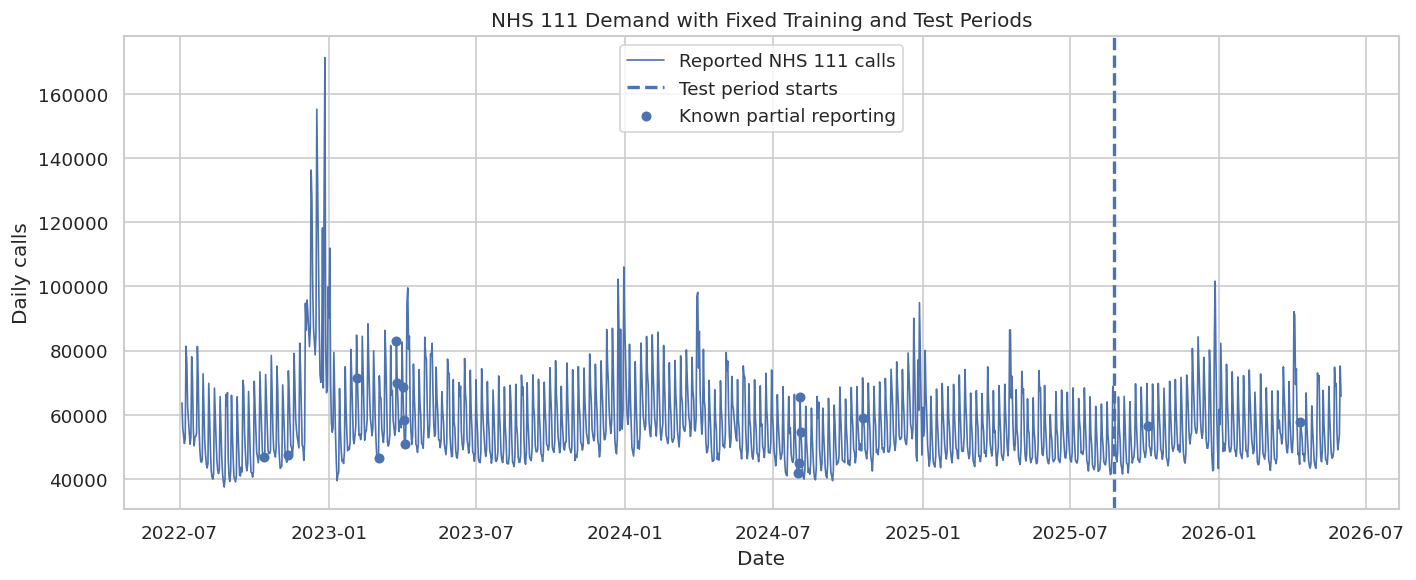

In [29]:
# Visualise the fixed train and test periods

plt.figure(figsize=(12, 5))
plt.plot(merged_data["Date"], merged_data["reported_A01"], linewidth=1, label="Reported NHS 111 calls")
plt.axvline(test_start, linestyle="--", linewidth=2, label="Test period starts")
partial_dates = merged_data[merged_data["partial_reporting"] == 1]
plt.scatter(partial_dates["Date"], partial_dates["reported_A01"], s=25, label="Known partial reporting")
plt.title("NHS 111 Demand with Fixed Training and Test Periods")
plt.xlabel("Date")
plt.ylabel("Daily calls")
plt.legend()
plt.tight_layout()
plt.savefig(Figures / "08_train_test_timeline.png", dpi=180, bbox_inches="tight")
plt.show()

### **What the split means**

The training period ends on 24 August 2025 and the final 280 days are held out for testing. There are 14 known partial-reporting dates in training and 2 in the test period.

The two test dates remain in the timeline, but they are not used when final error metrics are calculated. Every model is scored on the same 278 complete test dates.

# **10. Training-Only Time Series EDA**

The next checks use the training period only. This keeps the test target out of decisions about seasonality, stationarity, extreme values and model structure.

The purpose is to understand how NHS 111 demand behaves before choosing how to model it.

## **10.1 Training Demand Over Time**

The training series is plotted first to identify long-term movement, recurring patterns and unusually high-demand periods.

Training target summary:


,count,mean,std,min,25%,50%,75%,max
model_A01,1134.0,57241.9,13537.1,37443.0,48021.25,53544.0,63866.25,171371.0


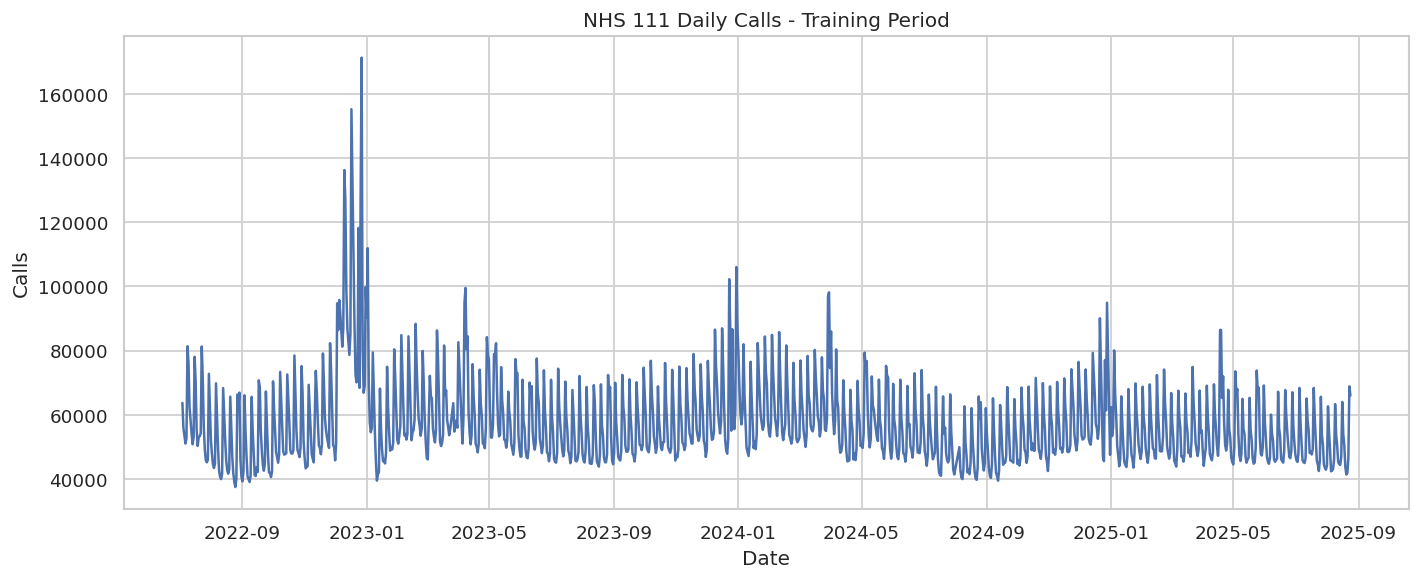

In [30]:
# Use only trustworthy training target values

eda_train = train_raw[train_raw["model_A01"].notna()].copy()
eda_train["day_of_week"] = eda_train["Date"].dt.dayofweek
eda_train["month"] = eda_train["Date"].dt.month

print("Training target summary:")
display(eda_train["model_A01"].describe().to_frame().T.round(2))

plt.figure(figsize=(12, 5))
plt.plot(eda_train["Date"], eda_train["model_A01"])
plt.title("NHS 111 Daily Calls - Training Period")
plt.xlabel("Date")
plt.ylabel("Calls")
plt.tight_layout()
plt.savefig(Figures / "01_training_calls.png", dpi=180, bbox_inches="tight")
plt.show()

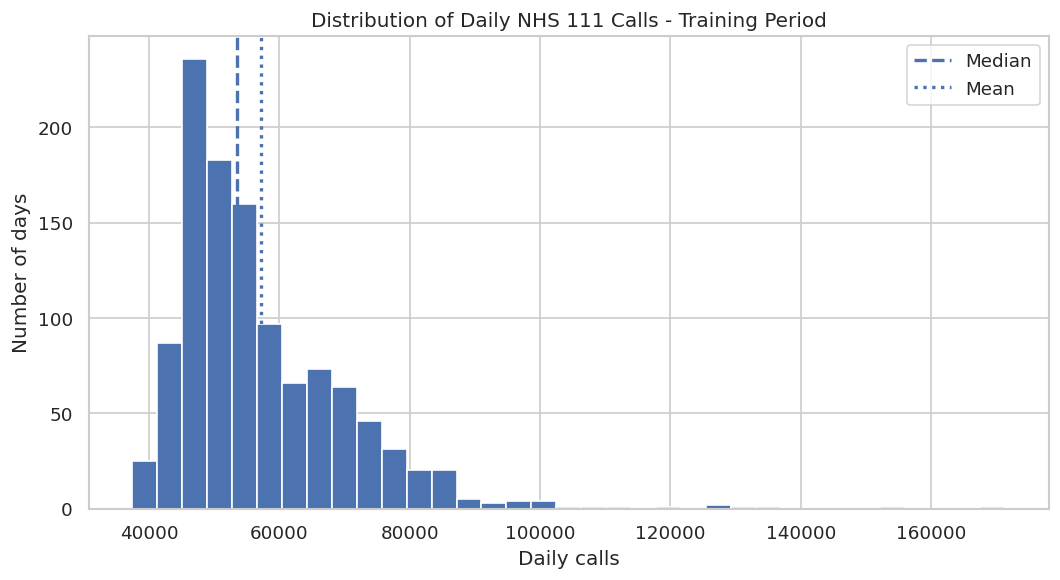

In [31]:
# Distribution of trustworthy training targets

plt.figure(figsize=(9, 5))
plt.hist(eda_train["model_A01"], bins=35)
plt.axvline(eda_train["model_A01"].median(), linestyle="--", linewidth=2, label="Median")
plt.axvline(eda_train["model_A01"].mean(), linestyle=":", linewidth=2, label="Mean")
plt.title("Distribution of Daily NHS 111 Calls - Training Period")
plt.xlabel("Daily calls")
plt.ylabel("Number of days")
plt.legend()
plt.tight_layout()
plt.savefig(Figures / "09_training_target_distribution.png", dpi=180, bbox_inches="tight")
plt.show()

### **What the demand distribution shows**

The training target has a mean of about **57,242 calls** and a median of about **53,544 calls**. The maximum is **171,371 calls**.

The upper tail contains a small number of very high-demand days. Those days are investigated because they may be genuine periods of NHS pressure.

## **10.2 Weekly and Monthly Patterns**

NHS 111 demand may differ by weekday and season. These summaries are descriptive only and use the training period.

,day_of_week,mean,median,std
0,0,59768.68,56378.0,11500.97
1,1,51975.98,49568.0,12311.90
2,2,49338.02,48175.5,6812.41
3,3,48335.42,46955.5,6407.05
4,4,51484.00,49642.0,8460.00
5,5,75171.05,72374.0,11997.60
6,6,64839.83,62694.0,10551.97


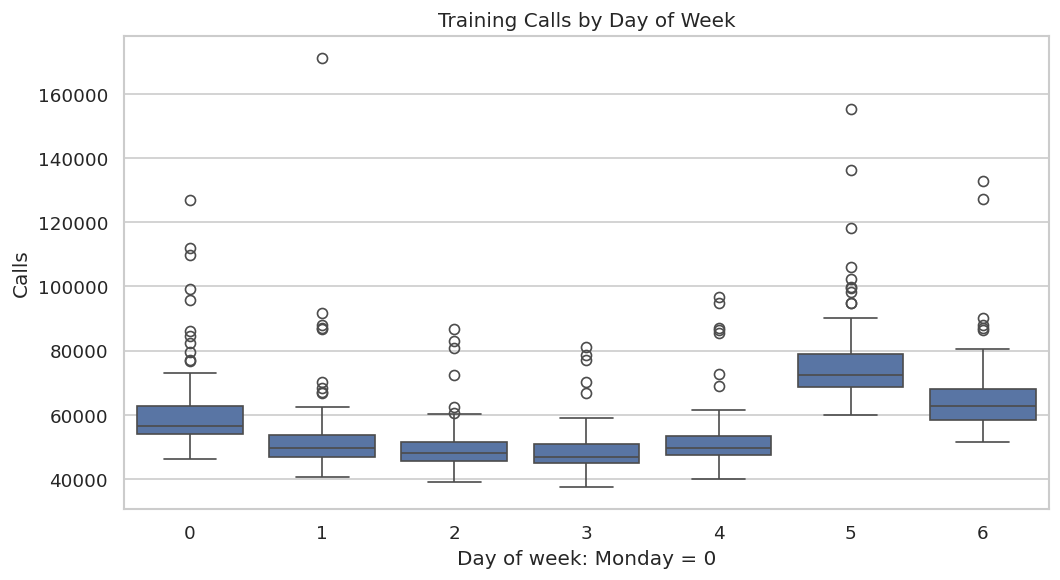

,month,mean,median,std
0,1,58166.37,55868.0,12786.17
1,2,59376.45,55700.0,10788.92
2,3,59367.43,55937.5,11125.18
3,4,59052.09,55080.0,12895.48
4,5,58037.89,53906.0,10501.40
5,6,54181.93,50757.5,8543.58
6,7,53686.36,51016.0,9456.27
7,8,50320.01,46646.0,9240.49
8,9,51092.82,48362.0,9401.50
9,10,55098.90,50988.0,9358.02


In [32]:
# Weekday pattern

weekday_summary = eda_train.groupby("day_of_week")["model_A01"].agg(["mean", "median", "std"]).reset_index()
display(weekday_summary.round(2))

plt.figure(figsize=(9, 5))
sns.boxplot(data=eda_train, x="day_of_week", y="model_A01")
plt.title("Training Calls by Day of Week")
plt.xlabel("Day of week: Monday = 0")
plt.ylabel("Calls")
plt.tight_layout()
plt.savefig(Figures / "02_weekday_pattern.png", dpi=180, bbox_inches="tight")
plt.show()

# Monthly pattern

monthly_summary = eda_train.groupby("month")["model_A01"].agg(["mean", "median", "std"]).reset_index()
display(monthly_summary.round(2))
monthly_summary.to_csv(Saved_Outputs / "training_monthly_summary.csv", index=False)

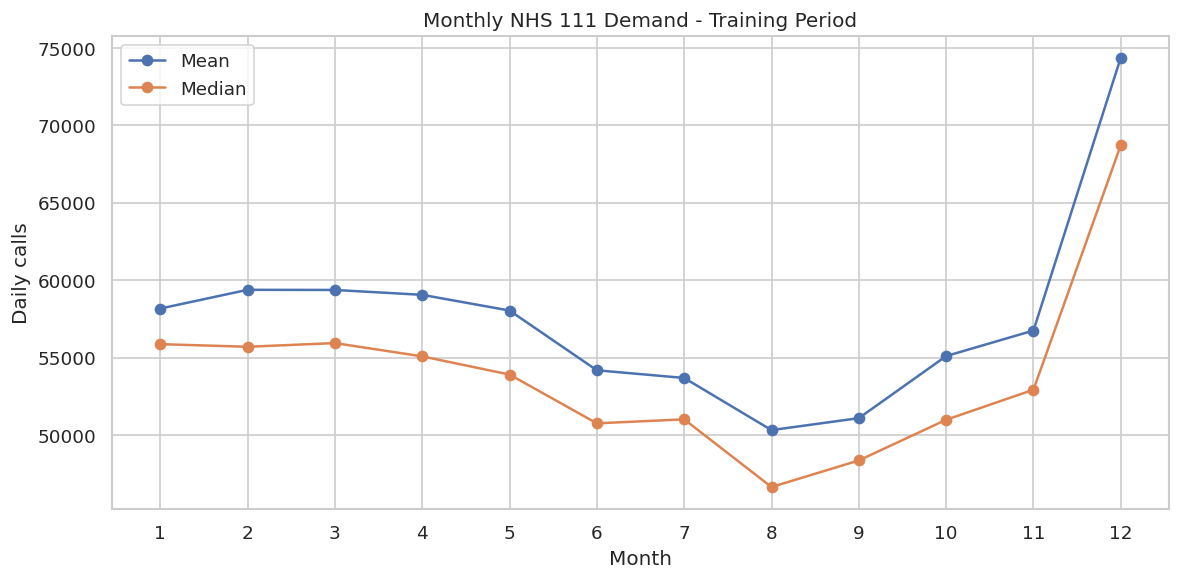

In [33]:
# Monthly demand profile

plt.figure(figsize=(10, 5))
plt.plot(monthly_summary["month"], monthly_summary["mean"], marker="o", label="Mean")
plt.plot(monthly_summary["month"], monthly_summary["median"], marker="o", label="Median")
plt.xticks(range(1, 13))
plt.title("Monthly NHS 111 Demand - Training Period")
plt.xlabel("Month")
plt.ylabel("Daily calls")
plt.legend()
plt.tight_layout()
plt.savefig(Figures / "10_monthly_demand_profile.png", dpi=180, bbox_inches="tight")
plt.show()

### **What the weekly and monthly patterns show**

Demand has a clear weekly pattern. Saturday has the highest average demand at about **75,171 calls**, followed by Sunday at about **64,840 calls**. Thursday is the lowest at about **48,335 calls**.

December has the highest monthly average at about **74,361 calls**. August is much lower at about **50,320 calls**. These patterns support weekly lags and calendar features.

## **10.3 STL Decomposition**

STL separates the training series into trend, weekly seasonality and residual variation. A seven-day period is used because the data is daily and NHS 111 demand is expected to follow a weekly cycle.

The few partial-reporting dates are interpolated **only for this diagnostic plot**. The interpolated values are not used as modelling targets.

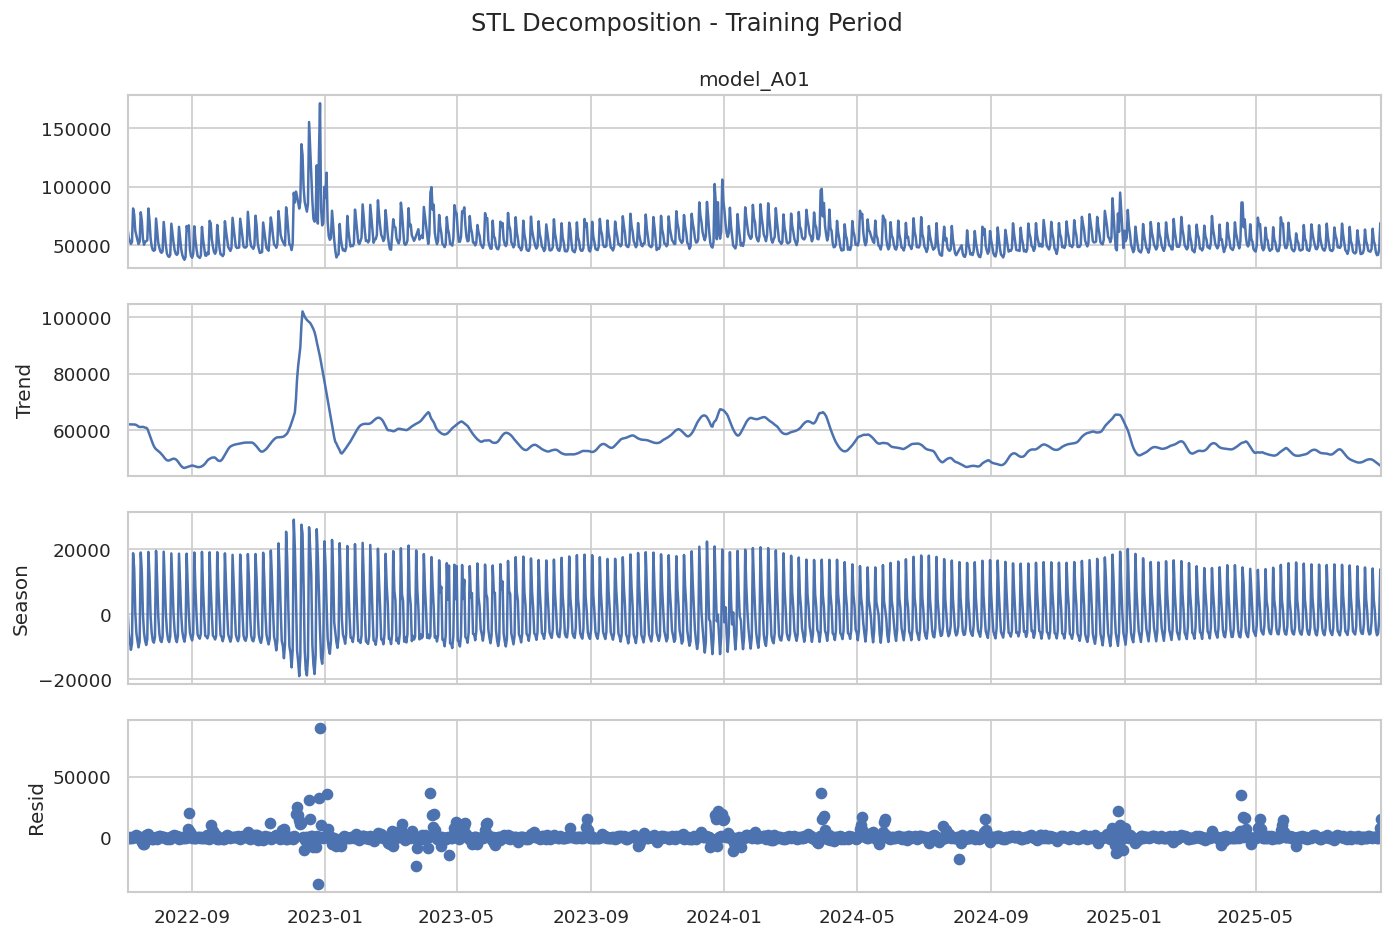

In [34]:
# Create a complete training series for decomposition only

stl_series = train_raw.set_index("Date")["model_A01"].asfreq("D")
stl_series = stl_series.interpolate(method="time")

stl_result = STL(stl_series, period=7, robust=True).fit()
fig = stl_result.plot()
fig.set_size_inches(12, 8)
fig.suptitle("STL Decomposition - Training Period", y=1.01)
fig.savefig(Figures / "03_stl_training.png", dpi=180, bbox_inches="tight")
plt.show()

## **10.4 Autocorrelation**

ACF and PACF are used to see how strongly current demand is related to earlier days. Strong values at lag 7 and its multiples would support weekly lag features and weekly seasonality in the statistical models.

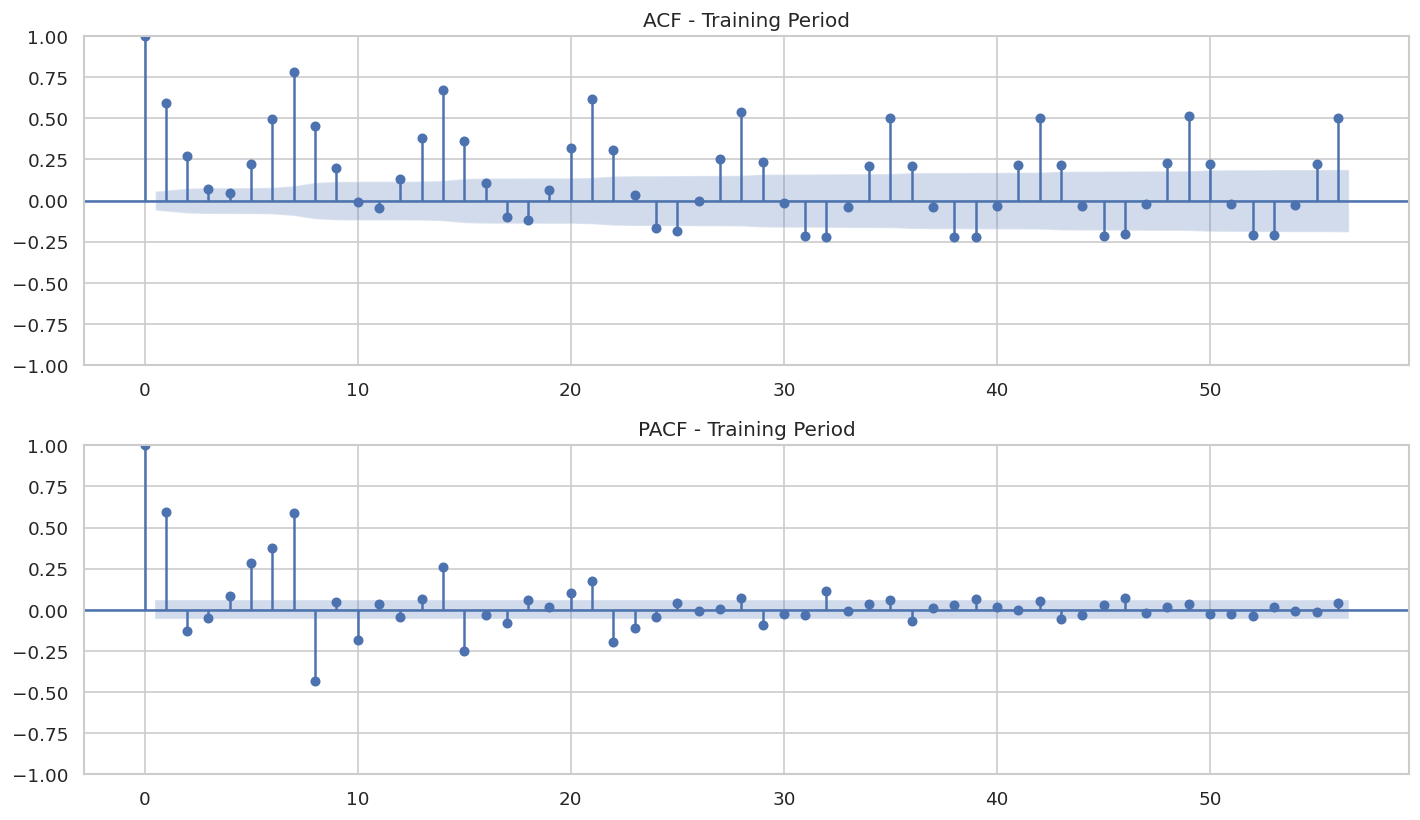

In [35]:
# ACF and PACF on training data

fig, axes = plt.subplots(2, 1, figsize=(12, 7))
plot_acf(stl_series, lags=56, ax=axes[0])
plot_pacf(stl_series, lags=56, ax=axes[1], method="ywm")
axes[0].set_title("ACF - Training Period")
axes[1].set_title("PACF - Training Period")
fig.tight_layout()
fig.savefig(Figures / "04_acf_pacf_training.png", dpi=180, bbox_inches="tight")
plt.show()

## **10.5 Stationarity Tests**

ADF and KPSS test stationarity from different directions, so they can disagree. The raw series, first difference and seven-day difference are checked together rather than relying on one test alone.

In [36]:
# Run ADF and KPSS

def stationarity_test(name, series):
    series = pd.Series(series).dropna()
    adf_result = adfuller(series, autolag="AIC")
    kpss_result = kpss(series, regression="c", nlags="auto")
    return [name, adf_result[0], adf_result[1], kpss_result[0], kpss_result[1]]

stationarity_results = pd.DataFrame([
    stationarity_test("Raw training series", stl_series),
    stationarity_test("First difference", stl_series.diff()),
    stationarity_test("Seven-day difference", stl_series.diff(7))
], columns=["series", "ADF_stat", "ADF_p", "KPSS_stat", "KPSS_p"])

display(stationarity_results.round(4))
stationarity_results.to_csv(Saved_Outputs / "stationarity_tests.csv", index=False)

/tmp/ipykernel_6778/855030123.py:6: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is smaller than the p-value returned.

  kpss_result = kpss(series, regression="c", nlags="auto")
/tmp/ipykernel_6778/855030123.py:6: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.

  kpss_result = kpss(series, regression="c", nlags="auto")
/tmp/ipykernel_6778/855030123.py:6: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.

  kpss_result = kpss(series, regression="c", nlags="auto")


,series,ADF_stat,ADF_p,KPSS_stat,KPSS_p
0,Raw training series,-4.9057,0.0,1.0056,0.01
1,First difference,-7.8871,0.0,0.0297,0.10
2,Seven-day difference,-7.4567,0.0,0.0131,0.10


### **What the stationarity tests show**

The raw series gives different messages from ADF and KPSS. ADF rejects a unit root, while KPSS rejects level stationarity. The series has strong repeating structure, but its level is not completely stable over time.

After first differencing and seven-day differencing, ADF remains significant and KPSS no longer rejects stationarity at the 5% level. This supports testing differenced SARIMAX structures with weekly seasonality.

## **10.6 Extreme Demand and Change Point Check**

Very large demand spikes can affect model fitting and error metrics. They are identified but not automatically removed because they may represent genuine NHS demand.

A Pettitt change-point test is also applied to the training series to identify a possible shift in the overall level of demand.

In [37]:
# Identify the largest training days

extreme_days = eda_train.nlargest(15, "model_A01")[["Date", "model_A01"]].copy()
print("Highest demand days in training:")
display(extreme_days)

extreme_days.to_csv(Saved_Outputs / "training_extreme_days.csv", index=False)

# Pettitt change-point test

def pettitt_test(series, dates):
    values = pd.Series(series).dropna().to_numpy()
    valid_dates = pd.Series(dates).iloc[:len(values)].reset_index(drop=True)
    n = len(values)
    ranks = stats.rankdata(values)
    u = 2 * np.cumsum(ranks) - np.arange(1, n + 1) * (n + 1)
    location = int(np.argmax(np.abs(u)))
    statistic = float(np.abs(u[location]))
    p_value = min(2 * np.exp((-6 * statistic ** 2) / (n ** 3 + n ** 2)), 1.0)
    return valid_dates.iloc[location], statistic, p_value

change_date, change_stat, change_p = pettitt_test(stl_series.values, stl_series.index)

print("Possible change date:", change_date)
print("Pettitt statistic:", round(change_stat, 2))
print("P-value:", round(change_p, 6))

change_result = pd.DataFrame({"change_date": [change_date], "statistic": [change_stat], "p_value": [change_p]})
change_result.to_csv(Saved_Outputs / "pettitt_change_point.csv", index=False)

Highest demand days in training:


,Date,model_A01
176,2022-12-27,171371.0
166,2022-12-17,155301.0
159,2022-12-10,136316.0
167,2022-12-18,133001.0
160,2022-12-11,127238.0
175,2022-12-26,127077.0
173,2022-12-24,118266.0
182,2023-01-02,111951.0
168,2022-12-19,109873.0
544,2023-12-30,106062.0


Possible change date: 2024-05-28 00:00:00
Pettitt statistic: 90097.0
P-value: 0.0


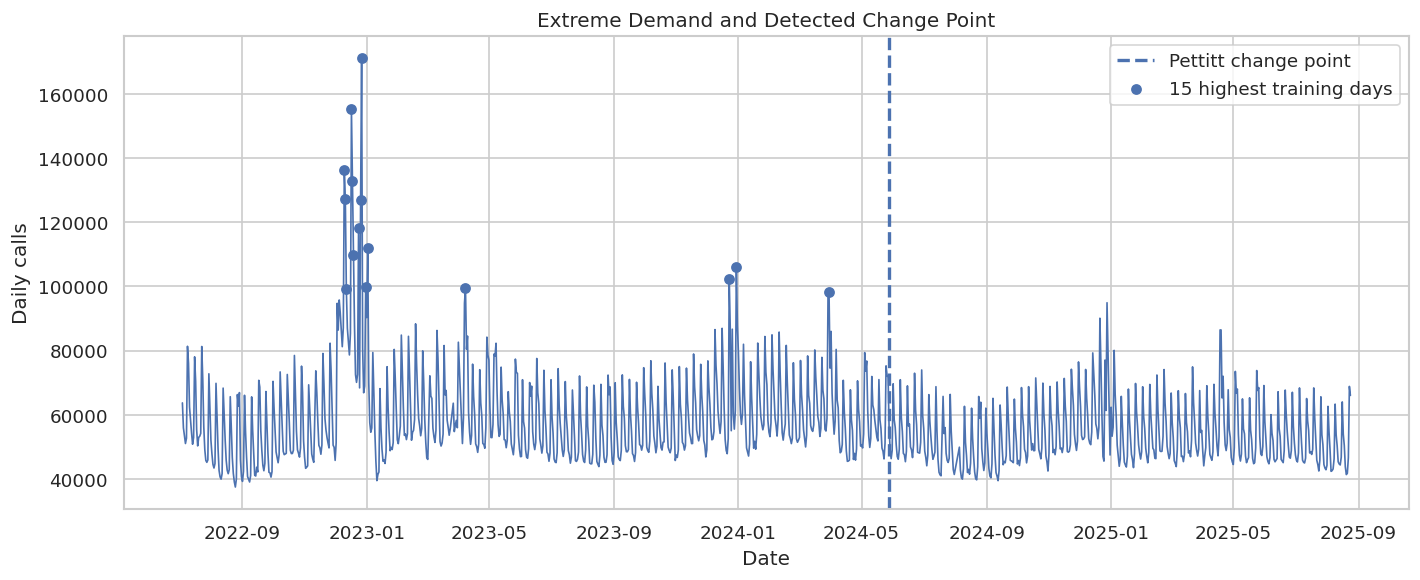

Mean before change point: 59717.91
Mean after change point: 53450.53


In [38]:
# Show the extreme period and detected level change

change_before = eda_train[eda_train["Date"] <= change_date]["model_A01"].mean()
change_after = eda_train[eda_train["Date"] > change_date]["model_A01"].mean()

plt.figure(figsize=(12, 5))
plt.plot(eda_train["Date"], eda_train["model_A01"], linewidth=1)
plt.axvline(change_date, linestyle="--", linewidth=2, label="Pettitt change point")
plt.scatter(extreme_days["Date"], extreme_days["model_A01"], s=30, label="15 highest training days")
plt.title("Extreme Demand and Detected Change Point")
plt.xlabel("Date")
plt.ylabel("Daily calls")
plt.legend()
plt.tight_layout()
plt.savefig(Figures / "11_extreme_demand_change_point.png", dpi=180, bbox_inches="tight")
plt.show()

print("Mean before change point:", round(change_before, 2))
print("Mean after change point:", round(change_after, 2))

### **What the extreme-demand check shows**

The largest demand values are concentrated around December 2022 and early January 2023. The highest day is 27 December 2022 with **171,371 calls**.

The Pettitt test identifies a level change around **28 May 2024**. The later sensitivity analysis checks the December 2022 period before any decision is made about excluding it.

## **10.7 Weather, Flu and Bank Holiday Relationships**

Same-day temperature and flu positivity are examined here only to understand the training data. They are **not** used directly as forecast inputs because their final observed values would not necessarily be known when the forecast is made.

Spearman correlation is used because the relationships do not have to be linear.

In [39]:
# Training-only descriptive relationships

relationship_data = eda_train[["model_A01", "temp_c", "flu_positivity", "bank_holiday"]].copy()

weather_corr = stats.spearmanr(relationship_data["model_A01"], relationship_data["temp_c"], nan_policy="omit")
flu_corr = stats.spearmanr(relationship_data["model_A01"], relationship_data["flu_positivity"], nan_policy="omit")

relationship_summary = pd.DataFrame({
    "factor": ["Temperature", "Flu positivity"],
    "spearman_r": [weather_corr.statistic, flu_corr.statistic],
    "p_value": [weather_corr.pvalue, flu_corr.pvalue]
})

display(relationship_summary.round(4))

holiday_summary = eda_train.groupby("bank_holiday")["model_A01"].agg(["count", "mean", "median"]).reset_index()
print("Bank holiday comparison:")
display(holiday_summary.round(2))

relationship_summary.to_csv(Saved_Outputs / "training_factor_correlations.csv", index=False)
holiday_summary.to_csv(Saved_Outputs / "training_bank_holiday_summary.csv", index=False)

,factor,spearman_r,p_value
0,Temperature,-0.2496,0.0
1,Flu positivity,0.2549,0.0


Bank holiday comparison:


,bank_holiday,count,mean,median
0,0,1108,56681.88,53309.0
1,1,26,81107.54,76895.0


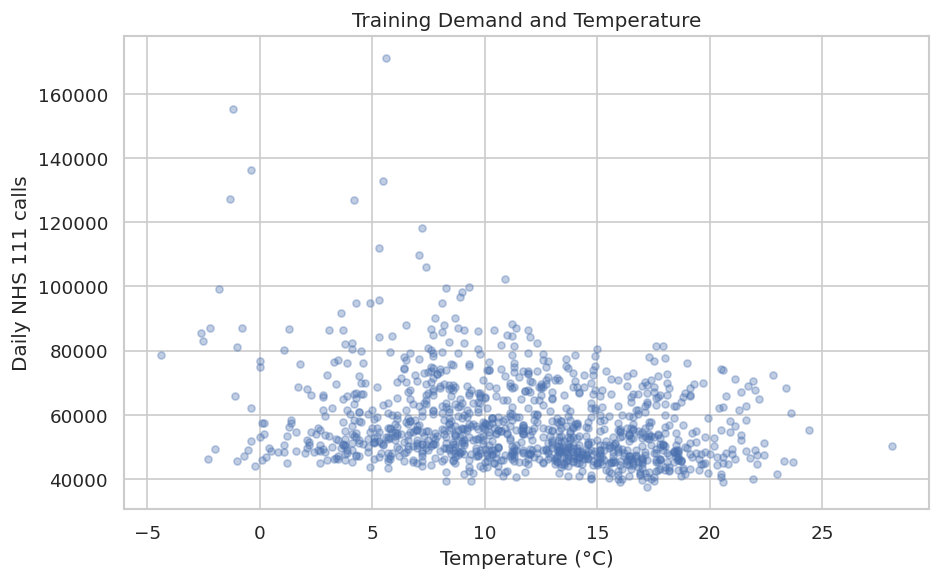

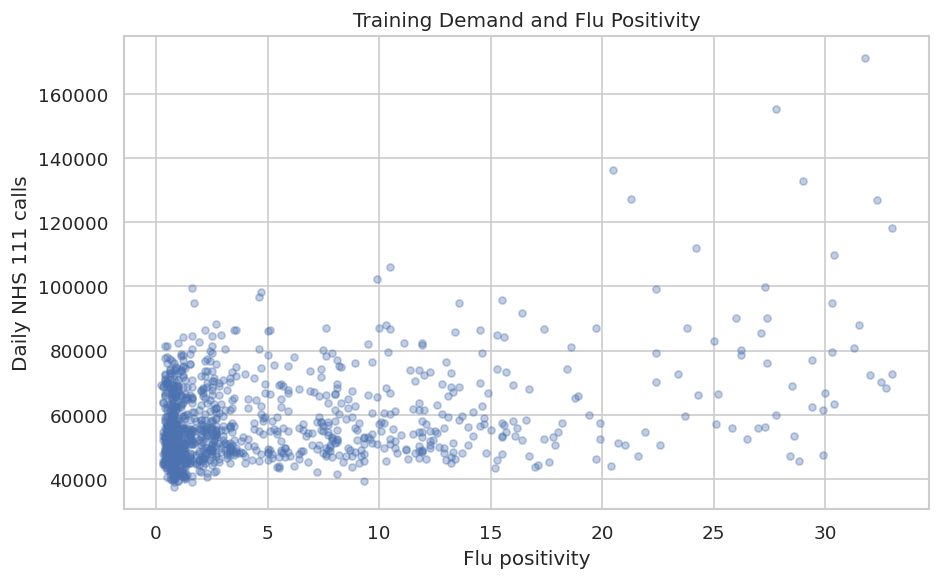

In [40]:
# Temperature relationship

plt.figure(figsize=(8, 5))
plt.scatter(eda_train["temp_c"], eda_train["model_A01"], alpha=0.35, s=18)
plt.title("Training Demand and Temperature")
plt.xlabel("Temperature (°C)")
plt.ylabel("Daily NHS 111 calls")
plt.tight_layout()
plt.savefig(Figures / "12_demand_temperature.png", dpi=180, bbox_inches="tight")
plt.show()

# Flu relationship

plt.figure(figsize=(8, 5))
plt.scatter(eda_train["flu_positivity"], eda_train["model_A01"], alpha=0.35, s=18)
plt.title("Training Demand and Flu Positivity")
plt.xlabel("Flu positivity")
plt.ylabel("Daily NHS 111 calls")
plt.tight_layout()
plt.savefig(Figures / "13_demand_flu.png", dpi=180, bbox_inches="tight")
plt.show()

### **What the external-factor checks show**

Temperature has a Spearman correlation of about **-0.25** with call demand. Colder periods tend to be associated with higher demand.

Flu positivity has a correlation of about **0.25** with demand. Higher flu activity tends to occur with higher NHS 111 demand.

Bank holidays show a much larger descriptive difference. Training bank holidays average about **81,108 calls**, compared with about **56,682 calls** on other days.

# **11. Leakage-Safe Feature Engineering With Clear Hypotheses**

The feature set is expanded only where there is a clear forecasting reason. The aim is not to create many columns for their own sake.

Each feature below answers a specific question:

- **Recent demand:** does yesterday or the last few days carry forward into tomorrow?
- **Weekly repetition:** does the same weekday in previous weeks help predict tomorrow?
- **Recent level and volatility:** is demand currently running above or below its recent baseline, and has it become unstable?
- **Calendar pattern:** do weekday, weekend and annual seasonal cycles affect demand?
- **Holiday timing:** does demand change on a bank holiday, immediately around a bank holiday, or around the Christmas and New Year period?
- **Weather:** do recent temperature level and weekly temperature conditions add useful information?
- **Influenza:** does lagged flu activity, allowing for publication delay, improve the forecast?

Only information available before the forecast date is used. Same-day observed temperature, same-day flu values and retrospective reporting-quality measures are excluded from the model.

In [41]:
# Prepare the modelling dataset

model_data = merged_data.copy()
model_data["model_A01"] = model_data["reported_A01"].where(model_data["partial_reporting"] == 0)
model_data["history_A01"] = model_data["model_A01"]

# Calendar structure known in advance

model_data["day_of_week"] = model_data["Date"].dt.dayofweek
model_data["month"] = model_data["Date"].dt.month  # descriptive error analysis only
model_data["is_weekend"] = (model_data["day_of_week"] >= 5).astype(int)
model_data["day_of_year"] = model_data["Date"].dt.dayofyear
model_data["doy_sin"] = np.sin(2 * np.pi * model_data["day_of_year"] / 365.25)
model_data["doy_cos"] = np.cos(2 * np.pi * model_data["day_of_year"] / 365.25)
model_data["trend_index"] = np.arange(len(model_data))

# Bank-holiday timing known in advance

holiday_dates = pd.to_datetime(bank_holidays["Date"])
model_data["day_before_holiday"] = model_data["Date"].isin(holiday_dates - pd.Timedelta(days=1)).astype(int)
model_data["day_after_holiday"] = model_data["Date"].isin(holiday_dates + pd.Timedelta(days=1)).astype(int)

# Christmas and New Year periods test whether demand changes around the festive period

month = model_data["Date"].dt.month
day = model_data["Date"].dt.day
model_data["pre_christmas"] = ((month == 12) & (day >= 18) & (day <= 23)).astype(int)
model_data["christmas_eve"] = ((month == 12) & (day == 24)).astype(int)
model_data["christmas_day"] = ((month == 12) & (day == 25)).astype(int)
model_data["boxing_day"] = ((month == 12) & (day == 26)).astype(int)
model_data["post_christmas"] = ((month == 12) & (day >= 27) & (day <= 30)).astype(int)
model_data["new_year_eve"] = ((month == 12) & (day == 31)).astype(int)
model_data["new_year_day"] = ((month == 1) & (day == 1)).astype(int)

# Easter period: Good Friday through Easter Monday

good_friday_dates = pd.to_datetime(bank_holidays[bank_holidays["holiday_name"].str.contains("Good Friday", case=False, na=False)]["Date"])
easter_period_dates = []

for good_friday in good_friday_dates:
    for offset in range(4):
        easter_period_dates.append(good_friday + pd.Timedelta(days=offset))

model_data["easter_period"] = model_data["Date"].isin(easter_period_dates).astype(int)

# Recent demand: immediate persistence and weekly recurrence

history_lags = [1, 2, 3, 7, 14, 21, 28]

for lag in history_lags:
    model_data[f"lag_{lag}"] = model_data["history_A01"].shift(lag)

# Recent demand level and volatility

for window in [7, 14, 28]:
    model_data[f"rolling_mean_{window}"] = model_data["history_A01"].shift(1).rolling(window).mean()

for window in [7, 14]:
    model_data[f"rolling_std_{window}"] = model_data["history_A01"].shift(1).rolling(window).std()

# Weekly movement: yesterday compared with the same weekday one week earlier

model_data["weekly_change"] = model_data["lag_1"] - model_data["history_A01"].shift(8)

# Weather known before the forecast date

model_data["temp_lag_1"] = model_data["temp_c"].shift(1)
model_data["temp_lag_7"] = model_data["temp_c"].shift(7)
model_data["temp_rolling_mean_7"] = model_data["temp_c"].shift(1).rolling(7).mean()

# Flu with a conservative reporting delay

model_data["flu_lag_7"] = model_data["flu_positivity"].shift(7)  # sensitivity only
model_data["flu_lag_14"] = model_data["flu_positivity"].shift(14)
model_data["flu_lag_21"] = model_data["flu_positivity"].shift(21)
model_data["flu_trend"] = model_data["flu_lag_14"] - model_data["flu_lag_21"]

# The longest demand history feature needs 28 earlier days

model_start = model_data["Date"].min() + pd.Timedelta(days=28)
model_data = model_data[model_data["Date"] >= model_start].reset_index(drop=True)

print("Modelling period:", model_data["Date"].min(), "to", model_data["Date"].max())
print("Rows:", len(model_data))

Modelling period: 2022-08-01 00:00:00 to 2026-05-31 00:00:00
Rows: 1400


### **Why these features were created**

`lag_1`, `lag_2` and `lag_3` represent short-term persistence. The weekly lags at 7, 14, 21 and 28 days test whether NHS 111 demand repeats by weekday across several weeks.

The 7, 14 and 28-day rolling means describe the recent demand level. The rolling standard deviations measure whether recent demand has become more volatile. `weekly_change` measures whether the most recent level is moving away from the level seen one week earlier.

The calendar features represent the weekly and annual cycles already visible in the training data. Bank-holiday proximity is included because service use can change immediately before and after a holiday. The festive-period indicators separate pre-Christmas, Christmas Eve, Christmas and Boxing Day, the days between Christmas and New Year, and New Year itself so these periods are not forced to have the same effect. Easter is treated as a moving four-day period.

Weather features use only past temperature. Flu features use 14 and 21-day lags so the model does not assume that same-day surveillance information is available. `flu_trend` tests whether flu activity is rising or falling between those lagged observations.

In [42]:
# Define meaningful candidate feature groups

history_features = [
    "lag_1", "lag_2", "lag_3", "lag_7", "lag_14", "lag_21", "lag_28",
    "rolling_mean_7", "rolling_mean_14", "rolling_mean_28",
    "rolling_std_7", "rolling_std_14", "weekly_change"
]

calendar_features = [
    "day_of_week", "is_weekend", "doy_sin", "doy_cos", "trend_index", "bank_holiday",
    "day_before_holiday", "day_after_holiday", "pre_christmas", "christmas_eve",
    "christmas_day", "boxing_day", "post_christmas", "new_year_eve", "new_year_day", "easter_period"
]

weather_features = ["temp_lag_1", "temp_lag_7", "temp_rolling_mean_7"]
flu_features = ["flu_lag_14", "flu_lag_21", "flu_trend"]

candidate_features = history_features + calendar_features + weather_features + flu_features

# Classical models use a smaller regressor set to keep them stable and interpretable

sarimax_features = [
    "is_weekend", "bank_holiday", "doy_sin", "doy_cos", "trend_index",
    "temp_lag_1", "temp_rolling_mean_7", "flu_lag_14"
]

prophet_regressors = ["temp_lag_1", "temp_rolling_mean_7", "flu_lag_14"]

quality_only = [
    "contracts_reporting", "contracts_missing", "contracts_zero",
    "coverage_pct", "partial_reporting", "known_coverage_gap"
]

forbidden = ["reported_A01", "model_A01", "history_A01", "temp_c", "flu_positivity"] + quality_only

print("Candidate ML features:", len(candidate_features))
print("Forbidden columns accidentally included:", sorted(set(candidate_features).intersection(forbidden)))
print("Demand history features:", len(history_features))
print("Calendar and holiday features:", len(calendar_features))
print("Weather features:", len(weather_features))
print("Flu features:", len(flu_features))

Candidate ML features: 35
Forbidden columns accidentally included: []
Demand history features: 13
Calendar and holiday features: 16
Weather features: 3
Flu features: 3


### **Feature dictionary and purpose**

| Feature | Reason for inclusion |
| --- | --- |
| `lag_1`, `lag_2`, `lag_3` | Short-term persistence in call demand |
| `lag_7`, `lag_14`, `lag_21`, `lag_28` | Weekly recurrence over one to four weeks |
| `rolling_mean_7`, `rolling_mean_14`, `rolling_mean_28` | Recent demand level |
| `rolling_std_7`, `rolling_std_14` | Recent volatility in demand |
| `weekly_change` | Change from the same weekday one week earlier |
| `day_of_week`, `is_weekend` | Weekly service-use pattern |
| `doy_sin`, `doy_cos` | Smooth annual seasonality |
| `trend_index` | Long-term change in demand level |
| `bank_holiday` | Public-holiday effect |
| `day_before_holiday`, `day_after_holiday` | Possible demand displacement around holidays |
| `pre_christmas` | Tests 18 to 23 December |
| `christmas_eve` | Tests 24 December separately |
| `christmas_day` | Tests 25 December separately |
| `boxing_day` | Tests 26 December separately |
| `post_christmas` | Tests 27 to 30 December |
| `new_year_eve` | Tests 31 December |
| `new_year_day` | Tests 1 January |
| `easter_period` | Tests Good Friday through Easter Monday |
| `temp_lag_1` | Most recent observed temperature |
| `temp_lag_7` | Temperature aligned with the weekly cycle |
| `temp_rolling_mean_7` | Sustained recent temperature conditions |
| `flu_lag_14`, `flu_lag_21` | Delayed influenza surveillance signal |
| `flu_trend` | Direction of change in influenza activity |

`month` is retained only for descriptive error analysis. It is not a model feature.

### **Candidate feature check**

The candidate set is deliberately limited to features with a direct forecasting interpretation. The leakage check must return an empty list.

Feature selection is used to remove redundant **demand-history** variables. Calendar, holiday, weather and flu variables are retained because they directly answer the research question and some holiday features are rare enough that an automatic importance filter could remove them simply because few examples occur in one screening fold.

### **Decision**

The reporting-quality variables remain in the dataset but are excluded from all forecasting models. They are known only after reporting occurs and would therefore be unavailable at prediction time.

The main modelling features use lagged demand, known calendar information, past temperature and conservatively lagged flu positivity.

# **12. Walk-Forward Validation Design and Forecast Metrics**

All models use the same expanding chronological validation windows. Five validation folds are created, each covering 56 days. The model always trains on earlier dates and validates on later dates, so no random split is used.

This project predicts the **number of NHS 111 calls**, which is a continuous numerical target. It is therefore a **regression and time-series forecasting problem**, not a classification problem.

ROC-AUC and PR-AUC are not used because they evaluate classification performance. Using them would require changing daily call demand into artificial classes such as "high" and "low" demand, which would change the research question and discard information from the original continuous target.

Forecast performance is evaluated using:

- **Mean Error (ME)** to check systematic forecast bias;
- **MAE** as the main interpretable error measure in calls;
- **RMSE** to penalise large misses more strongly;
- **R²** as a supporting measure of explained variation;
- **MASE** using a seven-day seasonal-naive denominator;
- **RMSSE** as the squared-error scaled equivalent.

MASE and RMSSE below 1 indicate performance better than the corresponding seasonal-naive error scale.

In [43]:
# Training and test modelling calendars

train_calendar = model_data[model_data["Date"] < test_start].reset_index(drop=True)
test_calendar = model_data[model_data["Date"] >= test_start].reset_index(drop=True)

# Final model-comparison folds: the latest five training-period windows

tscv = TimeSeriesSplit(n_splits=5, test_size=56)
cv_splits = list(tscv.split(train_calendar))

fold_dates = []

for fold, (train_idx, val_idx) in enumerate(cv_splits, start=1):
    fold_dates.append([
        fold,
        train_calendar.iloc[train_idx]["Date"].min(),
        train_calendar.iloc[train_idx]["Date"].max(),
        train_calendar.iloc[val_idx]["Date"].min(),
        train_calendar.iloc[val_idx]["Date"].max()
    ])

fold_dates = pd.DataFrame(
    fold_dates,
    columns=["fold", "train_start", "train_end", "validation_start", "validation_end"]
)

# Earlier data are used for feature screening and hyperparameter tuning

comparison_start = cv_splits[0][1][0]
precomparison_calendar = train_calendar.iloc[:comparison_start].reset_index(drop=True)

tuning_tscv = TimeSeriesSplit(n_splits=3, test_size=56)
tuning_splits = list(tuning_tscv.split(precomparison_calendar))

feature_selection_end = tuning_splits[0][1][0]
feature_selection_calendar = precomparison_calendar.iloc[:feature_selection_end].reset_index(drop=True)

feature_tscv = TimeSeriesSplit(n_splits=3, test_size=42)
feature_splits = list(feature_tscv.split(feature_selection_calendar))

display(fold_dates)

print("Feature-screening data ends:", feature_selection_calendar["Date"].max())
print("Hyperparameter-tuning validation begins:", precomparison_calendar.iloc[tuning_splits[0][1][0]]["Date"])
print("Model-comparison validation begins:", train_calendar.iloc[cv_splits[0][1][0]]["Date"])
print("Held-out test begins:", test_calendar["Date"].min())

fold_dates.to_csv(Saved_Outputs / "walk_forward_folds.csv", index=False)

,fold,train_start,train_end,validation_start,validation_end
0,1,2022-08-01,2024-11-17,2024-11-18,2025-01-12
1,2,2022-08-01,2025-01-12,2025-01-13,2025-03-09
2,3,2022-08-01,2025-03-09,2025-03-10,2025-05-04
3,4,2022-08-01,2025-05-04,2025-05-05,2025-06-29
4,5,2022-08-01,2025-06-29,2025-06-30,2025-08-24


Feature-screening data ends: 2024-06-02 00:00:00
Hyperparameter-tuning validation begins: 2024-06-03 00:00:00
Model-comparison validation begins: 2024-11-18 00:00:00
Held-out test begins: 2025-08-25 00:00:00


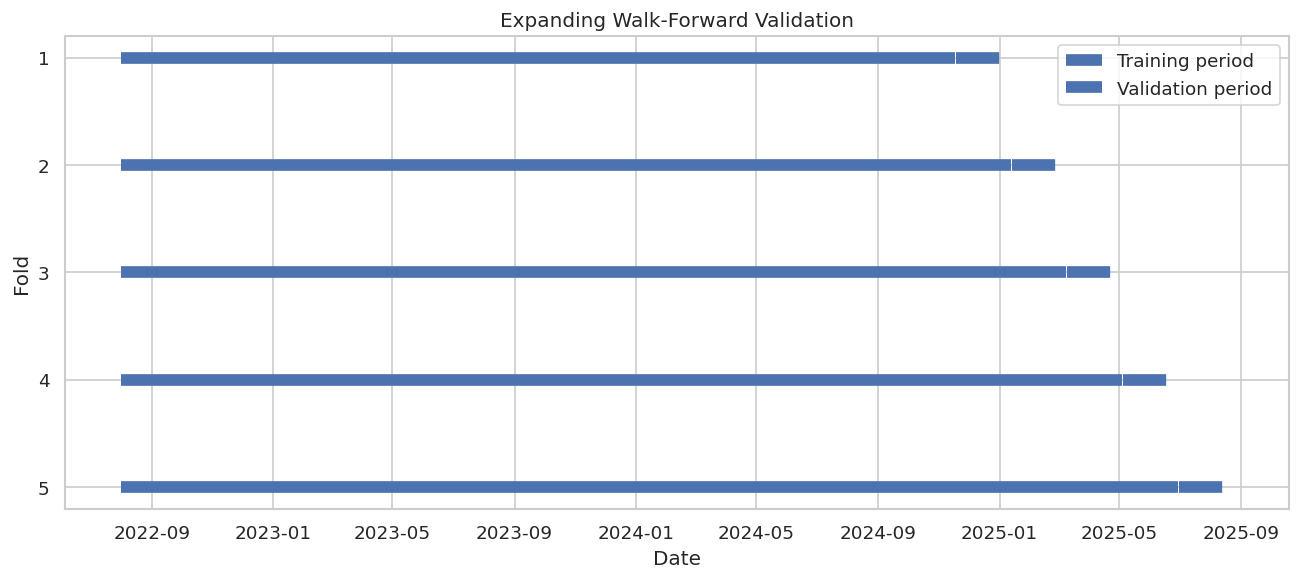

In [44]:
# Visualise the five walk-forward folds

plt.figure(figsize=(11, 5))

for _, row in fold_dates.iterrows():
    y = int(row["fold"])
    train_label = "Training period" if y == 1 else None
    val_label = "Validation period" if y == 1 else None
    plt.hlines(y, row["train_start"], row["train_end"], linewidth=7, label=train_label)
    plt.hlines(y, row["validation_start"], row["validation_end"], linewidth=7, linestyles="dashed", label=val_label)

plt.yticks(fold_dates["fold"])
plt.gca().invert_yaxis()
plt.title("Expanding Walk-Forward Validation")
plt.xlabel("Date")
plt.ylabel("Fold")
plt.legend()
plt.tight_layout()
plt.savefig(Figures / "14_walk_forward_folds.png", dpi=180, bbox_inches="tight")
plt.show()

### **Why the development stages are separated**

The training period now has three different jobs.

**Feature screening** uses the earliest validation windows. This decides which engineered predictors are worth carrying forward.

**Hyperparameter tuning** uses later training-period validation windows. This chooses settings for XGBoost, LightGBM and CatBoost after the feature set has been frozen.

**Model comparison** uses the latest five training-period validation windows. These folds have not been used to choose features or tune the boosting parameters.

The held-out test period comes after all three stages and remains the final generalisation check.

In [45]:
# Forecast accuracy metrics

def forecast_metrics(y_true, y_pred, mae_scale, mse_scale):
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)
    error = y_true - y_pred
    me = np.mean(error)
    mae = mean_absolute_error(y_true, y_pred)
    rmse = mean_squared_error(y_true, y_pred) ** 0.5
    r2 = r2_score(y_true, y_pred)
    mase = mae / mae_scale if mae_scale > 0 else np.nan
    rmsse = rmse / (mse_scale ** 0.5) if mse_scale > 0 else np.nan
    return {"ME": me, "MAE": mae, "RMSE": rmse, "R2": r2, "MASE": mase, "RMSSE": rmsse}


def seasonal_scales(frame):
    seasonal_error = frame["model_A01"] - frame["model_A01"].shift(7)
    mae_scale = seasonal_error.abs().mean()
    mse_scale = (seasonal_error ** 2).mean()
    return mae_scale, mse_scale

## **12.1 Seasonal Naive Baseline**

A real forecasting model must beat a simple baseline. The seasonal naive forecast uses the value from seven days earlier. If that value is unavailable because the earlier date had partial reporting, the median of the available 7, 14, 21 and 28-day lags is used.

In [46]:
# Seasonal naive walk-forward results

baseline_fold_rows = []
baseline_oof_rows = []

for fold, (train_idx, val_idx) in enumerate(cv_splits, start=1):
    fold_train = train_calendar.iloc[train_idx].copy()
    fold_val = train_calendar.iloc[val_idx].copy()
    mae_scale, mse_scale = seasonal_scales(fold_train)

    prediction = fold_val["lag_7"].copy()
    fallback = fold_val[["lag_7", "lag_14", "lag_21", "lag_28"]].median(axis=1)
    prediction = prediction.fillna(fallback)

    valid = fold_val["model_A01"].notna() & prediction.notna()
    metrics = forecast_metrics(fold_val.loc[valid, "model_A01"], prediction[valid], mae_scale, mse_scale)
    baseline_fold_rows.append({"fold": fold, "Model": "Seasonal Naive", **metrics})

    for date, actual, pred in zip(fold_val.loc[valid, "Date"], fold_val.loc[valid, "model_A01"], prediction[valid]):
        baseline_oof_rows.append({"fold": fold, "Date": date, "Model": "Seasonal Naive", "Actual": actual, "Predicted": pred})

baseline_fold = pd.DataFrame(baseline_fold_rows)
baseline_oof = pd.DataFrame(baseline_oof_rows)

display(baseline_fold.round(2))

,fold,Model,ME,MAE,RMSE,R2,MASE,RMSSE
0,1,Seasonal Naive,-307.46,5423.89,7772.06,0.56,1.06,0.81
1,2,Seasonal Naive,-130.95,2189.66,2907.11,0.88,0.43,0.31
2,3,Seasonal Naive,289.62,5598.66,9406.60,0.15,1.13,1.02
3,4,Seasonal Naive,-157.20,3941.02,5895.88,0.47,0.79,0.64
4,5,Seasonal Naive,-211.82,2076.25,2798.17,0.87,0.42,0.31


### **How to read the baseline result**

The seasonal naive forecast is the minimum standard the fitted models must beat. Its fold MAE also shows how much forecasting difficulty changes from one period to another. A useful fitted model should improve on this baseline across the later validation folds, not only on one favourable period.

# **13. Classical Time Series Models**

SARIMAX and Prophet are included as strong time-series comparators. This follows the time-series teaching principle that more complex machine-learning models should demonstrate an improvement over established forecasting methods.

## **13.1 Selecting a SARIMAX Structure**

A small set of reasonable SARIMAX structures is compared using AIC on the **earliest training fold only**. The selected structure is then frozen before the walk-forward comparison. This avoids choosing the SARIMAX order using the later validation windows or the test period.

In [47]:
# Select SARIMAX order using only the earliest training fold

first_train_idx = cv_splits[0][0]
sarimax_selection = train_calendar.iloc[first_train_idx].set_index("Date").asfreq("D")

orders = [(1, 0, 1), (2, 0, 1), (1, 1, 1), (2, 1, 1)]
seasonal_orders = [(1, 0, 1, 7), (1, 1, 1, 7), (0, 1, 1, 7)]

sarimax_candidates = []

for order in orders:
    for seasonal_order in seasonal_orders:
        try:
            model = SARIMAX(sarimax_selection["model_A01"], exog=sarimax_selection[sarimax_features], order=order, seasonal_order=seasonal_order, trend="c", enforce_stationarity=False, enforce_invertibility=False)
            result = model.fit(disp=False, maxiter=500)
            converged = bool(result.mle_retvals.get("converged", False))
            sarimax_candidates.append([order, seasonal_order, result.aic, converged])
        except Exception:
            sarimax_candidates.append([order, seasonal_order, np.nan, False])

sarimax_candidates = pd.DataFrame(sarimax_candidates, columns=["order", "seasonal_order", "AIC", "converged"])
sarimax_candidates = sarimax_candidates.sort_values("AIC", na_position="last").reset_index(drop=True)

print("All SARIMAX candidates:")
display(sarimax_candidates)

valid_sarimax = sarimax_candidates[sarimax_candidates["converged"] & sarimax_candidates["AIC"].notna()].copy()

if len(valid_sarimax) == 0:
    raise ValueError("No SARIMAX candidate converged. A simpler candidate set is required.")

valid_sarimax = valid_sarimax.sort_values("AIC").reset_index(drop=True)
best_sarimax_order = valid_sarimax.loc[0, "order"]
best_sarimax_seasonal = valid_sarimax.loc[0, "seasonal_order"]

print("Selected order:", best_sarimax_order)
print("Selected seasonal order:", best_sarimax_seasonal)

sarimax_candidates.to_csv(Saved_Outputs / "sarimax_order_search.csv", index=False)

All SARIMAX candidates:


,order,seasonal_order,AIC,converged
0,"(2, 1, 1)","(0, 1, 1, 7)",16468.891853,True
1,"(2, 1, 1)","(1, 1, 1, 7)",16470.519160,True
2,"(2, 0, 1)","(1, 1, 1, 7)",16474.257190,True
3,"(1, 0, 1)","(0, 1, 1, 7)",16487.009935,True
4,"(1, 0, 1)","(1, 1, 1, 7)",16488.524093,True
5,"(1, 1, 1)","(0, 1, 1, 7)",16507.691597,True
6,"(1, 1, 1)","(1, 1, 1, 7)",16509.105212,True
7,"(2, 0, 1)","(0, 1, 1, 7)",16534.969027,True
8,"(2, 1, 1)","(1, 0, 1, 7)",16621.254002,True
9,"(1, 1, 1)","(1, 0, 1, 7)",16624.967027,True


Selected order: (2, 1, 1)
Selected seasonal order: (0, 1, 1, 7)


### **SARIMAX order decision**

All 12 candidate SARIMAX specifications converge. The lowest AIC is produced by **SARIMAX(2,1,1)(0,1,1)[7]**, so that structure is carried into the walk-forward comparison.

The order is chosen from training information only.

## **13.2 SARIMAX Walk-Forward Validation**

SARIMAX is fitted at the start of each validation fold. It then produces a one-day-ahead forecast and updates its state with the next observed value without refitting the parameters. Partial-reporting targets are passed as missing observations and are not scored.

In [48]:
# SARIMAX walk-forward validation

sarimax_fold_rows = []
sarimax_oof_rows = []

for fold, (train_idx, val_idx) in enumerate(cv_splits, start=1):
    fold_train = train_calendar.iloc[train_idx].set_index("Date").asfreq("D")
    fold_val = train_calendar.iloc[val_idx].copy()
    mae_scale, mse_scale = seasonal_scales(train_calendar.iloc[train_idx])

    model = SARIMAX(fold_train["model_A01"], exog=fold_train[sarimax_features], order=best_sarimax_order, seasonal_order=best_sarimax_seasonal, trend="c", enforce_stationarity=False, enforce_invertibility=False)
    result = model.fit(disp=False, maxiter=500)
    converged = bool(result.mle_retvals.get("converged", False))

    if not converged:
        print("Warning: SARIMAX fold", fold, "did not fully converge.")

    actual_values = []
    predicted_values = []

    for _, row in fold_val.iterrows():
        date = row["Date"]
        exog_row = pd.DataFrame([row[sarimax_features].to_dict()], index=[date])
        pred = float(result.get_forecast(steps=1, exog=exog_row).predicted_mean.iloc[0])
        observed = pd.Series([row["model_A01"]], index=[date], name="model_A01")
        result = result.append(observed, exog=exog_row, refit=False)

        if pd.notna(row["model_A01"]):
            actual_values.append(row["model_A01"])
            predicted_values.append(pred)
            sarimax_oof_rows.append({"fold": fold, "Date": date, "Model": "SARIMAX", "Actual": row["model_A01"], "Predicted": pred})

    metrics = forecast_metrics(actual_values, predicted_values, mae_scale, mse_scale)
    sarimax_fold_rows.append({"fold": fold, "Model": "SARIMAX", "Converged": converged, **metrics})

sarimax_fold = pd.DataFrame(sarimax_fold_rows)
sarimax_oof = pd.DataFrame(sarimax_oof_rows)

display(sarimax_fold.round(2))

,fold,Model,Converged,ME,MAE,RMSE,R2,MASE,RMSSE
0,1,SARIMAX,True,-566.64,3977.28,6435.59,0.70,0.78,0.67
1,2,SARIMAX,True,73.65,1870.34,2455.34,0.91,0.36,0.26
2,3,SARIMAX,True,278.19,2670.97,3811.46,0.86,0.54,0.41
3,4,SARIMAX,True,-76.26,2612.24,3246.55,0.84,0.52,0.35
4,5,SARIMAX,True,-107.49,1307.82,1838.63,0.95,0.26,0.20


### **What the SARIMAX validation shows**

SARIMAX performs well across the development period and all five fold fits converge. Its fold MAE ranges from about **1,308** to **3,977 calls**.

The variation confirms that forecasting difficulty changes over time.

## **13.3 Prophet One-Day-Ahead Walk-Forward Validation**

Prophet must answer the same forecasting question as the other models. The project is therefore evaluated as **one-day-ahead forecasting**.

For each validation day, Prophet is fitted using only information available before that day, predicts the next day, and then adds the newly observed day to the history before moving forward. This is slower than forecasting the whole validation block at once, but it gives a fairer comparison with the other one-day-ahead models.

In [49]:
# Prepare Prophet holiday table

prophet_holidays = bank_holidays[["Date", "holiday_name"]].copy()
prophet_holidays = prophet_holidays.rename(columns={"Date": "ds", "holiday_name": "holiday"})

# One-day-ahead Prophet function

def prophet_walk_forward(history_frame, forecast_frame):
    history = history_frame.copy()
    predictions = []
    last_model = None

    for _, row in forecast_frame.iterrows():
        prophet_train = history[history["model_A01"].notna()][["Date", "model_A01"] + prophet_regressors].copy()
        prophet_train = prophet_train.rename(columns={"Date": "ds", "model_A01": "y"})

        model = Prophet(weekly_seasonality=True, yearly_seasonality=True, daily_seasonality=False, holidays=prophet_holidays)

        for feature in prophet_regressors:
            model.add_regressor(feature)

        model.fit(prophet_train)

        future = pd.DataFrame({"ds": [row["Date"]]})

        for feature in prophet_regressors:
            future[feature] = row[feature]

        prediction = float(model.predict(future)["yhat"].iloc[0])
        predictions.append(prediction)
        last_model = model

        new_row = pd.DataFrame([row.to_dict()])
        history = pd.concat([history, new_row], ignore_index=True)

    return np.array(predictions), last_model


# Prophet walk-forward validation

prophet_fold_rows = []
prophet_oof_rows = []

for fold, (train_idx, val_idx) in enumerate(cv_splits, start=1):
    fold_train = train_calendar.iloc[train_idx].copy()
    fold_val = train_calendar.iloc[val_idx].copy()
    mae_scale, mse_scale = seasonal_scales(fold_train)

    print("Running Prophet fold", fold)

    prediction, _ = prophet_walk_forward(fold_train, fold_val)

    valid = fold_val["model_A01"].notna()
    metrics = forecast_metrics(fold_val.loc[valid, "model_A01"], prediction[valid.to_numpy()], mae_scale, mse_scale)
    prophet_fold_rows.append({"fold": fold, "Model": "Prophet", **metrics})

    for date, actual, pred in zip(fold_val.loc[valid, "Date"], fold_val.loc[valid, "model_A01"], prediction[valid.to_numpy()]):
        prophet_oof_rows.append({"fold": fold, "Date": date, "Model": "Prophet", "Actual": actual, "Predicted": pred})

prophet_fold = pd.DataFrame(prophet_fold_rows)
prophet_oof = pd.DataFrame(prophet_oof_rows)

display(prophet_fold.round(2))

Running Prophet fold 1
Running Prophet fold 2
Running Prophet fold 3
Running Prophet fold 4
Running Prophet fold 5


,fold,Model,ME,MAE,RMSE,R2,MASE,RMSSE
0,1,Prophet,-5761.88,7199.87,11286.75,0.07,1.41,1.18
1,2,Prophet,1550.36,3292.72,4145.39,0.75,0.64,0.44
2,3,Prophet,3750.06,4833.42,6352.12,0.61,0.97,0.69
3,4,Prophet,2733.47,4199.76,4973.00,0.62,0.84,0.54
4,5,Prophet,1126.66,2960.77,3759.61,0.77,0.60,0.41


### **What the Prophet validation shows**

Prophet is evaluated one day at a time. Its mean validation error is higher than SARIMAX and the boosting models, and the first fold is particularly difficult.

Prophet captures broad trend, seasonality and holidays, but it does not match the strongest models on this dataset.

# **14. Feature Selection and Boosting Models**

XGBoost, LightGBM and CatBoost are the main machine-learning candidates.

Before tuning them, the larger engineered feature pool is screened using the earliest training-only validation windows. This reduces redundant predictors and limits unnecessary model complexity.

The selected feature set is then frozen before hyperparameter tuning and later model comparison.

In [50]:
# Model builder

def build_ml_model(model_type, params=None):
    params = {} if params is None else params.copy()

    if model_type == "XGBoost":
        settings = {"n_estimators": 500, "learning_rate": 0.04, "max_depth": 4, "subsample": 0.9, "colsample_bytree": 0.9, "objective": "reg:squarederror", "random_state": RANDOM_STATE, "n_jobs": -1}
        settings.update(params)
        return XGBRegressor(**settings)

    if model_type == "LightGBM":
        settings = {"n_estimators": 500, "learning_rate": 0.04, "num_leaves": 31, "max_depth": -1, "subsample": 0.9, "colsample_bytree": 0.9, "random_state": RANDOM_STATE, "n_jobs": -1, "verbosity": -1}
        settings.update(params)
        return LGBMRegressor(**settings)

    settings = {"iterations": 500, "learning_rate": 0.04, "depth": 6, "loss_function": "MAE", "random_seed": RANDOM_STATE, "verbose": 0}
    settings.update(params)
    return CatBoostRegressor(**settings)

## **14.1 Training-Only Feature Screening**

The demand-history group contains several related lags and rolling summaries. These can be redundant, so they are screened on the earliest training-only folds using permutation importance.

The calendar, holiday, weather and flu features are not automatically discarded. They represent the explanatory factors in the research question, and rare holiday effects can be missed by a generic feature-selection rule when only a few holiday dates occur in a fold.

A history feature is retained when its average permutation importance is positive and it is useful in at least two of the three early validation folds. If this leaves fewer than six history features, the six highest-ranked history features are kept.

The festive-period variables are domain-motivated calendar hypotheses. Because earlier exploratory work had already highlighted holiday periods as difficult, their contribution is interpreted cautiously. The final code still selects and tunes models using training-period data only, but holiday-specific findings are reported as an exploratory extension rather than as evidence from a completely untouched research process.


In [51]:
# Screen only the related demand-history candidates on early training folds

selection_rows = []

for fold, (train_idx, val_idx) in enumerate(feature_splits, start=1):
    fold_train = feature_selection_calendar.iloc[train_idx].copy()
    fold_val = feature_selection_calendar.iloc[val_idx].copy()

    fit_train = fold_train[fold_train["model_A01"].notna()].copy()
    score_val = fold_val[fold_val["model_A01"].notna()].copy()

    screening_features = history_features + calendar_features + weather_features + flu_features

    screening_model = build_ml_model("LightGBM", {
        "n_estimators": 400,
        "learning_rate": 0.04,
        "num_leaves": 31,
        "max_depth": 6
    })

    screening_model.fit(fit_train[screening_features], fit_train["model_A01"])

    perm = permutation_importance(
        screening_model,
        score_val[screening_features],
        score_val["model_A01"],
        scoring="neg_mean_absolute_error",
        n_repeats=8,
        random_state=RANDOM_STATE
    )

    for feature, importance in zip(screening_features, perm.importances_mean):
        selection_rows.append([fold, feature, importance])

feature_selection_detail = pd.DataFrame(selection_rows, columns=["fold", "Feature", "Importance"])

feature_selection_rank = feature_selection_detail.groupby("Feature").agg(
    Mean_Importance=("Importance", "mean"),
    Importance_SD=("Importance", "std")
).reset_index()

positive_table = feature_selection_detail.copy()
positive_table["Positive"] = (positive_table["Importance"] > 0).astype(int)
positive_counts = positive_table.groupby("Feature")["Positive"].sum().reset_index(name="Positive_Folds")
feature_selection_rank = feature_selection_rank.merge(positive_counts, on="Feature", how="left")
feature_selection_rank = feature_selection_rank.sort_values(["Mean_Importance", "Positive_Folds"], ascending=[False, False]).reset_index(drop=True)

history_rank = feature_selection_rank[feature_selection_rank["Feature"].isin(history_features)].copy()
selected_history = history_rank[(history_rank["Mean_Importance"] > 0) & (history_rank["Positive_Folds"] >= 2)]["Feature"].tolist()

if len(selected_history) < 6:
    selected_history = history_rank.head(6)["Feature"].tolist()

# Keep research-question features and select only among redundant history features

protected_features = calendar_features + weather_features + flu_features
ml_features = selected_history + protected_features

feature_selection_rank["Selected"] = feature_selection_rank["Feature"].isin(ml_features).astype(int)

print("Meaningful candidate features:", len(candidate_features))
print("Selected history features:", selected_history)
print("Protected research features:", len(protected_features))
print("Final ML feature count:", len(ml_features))

if len(set(ml_features).intersection(forbidden)) > 0:
    raise ValueError("Leakage risk: a forbidden feature entered the selected set.")

display(feature_selection_rank.round(3))

feature_selection_detail.to_csv(Saved_Outputs / "feature_selection_fold_importance.csv", index=False)
feature_selection_rank.to_csv(Saved_Outputs / "feature_selection_ranking.csv", index=False)
pd.DataFrame({"Selected_Feature": ml_features}).to_csv(Saved_Outputs / "selected_features.csv", index=False)

Meaningful candidate features: 35
Selected history features: ['lag_1', 'lag_7', 'weekly_change', 'lag_2', 'rolling_mean_7', 'rolling_mean_14', 'lag_3', 'lag_21', 'rolling_std_7']
Protected research features: 22
Final ML feature count: 31


,Feature,Mean_Importance,Importance_SD,Positive_Folds,Selected
0,lag_1,1814.614,840.110,3,1
1,day_of_week,1561.595,371.871,3,1
2,lag_7,1379.770,250.101,3,1
3,weekly_change,842.460,593.290,3,1
4,lag_2,207.450,98.227,3,1
5,rolling_mean_7,150.583,65.601,3,1
6,rolling_mean_14,105.074,236.480,2,1
7,lag_3,89.100,127.284,2,1
8,lag_21,75.712,187.623,2,1
9,rolling_std_7,49.731,51.369,3,1


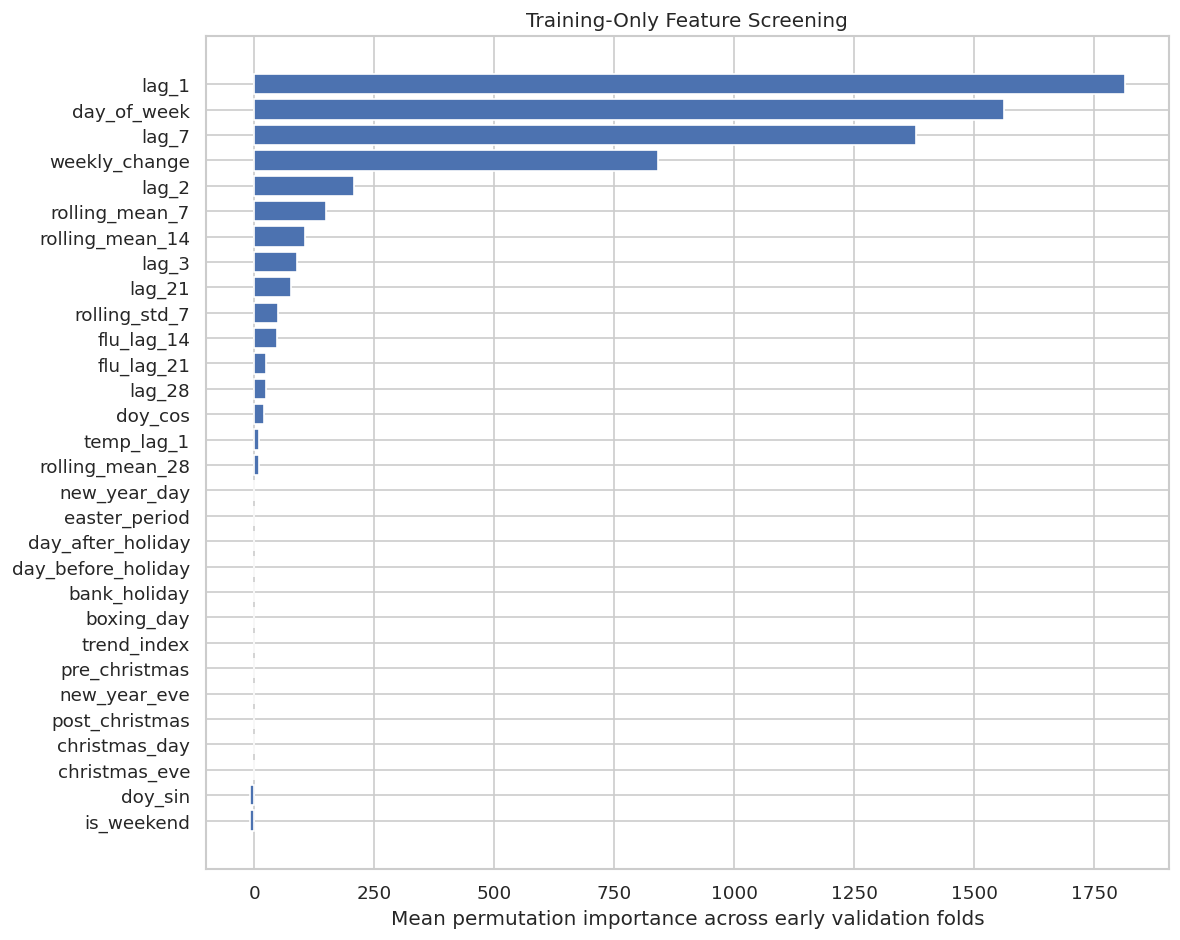

In [52]:
# Visualise the selected predictors

selection_plot_data = feature_selection_rank.head(30).sort_values("Mean_Importance")

plt.figure(figsize=(10, 8))
plt.barh(selection_plot_data["Feature"], selection_plot_data["Mean_Importance"])
plt.title("Training-Only Feature Screening")
plt.xlabel("Mean permutation importance across early validation folds")
plt.tight_layout()
plt.savefig(Figures / "feature_selection_ranking.png", dpi=180, bbox_inches="tight")
plt.show()

In [53]:
# Summarise the selected feature groups

selected_group_summary = pd.DataFrame({
    "Feature_Group": ["Demand history", "Calendar and holidays", "Weather", "Flu"],
    "Selected_Count": [
        len([feature for feature in ml_features if feature in history_features]),
        len([feature for feature in ml_features if feature in calendar_features]),
        len([feature for feature in ml_features if feature in weather_features]),
        len([feature for feature in ml_features if feature in flu_features])
    ]
})

display(selected_group_summary)
print("The selected demand-history features are:", selected_history)

,Feature_Group,Selected_Count
0,Demand history,9
1,Calendar and holidays,16
2,Weather,3
3,Flu,3


The selected demand-history features are: ['lag_1', 'lag_7', 'weekly_change', 'lag_2', 'rolling_mean_7', 'rolling_mean_14', 'lag_3', 'lag_21', 'rolling_std_7']


### **Feature-selection decision**

Only the highly related demand-history variables are pruned automatically. The external and seasonal factors remain available to the models so their contribution can be tested later through permutation importance, SHAP and feature-group ablation.

In [54]:
# Reusable ML walk-forward function

def run_ml_cv(model_name, model_type, params, features):
    fold_rows = []
    oof_rows = []

    for fold, (train_idx, val_idx) in enumerate(cv_splits, start=1):
        fold_train = train_calendar.iloc[train_idx].copy()
        fold_val = train_calendar.iloc[val_idx].copy()
        fit_train = fold_train[fold_train["model_A01"].notna()].copy()
        score_val = fold_val[fold_val["model_A01"].notna()].copy()
        mae_scale, mse_scale = seasonal_scales(fold_train)

        model = build_ml_model(model_type, params)
        model.fit(fit_train[features], fit_train["model_A01"])
        prediction = model.predict(score_val[features])

        metrics = forecast_metrics(score_val["model_A01"], prediction, mae_scale, mse_scale)
        fold_rows.append({"fold": fold, "Model": model_name, **metrics})

        for date, actual, pred in zip(score_val["Date"], score_val["model_A01"], prediction):
            oof_rows.append({"fold": fold, "Date": date, "Model": model_name, "Actual": actual, "Predicted": pred})

    return pd.DataFrame(fold_rows), pd.DataFrame(oof_rows)

In [55]:
# Initial boosting comparison

xgb_fold, xgb_oof = run_ml_cv("XGBoost", "XGBoost", {}, ml_features)
lgb_fold, lgb_oof = run_ml_cv("LightGBM", "LightGBM", {}, ml_features)
cat_fold, cat_oof = run_ml_cv("CatBoost", "CatBoost", {}, ml_features)

initial_boosting = pd.concat([xgb_fold, lgb_fold, cat_fold], ignore_index=True)
display(initial_boosting.groupby("Model")[["ME", "MAE", "RMSE", "R2", "MASE", "RMSSE"]].mean().round(2))

initial_boosting.to_csv(Saved_Outputs / "initial_boosting_cv.csv", index=False)

,ME,MAE,RMSE,R2,MASE,RMSSE
Model,,,,,,
CatBoost,-271.38,1937.74,2894.99,0.90,0.38,0.31
LightGBM,152.35,2598.09,3870.65,0.82,0.52,0.41
XGBoost,-582.29,2181.64,3286.99,0.87,0.43,0.35


# **15. Hyperparameter Tuning with Optuna**

The feature set is frozen before tuning starts. Optuna searches the boosting hyperparameters using the designated tuning folds only.

The purpose of tuning is to improve generalisation on later dates, not to obtain the lowest possible training error. The tuned settings are frozen before the five model-comparison folds are evaluated.

In [56]:
# Mean tuning-period MAE for Optuna

def cv_mae(model_type, params):
    scores = []

    for train_idx, val_idx in tuning_splits:
        fold_train = precomparison_calendar.iloc[train_idx].copy()
        fold_val = precomparison_calendar.iloc[val_idx].copy()

        fit_train = fold_train[fold_train["model_A01"].notna()]
        score_val = fold_val[fold_val["model_A01"].notna()]

        model = build_ml_model(model_type, params)
        model.fit(fit_train[ml_features], fit_train["model_A01"])
        prediction = model.predict(score_val[ml_features])

        scores.append(mean_absolute_error(score_val["model_A01"], prediction))

    return float(np.mean(scores))

In [57]:
# XGBoost objective

def xgb_objective(trial):
    params = {
        "n_estimators": trial.suggest_int("n_estimators", 250, 900),
        "learning_rate": trial.suggest_float("learning_rate", 0.01, 0.12, log=True),
        "max_depth": trial.suggest_int("max_depth", 2, 7),
        "min_child_weight": trial.suggest_int("min_child_weight", 1, 10),
        "subsample": trial.suggest_float("subsample", 0.65, 1.0),
        "colsample_bytree": trial.suggest_float("colsample_bytree", 0.65, 1.0),
        "reg_alpha": trial.suggest_float("reg_alpha", 1e-4, 5.0, log=True),
    }
    return cv_mae("XGBoost", params)

xgb_study = optuna.create_study(direction="minimize")
xgb_study.optimize(xgb_objective, n_trials=20)

print("Best XGBoost CV MAE:", round(xgb_study.best_value, 2))
print(xgb_study.best_params)

Best XGBoost CV MAE: 1949.42
{'n_estimators': 900, 'learning_rate': 0.021909484731288693, 'max_depth': 2, 'min_child_weight': 3, 'subsample': 0.7596338339888999, 'colsample_bytree': 0.8357100959968771, 'reg_alpha': 0.0006100797410827556}


In [58]:
# LightGBM objective

def lgb_objective(trial):
    params = {
        "n_estimators": trial.suggest_int("n_estimators", 250, 900),
        "learning_rate": trial.suggest_float("learning_rate", 0.01, 0.12, log=True),
        "num_leaves": trial.suggest_int("num_leaves", 15, 63),
        "max_depth": trial.suggest_int("max_depth", 3, 10),
        "min_child_samples": trial.suggest_int("min_child_samples", 10, 50),
        "subsample": trial.suggest_float("subsample", 0.65, 1.0),
        "colsample_bytree": trial.suggest_float("colsample_bytree", 0.65, 1.0),
        "reg_alpha": trial.suggest_float("reg_alpha", 1e-4, 5.0, log=True),
    }
    return cv_mae("LightGBM", params)

lgb_study = optuna.create_study(direction="minimize")
lgb_study.optimize(lgb_objective, n_trials=20)

print("Best LightGBM CV MAE:", round(lgb_study.best_value, 2))
print(lgb_study.best_params)

Best LightGBM CV MAE: 2054.88
{'n_estimators': 266, 'learning_rate': 0.01975950181142581, 'num_leaves': 25, 'max_depth': 8, 'min_child_samples': 10, 'subsample': 0.9174789170498903, 'colsample_bytree': 0.7654643045743843, 'reg_alpha': 0.010135331615182572}


In [59]:
# CatBoost objective

def cat_objective(trial):
    params = {
        "iterations": trial.suggest_int("iterations", 250, 900),
        "learning_rate": trial.suggest_float("learning_rate", 0.01, 0.12, log=True),
        "depth": trial.suggest_int("depth", 4, 9),
        "l2_leaf_reg": trial.suggest_float("l2_leaf_reg", 1.0, 15.0),
        "random_strength": trial.suggest_float("random_strength", 0.0, 2.0)
    }
    return cv_mae("CatBoost", params)

cat_study = optuna.create_study(direction="minimize")
cat_study.optimize(cat_objective, n_trials=20)

print("Best CatBoost CV MAE:", round(cat_study.best_value, 2))
print(cat_study.best_params)

Best CatBoost CV MAE: 1748.56
{'iterations': 631, 'learning_rate': 0.027385619396504572, 'depth': 5, 'l2_leaf_reg': 7.652406605981951, 'random_strength': 1.326109980715963}


In [60]:
# Save tuning results

tuning_results = pd.DataFrame({
    "Model": ["XGBoost", "LightGBM", "CatBoost"],
    "Best_CV_MAE": [xgb_study.best_value, lgb_study.best_value, cat_study.best_value],
    "Best_Params": [str(xgb_study.best_params), str(lgb_study.best_params), str(cat_study.best_params)]
})

display(tuning_results)
tuning_results.to_csv(Saved_Outputs / "optuna_tuning_results.csv", index=False)

# Re-run tuned models on the same frozen folds

tuned_xgb_fold, tuned_xgb_oof = run_ml_cv("Tuned XGBoost", "XGBoost", xgb_study.best_params, ml_features)
tuned_lgb_fold, tuned_lgb_oof = run_ml_cv("Tuned LightGBM", "LightGBM", lgb_study.best_params, ml_features)
tuned_cat_fold, tuned_cat_oof = run_ml_cv("Tuned CatBoost", "CatBoost", cat_study.best_params, ml_features)

,Model,Best_CV_MAE,Best_Params
0,XGBoost,1949.421859,"{'n_estimators': 900, 'learning_rate': 0.02190..."
1,LightGBM,2054.878572,"{'n_estimators': 266, 'learning_rate': 0.01975..."
2,CatBoost,1748.563475,"{'iterations': 631, 'learning_rate': 0.0273856..."


In [61]:
# Summarise tuning result

best_tuning_row = tuning_results.sort_values("Best_CV_MAE").iloc[0]
print("Best tuning model:", best_tuning_row["Model"])
print("Best tuning MAE:", round(best_tuning_row["Best_CV_MAE"], 2))
print("The tuned parameters are now frozen before the later model-comparison folds.")

Best tuning model: CatBoost
Best tuning MAE: 1748.56
The tuned parameters are now frozen before the later model-comparison folds.


## **15.1 Feature-Selection Audit**

Before model selection, the notebook records the final selected feature set and confirms that no forbidden variable has entered it.

In [62]:
print("Final selected ML features:", len(ml_features))
print("Forbidden selected features:", sorted(set(ml_features).intersection(forbidden)))
print("Selected feature names:")
print(ml_features)

if len(set(ml_features).intersection(forbidden)) > 0:
    raise ValueError("Leakage risk: a forbidden feature entered the selected set.")

Final selected ML features: 31
Forbidden selected features: []
Selected feature names:
['lag_1', 'lag_7', 'weekly_change', 'lag_2', 'rolling_mean_7', 'rolling_mean_14', 'lag_3', 'lag_21', 'rolling_std_7', 'day_of_week', 'is_weekend', 'doy_sin', 'doy_cos', 'trend_index', 'bank_holiday', 'day_before_holiday', 'day_after_holiday', 'pre_christmas', 'christmas_eve', 'christmas_day', 'boxing_day', 'post_christmas', 'new_year_eve', 'new_year_day', 'easter_period', 'temp_lag_1', 'temp_lag_7', 'temp_rolling_mean_7', 'flu_lag_14', 'flu_lag_21', 'flu_trend']


# **16. Training-Period Model Selection**

The tuned boosting models, SARIMAX, Prophet and the seven-day seasonal naive baseline are now compared on the same five later chronological folds.

The main selection criterion is mean MAE. RMSE, MASE, RMSSE, R² and Mean Error are reported to show large-error behaviour, scaled performance, explained variation and forecast bias. The model with the lowest mean comparison-fold MAE is selected before the held-out test is scored.

In [63]:
# Combine development results

comparison_fold = pd.concat([baseline_fold, sarimax_fold, prophet_fold, tuned_xgb_fold, tuned_lgb_fold, tuned_cat_fold], ignore_index=True)
comparison_oof = pd.concat([baseline_oof, sarimax_oof, prophet_oof, tuned_xgb_oof, tuned_lgb_oof, tuned_cat_oof], ignore_index=True)

leaderboard = comparison_fold.groupby("Model").agg(
    ME_mean=("ME", "mean"),
    ME_sd=("ME", "std"),
    MAE_mean=("MAE", "mean"),
    MAE_sd=("MAE", "std"),
    RMSE_mean=("RMSE", "mean"),
    RMSE_sd=("RMSE", "std"),
    R2_mean=("R2", "mean"),
    MASE_mean=("MASE", "mean"),
    RMSSE_mean=("RMSSE", "mean")
).sort_values("MAE_mean").reset_index()

display(leaderboard.round(3))

comparison_fold.to_csv(Saved_Outputs / "training_fold_metrics.csv", index=False)
comparison_oof.to_csv(Saved_Outputs / "training_oof_predictions.csv", index=False)
leaderboard.to_csv(Saved_Outputs / "training_model_leaderboard.csv", index=False)

,Model,ME_mean,ME_sd,MAE_mean,MAE_sd,RMSE_mean,RMSE_sd,R2_mean,MASE_mean,RMSSE_mean
0,Tuned CatBoost,-325.682,679.522,1911.914,766.409,2862.184,1472.308,0.905,0.379,0.306
1,Tuned LightGBM,-512.022,498.279,2098.446,949.032,3190.548,1778.285,0.877,0.417,0.341
2,Tuned XGBoost,-728.376,913.137,2386.425,959.127,3633.134,2096.850,0.843,0.474,0.388
3,SARIMAX,-79.710,312.048,2487.731,1005.137,3557.513,1775.802,0.851,0.493,0.379
4,Seasonal Naive,-103.561,229.956,3845.896,1691.602,5755.966,2927.280,0.586,0.765,0.617
5,Prophet,679.735,3744.891,4497.308,1682.064,6103.373,3063.248,0.565,0.892,0.651


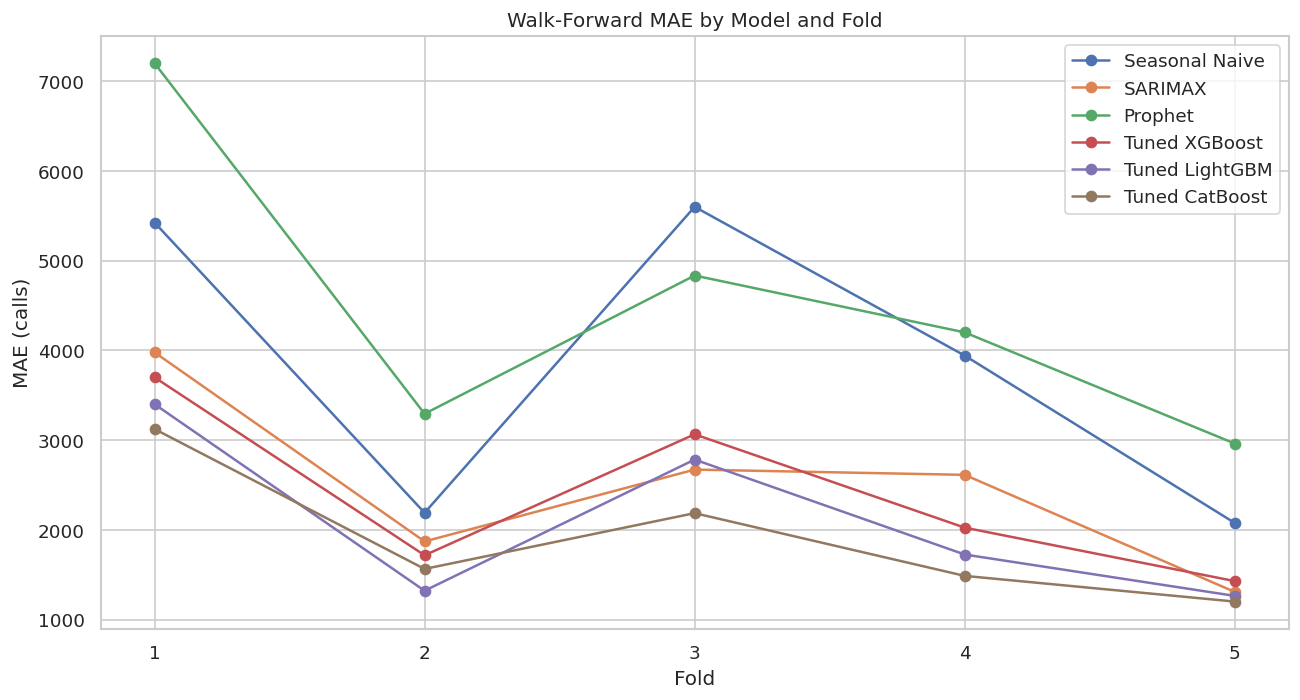

In [64]:
# Development MAE across folds

plt.figure(figsize=(11, 6))

for model_name in comparison_fold["Model"].unique():
    model_rows = comparison_fold[comparison_fold["Model"] == model_name]
    plt.plot(model_rows["fold"], model_rows["MAE"], marker="o", label=model_name)

plt.xticks(sorted(comparison_fold["fold"].unique()))
plt.title("Walk-Forward MAE by Model and Fold")
plt.xlabel("Fold")
plt.ylabel("MAE (calls)")
plt.legend()
plt.tight_layout()
plt.savefig(Figures / "15_cv_mae_by_fold.png", dpi=180, bbox_inches="tight")
plt.show()

In [65]:
# Summarise model-comparison result

development_best = leaderboard.iloc[0]
development_second = leaderboard.iloc[1]
print("Selected model before final test:", development_best["Model"])
print("Mean comparison-fold MAE:", round(development_best["MAE_mean"], 2))
print("Second model:", development_second["Model"])
print("Second model mean MAE:", round(development_second["MAE_mean"], 2))

Selected model before final test: Tuned CatBoost
Mean comparison-fold MAE: 1911.91
Second model: Tuned LightGBM
Second model mean MAE: 2098.45


## **16.1 Exploratory Friedman Test on Development Folds**

The Friedman test is reported as a training-period diagnostic of whether model rankings are consistent across the shared chronological folds.

Because the boosting hyperparameters were also selected using this development period, this p-value is not treated as the final inferential comparison. Formal forecast-error comparison is carried out after all models are frozen using the held-out test period.

In [66]:
# Global fold-level comparison

mae_pivot = comparison_fold.pivot(index="fold", columns="Model", values="MAE").dropna()
model_names = mae_pivot.columns.tolist()
friedman_inputs = [mae_pivot[name].to_numpy() for name in model_names]

friedman_stat, friedman_p = stats.friedmanchisquare(*friedman_inputs)

print("Friedman statistic:", round(friedman_stat, 4))
print("Friedman p-value:", round(friedman_p, 6))

Friedman statistic: 22.4857
Friedman p-value: 0.000423


In [67]:
# Interpret the Friedman test

print("Friedman p-value:", round(friedman_p, 6))
if friedman_p < 0.05:
    print("The shared comparison folds provide evidence that the models do not all perform the same.")
else:
    print("The shared comparison folds do not provide strong evidence of a difference between the models.")

Friedman p-value: 0.000423
The shared comparison folds provide evidence that the models do not all perform the same.


## **16.2 Development-Fold Error Comparison**

A Diebold-Mariano-style comparison is retained here as a development diagnostic only. It describes training-period stability but is not treated as the final statistical evidence because model tuning also used the development period.

The final held-out comparison is performed only after the feature set, model choice and hyperparameters are frozen.

In [68]:
# Select the model using training results only

selected_model = leaderboard.iloc[0]["Model"]
print("Model selected before test evaluation:", selected_model)

def dm_style_test(best_data, other_data, lag=7):
    merged = best_data.merge(other_data, on=["fold", "Date", "Actual"], suffixes=("_best", "_other"))
    loss_best = np.abs(merged["Actual"] - merged["Predicted_best"])
    loss_other = np.abs(merged["Actual"] - merged["Predicted_other"])
    d = (loss_best - loss_other).to_numpy()
    n = len(d)
    mean_d = d.mean()
    centered = d - mean_d
    variance = np.mean(centered ** 2)

    for k in range(1, min(lag, n - 1) + 1):
        covariance = np.mean(centered[k:] * centered[:-k])
        variance += 2 * (1 - k / (lag + 1)) * covariance

    if variance <= 0 or n < 3:
        return np.nan, np.nan, n

    statistic = mean_d / np.sqrt(variance / n)
    p_value = 2 * (1 - stats.norm.cdf(abs(statistic)))
    return statistic, p_value, n

best_oof = comparison_oof[comparison_oof["Model"] == selected_model].copy()
dm_rows = []

for other_model in leaderboard["Model"]:
    if other_model == selected_model:
        continue

    other_oof = comparison_oof[comparison_oof["Model"] == other_model].copy()
    statistic, p_value, n = dm_style_test(best_oof, other_oof)
    dm_rows.append([selected_model, other_model, statistic, p_value, n])

dm_results = pd.DataFrame(dm_rows, columns=["Best_Model", "Compared_With", "DM_stat", "p_value", "n"])
dm_results["p_bonferroni"] = np.minimum(dm_results["p_value"] * len(dm_results), 1.0)

display(dm_results.round(5))
dm_results.to_csv(Saved_Outputs / "forecast_error_significance.csv", index=False)

Model selected before test evaluation: Tuned CatBoost


,Best_Model,Compared_With,DM_stat,p_value,n,p_bonferroni
0,Tuned CatBoost,Tuned LightGBM,-1.41650,0.15663,280,0.78315
1,Tuned CatBoost,Tuned XGBoost,-3.52770,0.00042,280,0.00210
2,Tuned CatBoost,SARIMAX,-3.82606,0.00013,280,0.00065
3,Tuned CatBoost,Seasonal Naive,-4.70908,0.00000,280,0.00001
4,Tuned CatBoost,Prophet,-6.31475,0.00000,280,0.00000


### **Model Selection Rule**

The final model is selected from the chronological training-period development results before final test scoring.

The feature set and boosting search spaces are then frozen. The later test error analysis is descriptive and is **not used to add new lag features, holiday features or retune the selected model**.

# **17. Final Held-Out Test Evaluation**

All pre-specified models are evaluated on the final 280-day held-out period.

The forecasting task is one day ahead. For each forecast date, information from earlier dates may be used because it would already be known in a real deployment. Prophet is therefore updated through expanding one-day-ahead refitting, SARIMAX updates its state, and the boosting models use lagged features created from earlier observed dates.

Known partial-reporting dates remain missing as evaluation targets and are not scored.

In [69]:
# Full training data

full_train = train_calendar.copy()
fit_train = full_train[full_train["model_A01"].notna()].copy()
test_predictions = test_calendar[["Date", "reported_A01", "model_A01", "partial_reporting"]].copy()
test_mae_scale, test_mse_scale = seasonal_scales(full_train)

# Seasonal naive

seasonal_pred = test_calendar["lag_7"].copy()
seasonal_fallback = test_calendar[["lag_7", "lag_14", "lag_21", "lag_28"]].median(axis=1)
test_predictions["Seasonal Naive"] = seasonal_pred.fillna(seasonal_fallback).to_numpy()

In [70]:
# Final tuned ML models

final_ml_models = {}

final_xgb = build_ml_model("XGBoost", xgb_study.best_params)
final_xgb.fit(fit_train[ml_features], fit_train["model_A01"])
test_predictions["Tuned XGBoost"] = final_xgb.predict(test_calendar[ml_features])
final_ml_models["Tuned XGBoost"] = final_xgb

final_lgb = build_ml_model("LightGBM", lgb_study.best_params)
final_lgb.fit(fit_train[ml_features], fit_train["model_A01"])
test_predictions["Tuned LightGBM"] = final_lgb.predict(test_calendar[ml_features])
final_ml_models["Tuned LightGBM"] = final_lgb

final_cat = build_ml_model("CatBoost", cat_study.best_params)
final_cat.fit(fit_train[ml_features], fit_train["model_A01"])
test_predictions["Tuned CatBoost"] = final_cat.predict(test_calendar[ml_features])
final_ml_models["Tuned CatBoost"] = final_cat

In [71]:
# Final Prophet one-day-ahead test walk-forward

print("Running final Prophet one-day-ahead test evaluation...")

prophet_test_predictions, final_prophet = prophet_walk_forward(full_train, test_calendar)
test_predictions["Prophet"] = prophet_test_predictions

print("Prophet test predictions complete.")

Running final Prophet one-day-ahead test evaluation...
Prophet test predictions complete.


In [72]:
# Final SARIMAX model and one-day-ahead test walk-forward

sarimax_train = full_train.set_index("Date").asfreq("D")

final_sarimax = SARIMAX(sarimax_train["model_A01"], exog=sarimax_train[sarimax_features], order=best_sarimax_order, seasonal_order=best_sarimax_seasonal, trend="c", enforce_stationarity=False, enforce_invertibility=False)
final_sarimax_result = final_sarimax.fit(disp=False, maxiter=500)
final_sarimax_converged = bool(final_sarimax_result.mle_retvals.get("converged", False))

print("Final SARIMAX converged:", final_sarimax_converged)

sarimax_test_predictions = []

for _, row in test_calendar.iterrows():
    date = row["Date"]
    exog_row = pd.DataFrame([row[sarimax_features].to_dict()], index=[date])
    pred = float(final_sarimax_result.get_forecast(steps=1, exog=exog_row).predicted_mean.iloc[0])
    sarimax_test_predictions.append(pred)

    observed = pd.Series([row["model_A01"]], index=[date], name="model_A01")
    final_sarimax_result = final_sarimax_result.append(observed, exog=exog_row, refit=False)

test_predictions["SARIMAX"] = sarimax_test_predictions

Final SARIMAX converged: True


In [73]:
# Final held-out test metrics

test_model_names = ["Seasonal Naive", "SARIMAX", "Prophet", "Tuned XGBoost", "Tuned LightGBM", "Tuned CatBoost"]
test_metric_rows = []

for model_name in test_model_names:
    valid = test_predictions["model_A01"].notna() & test_predictions[model_name].notna()
    metrics = forecast_metrics(test_predictions.loc[valid, "model_A01"], test_predictions.loc[valid, model_name], test_mae_scale, test_mse_scale)
    test_metric_rows.append({"Model": model_name, "Scored_Days": int(valid.sum()), **metrics})

test_leaderboard = pd.DataFrame(test_metric_rows).sort_values("MAE").reset_index(drop=True)

baseline_mae = test_leaderboard.loc[test_leaderboard["Model"] == "Seasonal Naive", "MAE"].iloc[0]
test_leaderboard["MAE_Improvement_vs_Seasonal_Naive_pct"] = 100 * (baseline_mae - test_leaderboard["MAE"]) / baseline_mae

print("Pre-selected model:", selected_model)
print("\nFinal held-out test results:")
display(test_leaderboard.round(3))

test_predictions.to_csv(Saved_Outputs / "final_test_predictions.csv", index=False)
test_leaderboard.to_csv(Saved_Outputs / "final_test_leaderboard.csv", index=False)

Pre-selected model: Tuned CatBoost

Final held-out test results:


,Model,Scored_Days,ME,MAE,RMSE,R2,MASE,RMSSE,MAE_Improvement_vs_Seasonal_Naive_pct
0,Tuned LightGBM,278,-429.193,2013.197,3378.038,0.896,0.420,0.381,52.074
1,Tuned CatBoost,278,-384.551,2044.493,3317.073,0.900,0.427,0.374,51.329
2,SARIMAX,278,149.895,2245.855,3856.462,0.865,0.469,0.435,46.535
3,Tuned XGBoost,278,-434.150,2276.036,3538.927,0.886,0.475,0.399,45.817
4,Prophet,278,-1314.924,3880.675,5818.593,0.692,0.810,0.656,7.617
5,Seasonal Naive,278,280.489,4200.619,7120.953,0.539,0.877,0.803,0.000


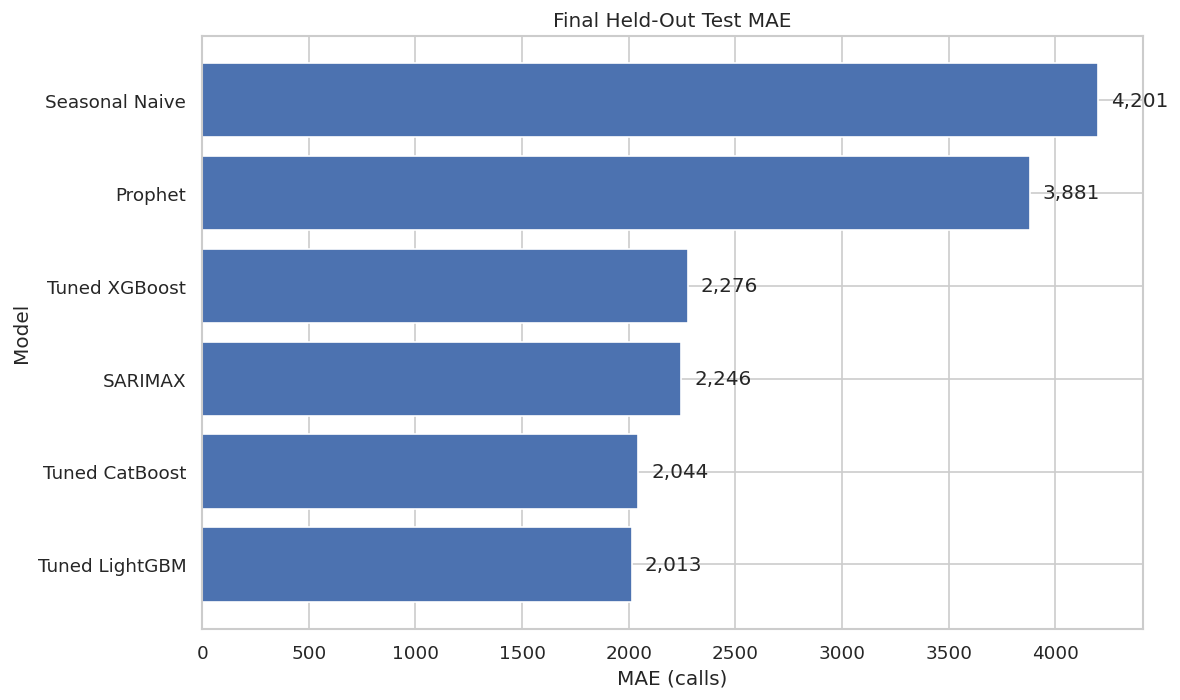

In [74]:
# Final held-out MAE ranking

test_plot = test_leaderboard.sort_values("MAE", ascending=True).copy()

plt.figure(figsize=(10, 6))
bars = plt.barh(test_plot["Model"], test_plot["MAE"])

for bar, value in zip(bars, test_plot["MAE"]):
    plt.text(value + 60, bar.get_y() + bar.get_height() / 2, f"{value:,.0f}", va="center")

plt.title("Final Held-Out Test MAE")
plt.xlabel("MAE (calls)")
plt.ylabel("Model")
plt.tight_layout()
plt.savefig(Figures / "16_final_test_mae.png", dpi=180, bbox_inches="tight")
plt.show()

In [75]:
# Summarise the final held-out test

selected_row = test_leaderboard[test_leaderboard["Model"] == selected_model].iloc[0]
numeric_best = test_leaderboard.iloc[0]
print("Pre-selected model:", selected_model)
print("Held-out MAE:", round(selected_row["MAE"], 2))
print("Held-out RMSE:", round(selected_row["RMSE"], 2))
print("Held-out R2:", round(selected_row["R2"], 3))
print("MAE improvement over seasonal naive (%):", round(selected_row["MAE_Improvement_vs_Seasonal_Naive_pct"], 2))
print("Numerically lowest held-out MAE model:", numeric_best["Model"], round(numeric_best["MAE"], 2))

Pre-selected model: Tuned CatBoost
Held-out MAE: 2044.49
Held-out RMSE: 3317.07
Held-out R2: 0.9
MAE improvement over seasonal naive (%): 51.33
Numerically lowest held-out MAE model: Tuned LightGBM 2013.2


## **17.1 Final Evaluation Audit**

Before interpreting the leaderboard, the evaluation design is checked explicitly.

All models must:

- use the same held-out dates;
- answer the same one-day-ahead forecasting question;
- exclude partial-reporting dates from scoring;
- use no future target information;
- remain frozen after the final test is inspected.

The code below confirms the number of scored dates for each model and checks that every prediction column is present.

In [76]:
# Check final evaluation consistency

evaluation_audit = test_leaderboard[["Model", "Scored_Days", "ME", "MAE", "RMSE", "R2", "MASE", "RMSSE"]].copy()

print("Held-out period:")
print(test_calendar["Date"].min(), "to", test_calendar["Date"].max())
print("\nTotal test days:")
print(len(test_calendar))
print("\nComplete target days available for scoring:")
print(test_calendar["model_A01"].notna().sum())
print("\nModel evaluation audit:")
display(evaluation_audit.round(3))

expected_scored_days = int(test_calendar["model_A01"].notna().sum())
same_scored_days = (evaluation_audit["Scored_Days"] == expected_scored_days).all()

print("\nAll models scored on the same number of valid test days:")
print(same_scored_days)

evaluation_audit.to_csv(Saved_Outputs / "final_evaluation_audit.csv", index=False)

Held-out period:
2025-08-25 00:00:00 to 2026-05-31 00:00:00

Total test days:
280

Complete target days available for scoring:
278

Model evaluation audit:


,Model,Scored_Days,ME,MAE,RMSE,R2,MASE,RMSSE
0,Tuned LightGBM,278,-429.193,2013.197,3378.038,0.896,0.420,0.381
1,Tuned CatBoost,278,-384.551,2044.493,3317.073,0.900,0.427,0.374
2,SARIMAX,278,149.895,2245.855,3856.462,0.865,0.469,0.435
3,Tuned XGBoost,278,-434.150,2276.036,3538.927,0.886,0.475,0.399
4,Prophet,278,-1314.924,3880.675,5818.593,0.692,0.810,0.656
5,Seasonal Naive,278,280.489,4200.619,7120.953,0.539,0.877,0.803



All models scored on the same number of valid test days:
True


## **17.2 Formal Held-Out Forecast Comparison**

After model development is frozen, the held-out daily forecast errors are used for the formal pairwise comparison.

The pre-selected model is compared with each alternative using a Diebold-Mariano-style absolute-loss differential with Newey-West variance to allow short-range serial dependence. Holm adjustment controls the family-wise error rate across the multiple comparisons.

These tests are interpreted together with the size of the MAE and RMSE differences. Statistical significance alone does not determine practical importance.

In [77]:
# Formal held-out comparison of frozen models

def heldout_dm_test(actual, pred_a, pred_b, lag=7):
    actual = np.asarray(actual, dtype=float)
    pred_a = np.asarray(pred_a, dtype=float)
    pred_b = np.asarray(pred_b, dtype=float)
    loss_a = np.abs(actual - pred_a)
    loss_b = np.abs(actual - pred_b)
    difference = loss_a - loss_b
    n = len(difference)
    mean_difference = difference.mean()
    centered = difference - mean_difference
    variance = np.mean(centered ** 2)

    for k in range(1, min(lag, n - 1) + 1):
        covariance = np.mean(centered[k:] * centered[:-k])
        variance += 2 * (1 - k / (lag + 1)) * covariance

    if variance <= 0 or n < 3:
        return np.nan, np.nan, n

    statistic = mean_difference / np.sqrt(variance / n)
    p_value = 2 * (1 - stats.norm.cdf(abs(statistic)))
    return statistic, p_value, n

valid_test = test_predictions["model_A01"].notna()
actual_test = test_predictions.loc[valid_test, "model_A01"].to_numpy()
selected_pred = test_predictions.loc[valid_test, selected_model].to_numpy()
heldout_dm_rows = []

for other_model in test_model_names:
    if other_model == selected_model:
        continue

    other_pred = test_predictions.loc[valid_test, other_model].to_numpy()
    statistic, p_value, n = heldout_dm_test(actual_test, selected_pred, other_pred, lag=7)
    heldout_dm_rows.append([selected_model, other_model, statistic, p_value, n])

heldout_dm = pd.DataFrame(heldout_dm_rows, columns=["Selected_Model", "Compared_With", "DM_stat", "p_value", "n"])
heldout_dm["p_holm"] = multipletests(heldout_dm["p_value"], method="holm")[1]
heldout_dm["Significant_0.05"] = heldout_dm["p_holm"] < 0.05

display(heldout_dm.round(5))
heldout_dm.to_csv(Saved_Outputs / "heldout_forecast_significance.csv", index=False)

,Selected_Model,Compared_With,DM_stat,p_value,n,p_holm,Significant_0.05
0,Tuned CatBoost,Seasonal Naive,-5.19507,0.00000,278,0.00000,True
1,Tuned CatBoost,SARIMAX,-1.25767,0.20851,278,0.41702,False
2,Tuned CatBoost,Prophet,-3.68547,0.00023,278,0.00091,True
3,Tuned CatBoost,Tuned XGBoost,-2.01320,0.04409,278,0.13228,False
4,Tuned CatBoost,Tuned LightGBM,0.34602,0.72933,278,0.72933,False


In [78]:
# Summarise held-out significance results

print("Held-out pairwise comparison after Holm correction:")
display(heldout_dm[["Compared_With", "p_holm", "Significant_0.05"]].round(5))

Held-out pairwise comparison after Holm correction:


,Compared_With,p_holm,Significant_0.05
0,Seasonal Naive,0.00000,True
1,SARIMAX,0.41702,False
2,Prophet,0.00091,True
3,Tuned XGBoost,0.13228,False
4,Tuned LightGBM,0.72933,False


## **17.3 Result Integrity Check**

Before the error analysis continues, the notebook checks that the selected model, prediction columns and descriptive calendar fields required by the remaining analysis are present.

In [79]:
# Check objects required by the remaining analysis

required_test_columns = ["Date", "model_A01", selected_model]
required_calendar_columns = ["Date", "day_of_week", "month", "bank_holiday"]

missing_test_columns = [column for column in required_test_columns if column not in test_predictions.columns]
missing_calendar_columns = [column for column in required_calendar_columns if column not in test_calendar.columns]

print("Missing prediction columns:", missing_test_columns)
print("Missing calendar columns:", missing_calendar_columns)

if missing_test_columns or missing_calendar_columns:
    raise ValueError("Required columns are missing before final error analysis.")

Missing prediction columns: []
Missing calendar columns: []


# **18. Final Error Analysis**

Overall accuracy does not show when the model fails. The held-out errors are therefore checked by date, weekday and bank-holiday status. Residual autocorrelation is also tested.

This section describes the weaknesses found after final testing. These findings are not used to add new features or retune the model.

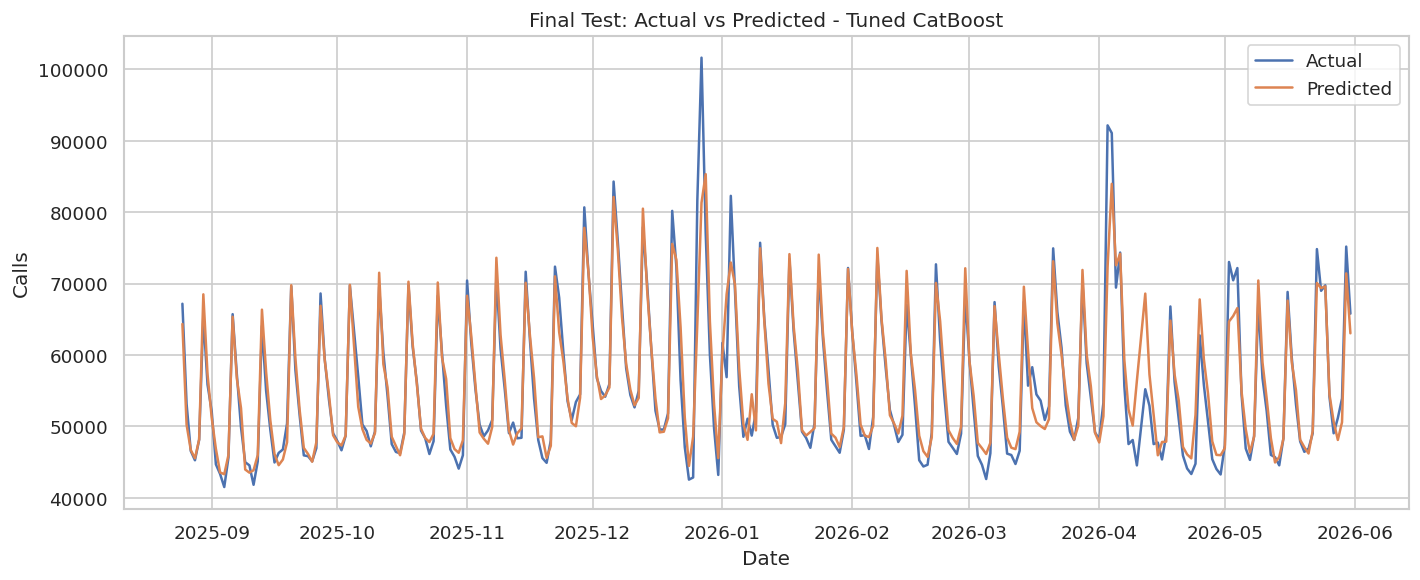

Largest final test errors:


,Date,model_A01,Predicted,Error,Absolute_Error
124,2025-12-27,101636.0,81321.04,20314.96,20314.96
221,2026-04-03,92152.0,72337.51,19814.49,19814.49
123,2025-12-26,81616.0,64429.21,17186.79,17186.79
230,2026-04-12,55198.0,68593.91,-13395.91,13395.91
228,2026-04-10,44534.0,56399.90,-11865.90,11865.90
130,2026-01-02,56892.0,68513.61,-11621.61,11621.61
131,2026-01-03,82285.0,72948.15,9336.85,9336.85
250,2026-05-02,73022.0,64680.31,8341.69,8341.69
125,2025-12-28,77087.0,85323.96,-8236.96,8236.96
119,2025-12-22,56444.0,63902.30,-7458.30,7458.30


In [80]:
# Selected model test errors

selected_test = test_predictions[test_predictions["model_A01"].notna()].copy()
selected_test["Predicted"] = selected_test[selected_model]
selected_test["Error"] = selected_test["model_A01"] - selected_test["Predicted"]
selected_test["Absolute_Error"] = selected_test["Error"].abs()

plt.figure(figsize=(12, 5))
plt.plot(selected_test["Date"], selected_test["model_A01"], label="Actual")
plt.plot(selected_test["Date"], selected_test["Predicted"], label="Predicted")
plt.title(f"Final Test: Actual vs Predicted - {selected_model}")
plt.xlabel("Date")
plt.ylabel("Calls")
plt.legend()
plt.tight_layout()
plt.savefig(Figures / "05_final_test_actual_vs_predicted.png", dpi=180, bbox_inches="tight")
plt.show()

print("Largest final test errors:")
worst_errors = selected_test.nlargest(15, "Absolute_Error")[["Date", "model_A01", "Predicted", "Error", "Absolute_Error"]]
display(worst_errors.round(2))
worst_errors.to_csv(Saved_Outputs / "final_test_worst_errors.csv", index=False)

In [81]:
# Error patterns by weekday, month and bank holiday

error_analysis = selected_test.merge(
    test_calendar[["Date", "day_of_week", "month", "bank_holiday"]],
    on="Date",
    how="left"
)

weekday_errors = error_analysis.groupby("day_of_week")["Absolute_Error"].agg(["count", "mean", "median"]).reset_index()
monthly_errors = error_analysis.groupby("month")["Absolute_Error"].agg(["count", "mean", "median"]).reset_index()
holiday_errors = error_analysis.groupby("bank_holiday")["Absolute_Error"].agg(["count", "mean", "median"]).reset_index()

print("Errors by weekday:")
display(weekday_errors.round(2))

print("Errors by month:")
display(monthly_errors.round(2))

print("Errors by bank holiday:")
display(holiday_errors.round(2))

weekday_errors.to_csv(Saved_Outputs / "final_errors_by_weekday.csv", index=False)
monthly_errors.to_csv(Saved_Outputs / "final_errors_by_month.csv", index=False)
holiday_errors.to_csv(Saved_Outputs / "final_errors_by_holiday.csv", index=False)

Errors by weekday:


,day_of_week,count,mean,median
0,0,40,2166.64,1735.31
1,1,40,1506.10,1137.57
2,2,40,1397.83,1159.42
3,3,40,1613.91,1406.37
4,4,40,2642.06,979.43
5,5,39,3041.23,2126.46
6,6,39,1966.66,1052.52


Errors by month:


,month,count,mean,median
0,1,31,2049.58,1194.88
1,2,28,1573.93,1305.01
2,3,31,1912.60,1758.65
3,4,29,4120.33,2620.09
4,5,31,1954.87,1212.67
5,8,7,1518.83,1448.81
6,9,30,1162.37,1021.65
7,10,30,1081.11,753.04
8,11,30,1481.22,1165.84
9,12,31,3193.81,1577.98


Errors by bank holiday:


,bank_holiday,count,mean,median
0,0,270,1909.08,1349.74
1,1,8,6614.77,4219.57


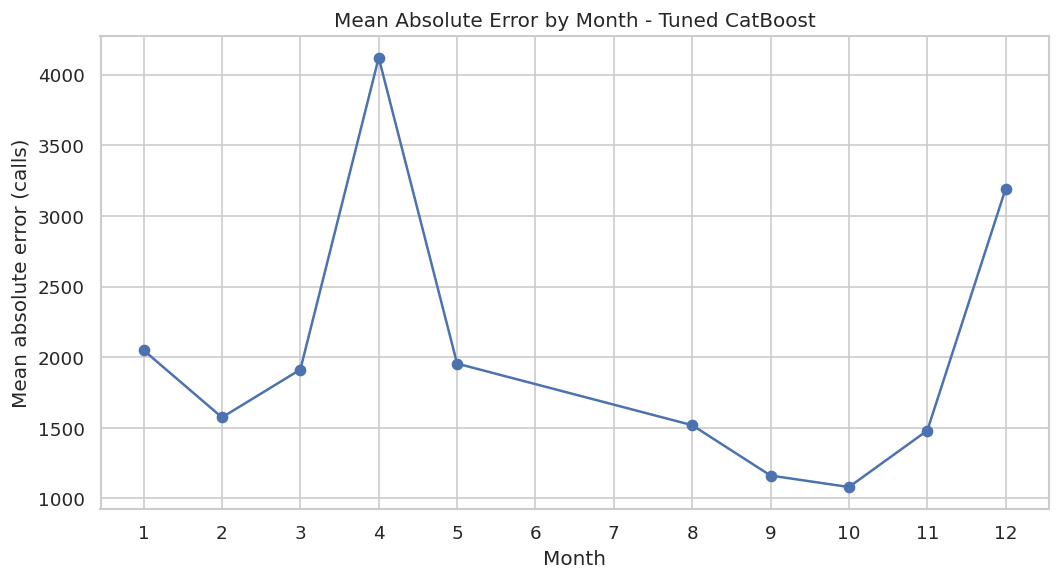

In [82]:
# Monthly held-out error profile

plt.figure(figsize=(9, 5))
plt.plot(monthly_errors["month"], monthly_errors["mean"], marker="o")
plt.xticks(range(1, 13))
plt.title(f"Mean Absolute Error by Month - {selected_model}")
plt.xlabel("Month")
plt.ylabel("Mean absolute error (calls)")
plt.tight_layout()
plt.savefig(Figures / "final_errors_by_month.png", dpi=180, bbox_inches="tight")
plt.show()

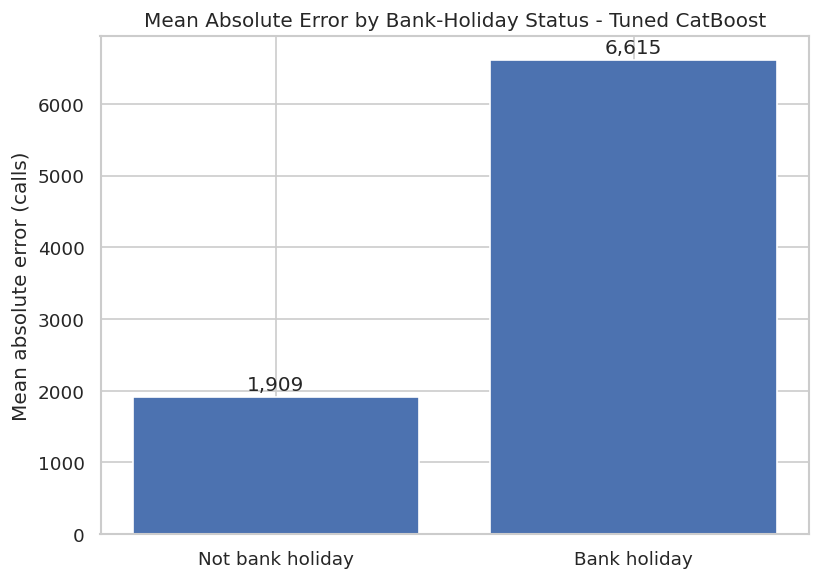

In [83]:
# Compare ordinary-day and bank-holiday errors

plt.figure(figsize=(7, 5))
bars = plt.bar(["Not bank holiday", "Bank holiday"], holiday_errors["mean"])

for bar, value in zip(bars, holiday_errors["mean"]):
    plt.text(bar.get_x() + bar.get_width() / 2, value + 100, f"{value:,.0f}", ha="center")

plt.title(f"Mean Absolute Error by Bank-Holiday Status - {selected_model}")
plt.ylabel("Mean absolute error (calls)")
plt.tight_layout()
plt.savefig(Figures / "17_holiday_error_comparison.png", dpi=180, bbox_inches="tight")
plt.show()

In [84]:
# Summarise holiday errors

normal_error = holiday_errors.loc[holiday_errors["bank_holiday"] == 0, "mean"].iloc[0]
holiday_error = holiday_errors.loc[holiday_errors["bank_holiday"] == 1, "mean"].iloc[0]
print("Mean absolute error on ordinary days:", round(normal_error, 2))
print("Mean absolute error on bank holidays:", round(holiday_error, 2))

Mean absolute error on ordinary days: 1909.08
Mean absolute error on bank holidays: 6614.77


### **What the holiday error analysis means**

This result shows whether the selected model is equally accurate on ordinary days and bank holidays. A much larger holiday MAE would mean that holiday demand remains a specific weakness even after the model has access to bank-holiday and festive-period features.

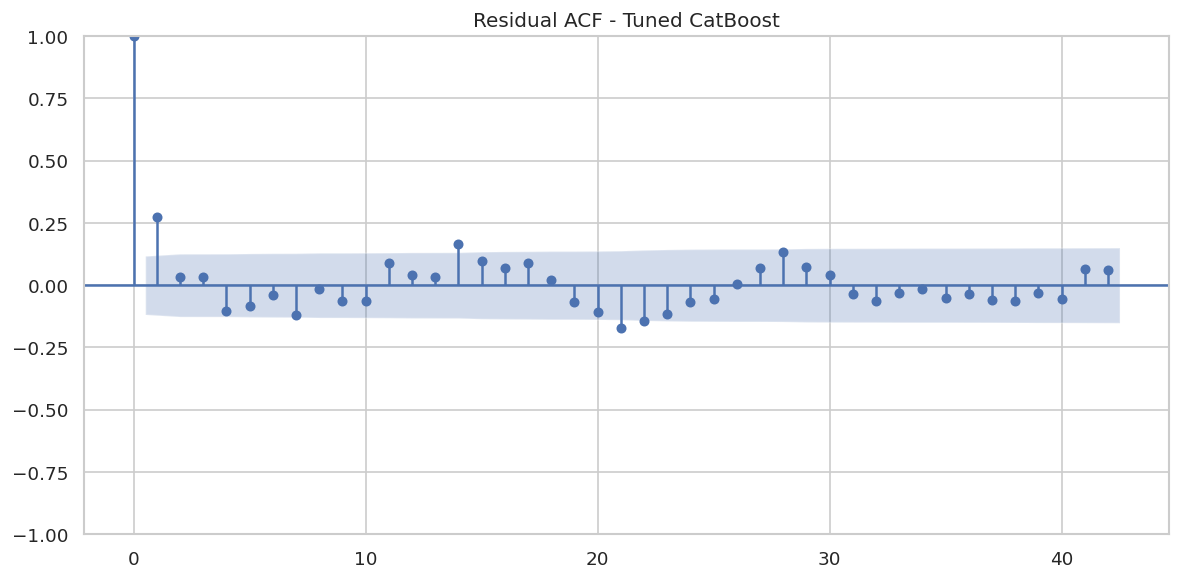

,lb_stat,lb_pvalue
7,31.2621,0.0001
14,44.7076,0.0000


In [85]:
# Residual autocorrelation and Ljung-Box test

residuals = selected_test["Error"].dropna()

fig, ax = plt.subplots(figsize=(10, 5))
plot_acf(residuals, lags=42, ax=ax)
ax.set_title(f"Residual ACF - {selected_model}")
fig.tight_layout()
fig.savefig(Figures / "06_selected_model_residual_acf.png", dpi=180, bbox_inches="tight")
plt.show()

ljung_box = acorr_ljungbox(residuals, lags=[7, 14], return_df=True)
display(ljung_box.round(4))
ljung_box.to_csv(Saved_Outputs / "selected_model_ljung_box.csv")

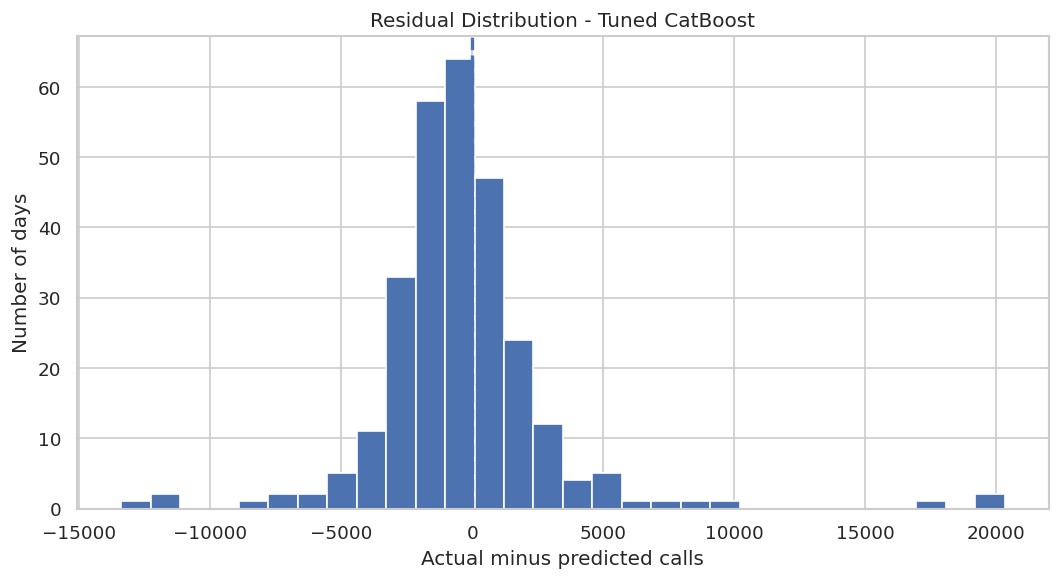

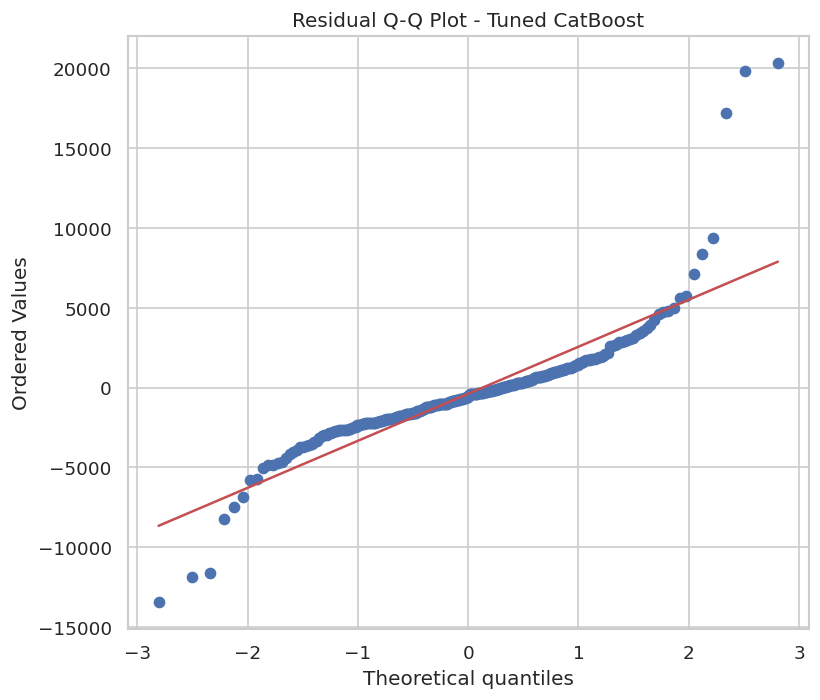

In [86]:
# Residual distribution

plt.figure(figsize=(9, 5))
plt.hist(residuals, bins=30)
plt.axvline(0, linestyle="--", linewidth=2)
plt.title(f"Residual Distribution - {selected_model}")
plt.xlabel("Actual minus predicted calls")
plt.ylabel("Number of days")
plt.tight_layout()
plt.savefig(Figures / "18_residual_distribution.png", dpi=180, bbox_inches="tight")
plt.show()

# Q-Q plot

plt.figure(figsize=(7, 6))
stats.probplot(residuals, dist="norm", plot=plt)
plt.title(f"Residual Q-Q Plot - {selected_model}")
plt.tight_layout()
plt.savefig(Figures / "19_residual_qq.png", dpi=180, bbox_inches="tight")
plt.show()

### **What the residual checks show**

The Ljung-Box p-values at lags 7 and 14 are below 0.001. The remaining errors are still serially correlated.

The model has captured a large part of the weekly pattern, but some repeating structure remains unexplained. This is recorded as a limitation and an area for future work.

# **19. Which Factors Influence Forecasting Performance?**

The second part of the research question asks which factors contribute most to forecasting demand.

Three checks are used because one importance measure is not enough:

1. permutation importance measures how much validation error changes when a feature is disrupted;
2. SHAP shows how strongly features contribute to the fitted boosting model;
3. feature-group ablation removes demand history, calendar, weather or flu features and measures the change in walk-forward MAE.

These results describe predictive contribution. They do not establish that a factor causes NHS 111 demand to change.

In [87]:
# Select the best boosting model using training CV only

boosting_names = ["Tuned XGBoost", "Tuned LightGBM", "Tuned CatBoost"]
boosting_leaderboard = leaderboard[leaderboard["Model"].isin(boosting_names)].sort_values("MAE_mean").reset_index(drop=True)
best_boosting = boosting_leaderboard.iloc[0]["Model"]

if best_boosting == "Tuned XGBoost":
    best_boosting_type = "XGBoost"
    best_boosting_params = xgb_study.best_params
elif best_boosting == "Tuned LightGBM":
    best_boosting_type = "LightGBM"
    best_boosting_params = lgb_study.best_params
else:
    best_boosting_type = "CatBoost"
    best_boosting_params = cat_study.best_params

print("Boosting model used for interpretability:", best_boosting)

Boosting model used for interpretability: Tuned CatBoost


## **19.1 Permutation Importance**

Permutation importance is calculated on the final training validation fold rather than the test set. This prevents the test set from influencing feature interpretation or later modelling decisions.

In [88]:
# Fit on the final training fold and explain its validation period

last_train_idx, last_val_idx = cv_splits[-1]
importance_train = train_calendar.iloc[last_train_idx].copy()
importance_val = train_calendar.iloc[last_val_idx].copy()

importance_train = importance_train[importance_train["model_A01"].notna()]
importance_val = importance_val[importance_val["model_A01"].notna()]

importance_model = build_ml_model(best_boosting_type, best_boosting_params)
importance_model.fit(importance_train[ml_features], importance_train["model_A01"])

perm = permutation_importance(importance_model, importance_val[ml_features], importance_val["model_A01"], scoring="neg_mean_absolute_error", n_repeats=20, random_state=RANDOM_STATE)

permutation_table = pd.DataFrame({
    "Feature": ml_features,
    "Importance_Mean": perm.importances_mean,
    "Importance_SD": perm.importances_std
}).sort_values("Importance_Mean", ascending=False).reset_index(drop=True)

display(permutation_table.round(3))
permutation_table.to_csv(Saved_Outputs / "permutation_importance.csv", index=False)

,Feature,Importance_Mean,Importance_SD
0,day_of_week,1930.059,245.202
1,lag_7,1640.933,172.916
2,lag_1,857.749,152.724
3,is_weekend,699.779,113.248
4,lag_21,313.038,82.822
5,weekly_change,307.117,81.895
6,day_before_holiday,114.241,39.461
7,lag_2,100.305,55.617
8,temp_lag_7,24.334,15.943
9,temp_rolling_mean_7,24.069,18.465


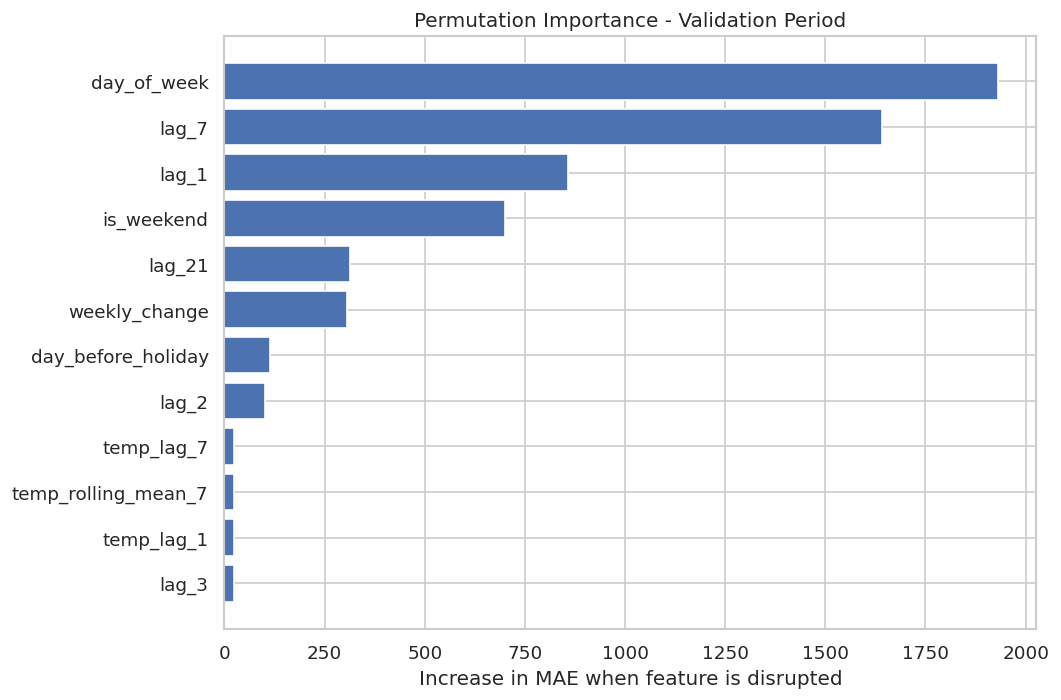

In [89]:
# Permutation importance chart

perm_plot = permutation_table.head(12).sort_values("Importance_Mean")

plt.figure(figsize=(9, 6))
plt.barh(perm_plot["Feature"], perm_plot["Importance_Mean"])
plt.title("Permutation Importance - Validation Period")
plt.xlabel("Increase in MAE when feature is disrupted")
plt.tight_layout()
plt.savefig(Figures / "20_permutation_importance.png", dpi=180, bbox_inches="tight")
plt.show()

In [90]:
# Summarise permutation importance

top_perm = permutation_table.head(5)["Feature"].tolist()
print("Top five permutation-importance features:", top_perm)

Top five permutation-importance features: ['day_of_week', 'lag_7', 'lag_1', 'is_weekend', 'lag_21']


## **19.2 SHAP**

SHAP is applied to the best boosting model fitted on the full training period. Mean absolute SHAP values provide a global ranking, while the beeswarm plot shows both the size and direction of feature effects.

,Feature,Mean_Abs_SHAP
0,lag_7,2616.374
1,day_of_week,2206.703
2,is_weekend,1494.804
3,lag_1,1320.786
4,lag_21,1115.390
5,weekly_change,1078.016
6,trend_index,551.668
7,bank_holiday,538.185
8,lag_2,497.638
9,rolling_mean_7,456.142


/tmp/ipykernel_6778/2864943637.py:20: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(shap_values, explain_data, show=False)


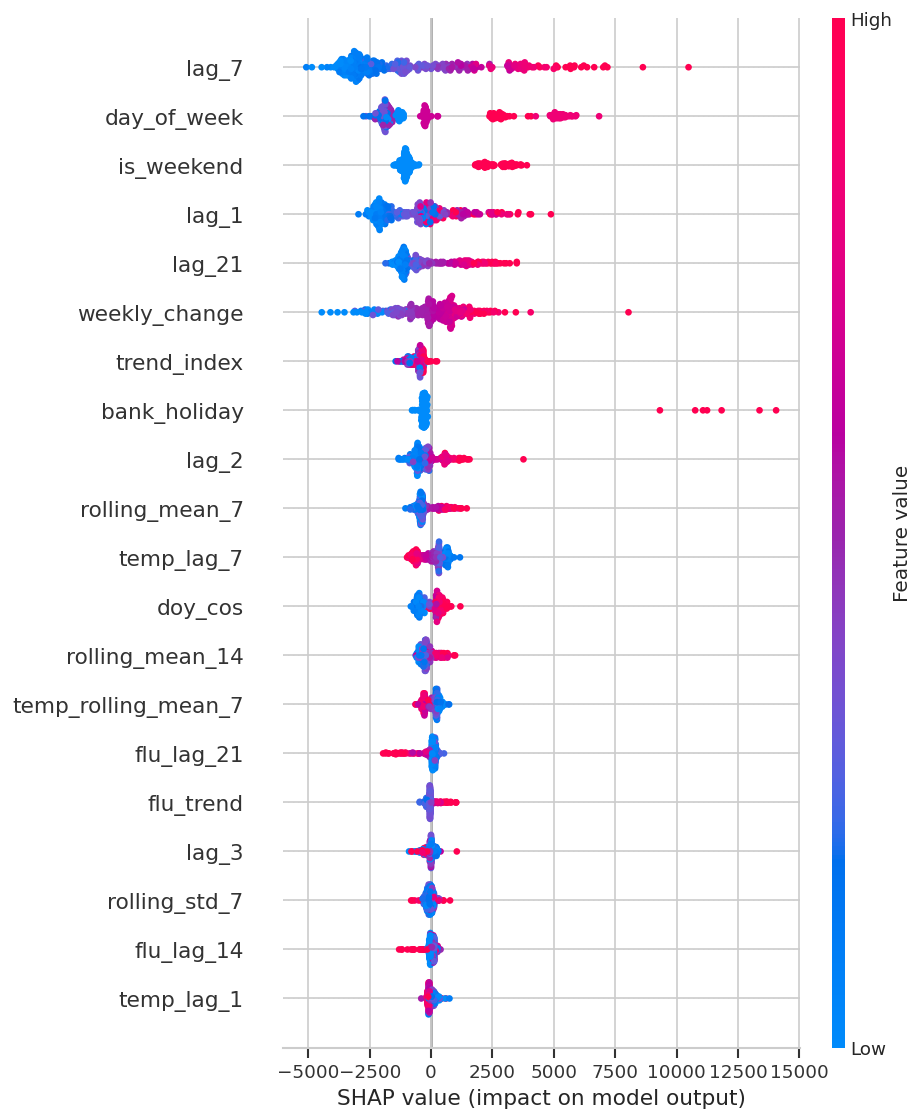

In [91]:
# Fit the final interpretability model

interpretability_model = build_ml_model(best_boosting_type, best_boosting_params)
interpretability_model.fit(fit_train[ml_features], fit_train["model_A01"])

explain_data = fit_train[ml_features].tail(min(300, len(fit_train))).copy()

explainer = shap.TreeExplainer(interpretability_model)
shap_explanation = explainer(explain_data)
shap_values = shap_explanation.values

shap_importance = pd.DataFrame({
    "Feature": ml_features,
    "Mean_Abs_SHAP": np.abs(shap_values).mean(axis=0)
}).sort_values("Mean_Abs_SHAP", ascending=False).reset_index(drop=True)

display(shap_importance.round(3))
shap_importance.to_csv(Saved_Outputs / "shap_feature_importance.csv", index=False)

shap.summary_plot(shap_values, explain_data, show=False)
plt.tight_layout()
plt.savefig(Figures / "07_shap_beeswarm.png", dpi=180, bbox_inches="tight")
plt.show()

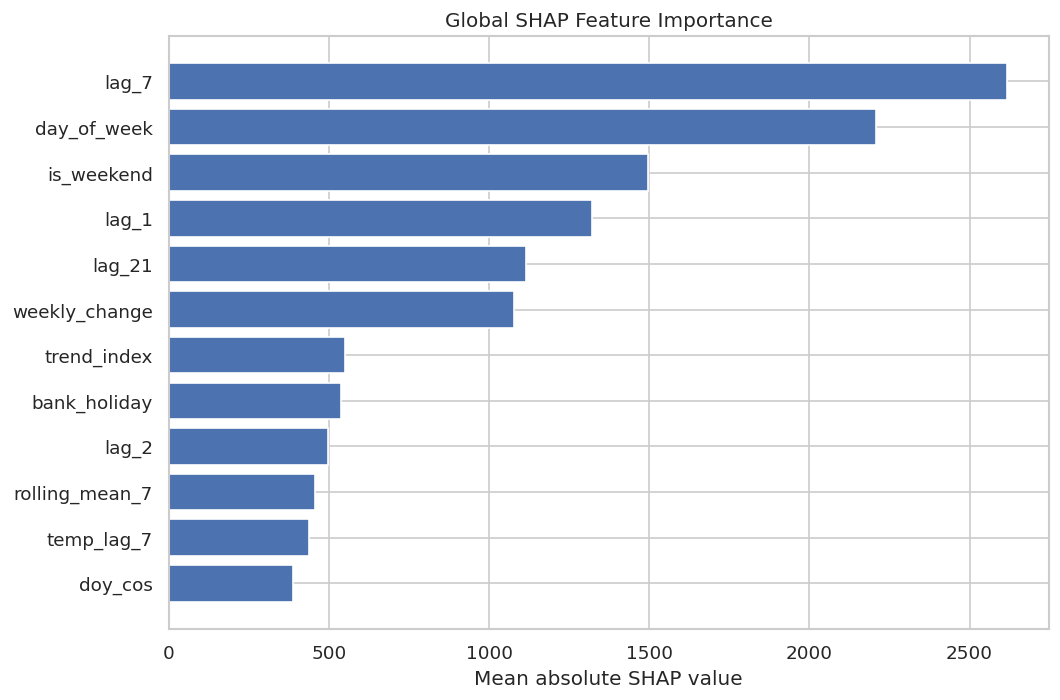

In [92]:
# SHAP global importance chart

shap_plot = shap_importance.head(12).sort_values("Mean_Abs_SHAP")

plt.figure(figsize=(9, 6))
plt.barh(shap_plot["Feature"], shap_plot["Mean_Abs_SHAP"])
plt.title("Global SHAP Feature Importance")
plt.xlabel("Mean absolute SHAP value")
plt.tight_layout()
plt.savefig(Figures / "21_shap_global_importance.png", dpi=180, bbox_inches="tight")
plt.show()

In [93]:
# Summarise SHAP importance

top_shap = shap_importance.head(5)["Feature"].tolist()
print("Top five SHAP features:", top_shap)

Top five SHAP features: ['lag_7', 'day_of_week', 'is_weekend', 'lag_1', 'lag_21']


## **19.3 Feature-Group Ablation**

The best boosting model is re-evaluated on the same walk-forward folds while one feature group is removed at a time.

If MAE rises substantially after removing a group, that group contains useful predictive information. This is stronger evidence than relying on a single feature-importance ranking.

In [94]:
# Compare the full feature set with groups removed

ablation_sets = {
    "Full model": ml_features,
    "Without demand history": [f for f in ml_features if f not in history_features],
    "Without calendar": [f for f in ml_features if f not in calendar_features],
    "Without weather": [f for f in ml_features if f not in weather_features],
    "Without flu": [f for f in ml_features if f not in flu_features]
}

ablation_rows = []

for label, features in ablation_sets.items():
    fold_result, _ = run_ml_cv(label, best_boosting_type, best_boosting_params, features)
    ablation_rows.append([label, fold_result["MAE"].mean(), fold_result["MAE"].std()])

ablation_results = pd.DataFrame(ablation_rows, columns=["Feature_Set", "MAE_Mean", "MAE_SD"])
full_mae = ablation_results.loc[ablation_results["Feature_Set"] == "Full model", "MAE_Mean"].iloc[0]
ablation_results["MAE_Increase_vs_Full"] = ablation_results["MAE_Mean"] - full_mae
ablation_results = ablation_results.sort_values("MAE_Increase_vs_Full", ascending=False).reset_index(drop=True)

display(ablation_results.round(2))
ablation_results.to_csv(Saved_Outputs / "feature_group_ablation.csv", index=False)

,Feature_Set,MAE_Mean,MAE_SD,MAE_Increase_vs_Full
0,Without demand history,2972.34,2045.97,1060.42
1,Without calendar,2301.12,955.38,389.21
2,Without flu,2010.98,893.52,99.07
3,Without weather,1915.05,834.53,3.14
4,Full model,1911.91,766.41,0.00


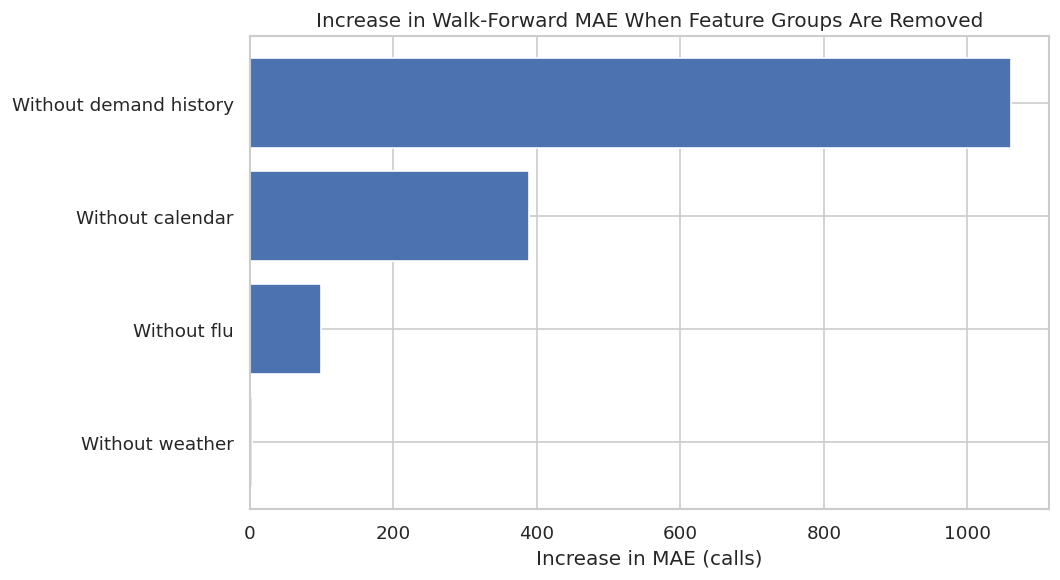

In [95]:
# Feature-group ablation chart

ablation_plot = ablation_results[ablation_results["Feature_Set"] != "Full model"].sort_values("MAE_Increase_vs_Full")

plt.figure(figsize=(9, 5))
plt.barh(ablation_plot["Feature_Set"], ablation_plot["MAE_Increase_vs_Full"])
plt.title("Increase in Walk-Forward MAE When Feature Groups Are Removed")
plt.xlabel("Increase in MAE (calls)")
plt.tight_layout()
plt.savefig(Figures / "22_feature_group_ablation.png", dpi=180, bbox_inches="tight")
plt.show()

In [96]:
# Summarise feature-group ablation

ablation_summary = ablation_results.sort_values("MAE_Increase_vs_Full", ascending=False)
display(ablation_summary.round(2))

,Feature_Set,MAE_Mean,MAE_SD,MAE_Increase_vs_Full
0,Without demand history,2972.34,2045.97,1060.42
1,Without calendar,2301.12,955.38,389.21
2,Without flu,2010.98,893.52,99.07
3,Without weather,1915.05,834.53,3.14
4,Full model,1911.91,766.41,0.00


# **20. Sensitivity Analyses**

Sensitivity analysis checks whether the conclusions depend heavily on a particular modelling choice.

Three issues are examined:

- the unusually high December 2022 demand period;
- the conservative 14-day flu lag;
- the decision not to score known partial-reporting test dates.

## **20.1 December 2022 High-Demand Period**

The primary analysis keeps the December 2022 spike because it is observed demand. As a sensitivity check, the best boosting model is also trained with the main spike window removed from each training fold while the validation dates remain unchanged.

This shows whether the unusual period materially changes forecasting accuracy.

In [97]:
# Compare model training with and without the December 2022 spike period

spike_start = pd.Timestamp("2022-12-18")
spike_end = pd.Timestamp("2023-01-02")

spike_rows = []

for remove_spike in [False, True]:
    fold_scores = []

    for train_idx, val_idx in cv_splits:
        fold_train = train_calendar.iloc[train_idx].copy()
        fold_val = train_calendar.iloc[val_idx].copy()
        fit_data = fold_train[fold_train["model_A01"].notna()].copy()
        score_data = fold_val[fold_val["model_A01"].notna()].copy()

        if remove_spike:
            fit_data = fit_data[~fit_data["Date"].between(spike_start, spike_end)]

        model = build_ml_model(best_boosting_type, best_boosting_params)
        model.fit(fit_data[ml_features], fit_data["model_A01"])
        prediction = model.predict(score_data[ml_features])
        fold_scores.append(mean_absolute_error(score_data["model_A01"], prediction))

    label = "Spike removed from training" if remove_spike else "Original training data"
    spike_rows.append([label, np.mean(fold_scores), np.std(fold_scores)])

spike_sensitivity = pd.DataFrame(spike_rows, columns=["Scenario", "MAE_Mean", "MAE_SD"])
display(spike_sensitivity.round(2))
spike_sensitivity.to_csv(Saved_Outputs / "december_2022_spike_sensitivity.csv", index=False)

,Scenario,MAE_Mean,MAE_SD
0,Original training data,1911.91,685.50
1,Spike removed from training,1808.37,578.22


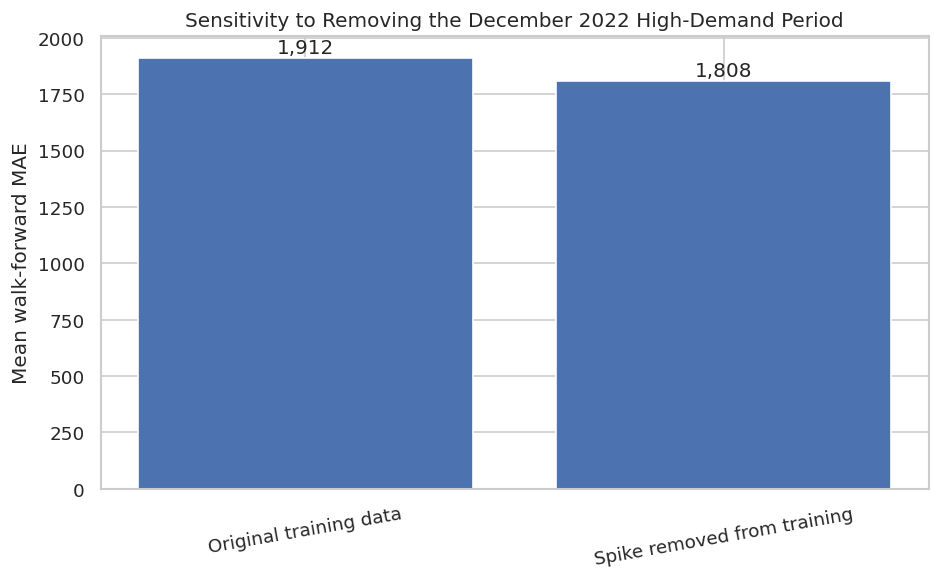

In [98]:
# December 2022 sensitivity chart

plt.figure(figsize=(8, 5))
bars = plt.bar(spike_sensitivity["Scenario"], spike_sensitivity["MAE_Mean"])

for bar, value in zip(bars, spike_sensitivity["MAE_Mean"]):
    plt.text(bar.get_x() + bar.get_width() / 2, value + 20, f"{value:,.0f}", ha="center")

plt.title("Sensitivity to Removing the December 2022 High-Demand Period")
plt.ylabel("Mean walk-forward MAE")
plt.xticks(rotation=10)
plt.tight_layout()
plt.savefig(Figures / "23_december_2022_sensitivity.png", dpi=180, bbox_inches="tight")
plt.show()

In [99]:
# Summarise December 2022 sensitivity

original_spike_mae = spike_sensitivity.loc[spike_sensitivity["Scenario"] == "Original training data", "MAE_Mean"].iloc[0]
removed_spike_mae = spike_sensitivity.loc[spike_sensitivity["Scenario"] == "Spike removed from training", "MAE_Mean"].iloc[0]
print("Original training MAE:", round(original_spike_mae, 2))
print("Spike-removed MAE:", round(removed_spike_mae, 2))
print("Difference:", round(removed_spike_mae - original_spike_mae, 2))

Original training MAE: 1911.91
Spike-removed MAE: 1808.37
Difference: -103.55


## **20.2 Flu Lag Sensitivity**

The primary model uses a 14-day flu lag to reduce the chance of using positivity information that would not have been available at forecast time.

A seven-day lag is tested only as a sensitivity analysis.

In [100]:
# Compare 14-day and 7-day flu lags

features_flu_14 = ml_features.copy()
features_flu_7 = [f for f in ml_features if f != "flu_lag_14"] + ["flu_lag_7"]

flu14_fold, _ = run_ml_cv("Flu lag 14", best_boosting_type, best_boosting_params, features_flu_14)
flu7_fold, _ = run_ml_cv("Flu lag 7", best_boosting_type, best_boosting_params, features_flu_7)

flu_sensitivity = pd.DataFrame({
    "Scenario": ["14-day flu lag", "7-day flu lag"],
    "MAE_Mean": [flu14_fold["MAE"].mean(), flu7_fold["MAE"].mean()],
    "MAE_SD": [flu14_fold["MAE"].std(), flu7_fold["MAE"].std()]
})

display(flu_sensitivity.round(2))
flu_sensitivity.to_csv(Saved_Outputs / "flu_lag_sensitivity.csv", index=False)

,Scenario,MAE_Mean,MAE_SD
0,14-day flu lag,1911.91,766.41
1,7-day flu lag,1965.51,846.90


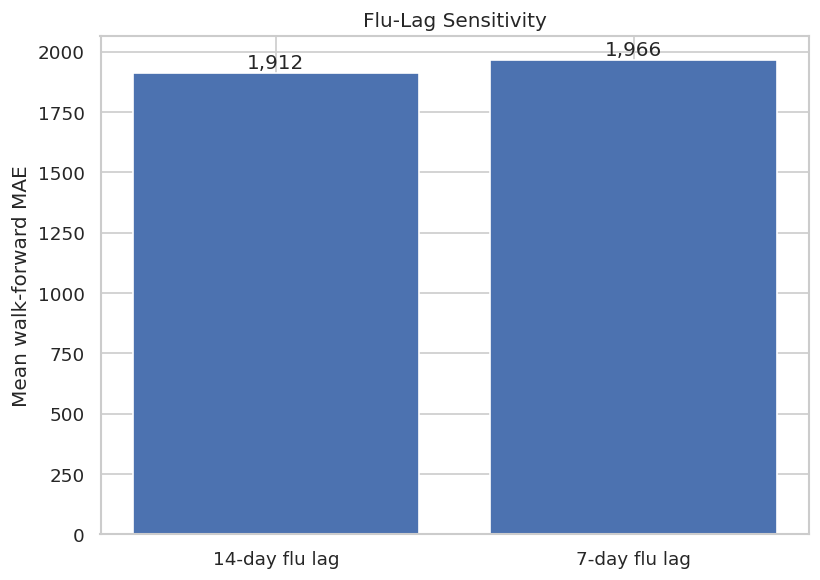

In [101]:
# Flu-lag sensitivity chart

plt.figure(figsize=(7, 5))
bars = plt.bar(flu_sensitivity["Scenario"], flu_sensitivity["MAE_Mean"])

for bar, value in zip(bars, flu_sensitivity["MAE_Mean"]):
    plt.text(bar.get_x() + bar.get_width() / 2, value + 20, f"{value:,.0f}", ha="center")

plt.title("Flu-Lag Sensitivity")
plt.ylabel("Mean walk-forward MAE")
plt.tight_layout()
plt.savefig(Figures / "24_flu_lag_sensitivity.png", dpi=180, bbox_inches="tight")
plt.show()

In [102]:
# Summarise flu-lag sensitivity

flu_best = flu_sensitivity.sort_values("MAE_Mean").iloc[0]
flu_other = flu_sensitivity.sort_values("MAE_Mean").iloc[1]
print("Better flu-lag scenario:", flu_best["Scenario"], round(flu_best["MAE_Mean"], 2))
print("Alternative scenario:", flu_other["Scenario"], round(flu_other["MAE_Mean"], 2))

Better flu-lag scenario: 14-day flu lag 1911.91
Alternative scenario: 7-day flu lag 1965.51


## **20.3 Partial Reporting Sensitivity**

The primary test metrics exclude dates already identified as partial reporting because their national total is not a reliable ground truth.

For transparency, the selected model is also scored against the raw reported totals for all test dates. This secondary result is not treated as the main accuracy estimate.

In [103]:
# Compare trusted-target scoring with all raw reported dates

complete_mask = test_predictions["model_A01"].notna()
all_reported_mask = test_predictions["reported_A01"].notna()

complete_metrics = forecast_metrics(test_predictions.loc[complete_mask, "model_A01"], test_predictions.loc[complete_mask, selected_model], test_mae_scale, test_mse_scale)
raw_metrics = forecast_metrics(test_predictions.loc[all_reported_mask, "reported_A01"], test_predictions.loc[all_reported_mask, selected_model], test_mae_scale, test_mse_scale)

partial_sensitivity = pd.DataFrame([
    ["Complete reporting dates only", int(complete_mask.sum()), complete_metrics["MAE"], complete_metrics["RMSE"]],
    ["All raw reported dates", int(all_reported_mask.sum()), raw_metrics["MAE"], raw_metrics["RMSE"]]
], columns=["Scenario", "Days", "MAE", "RMSE"])

display(partial_sensitivity.round(2))
partial_sensitivity.to_csv(Saved_Outputs / "partial_reporting_sensitivity.csv", index=False)

,Scenario,Days,MAE,RMSE
0,Complete reporting dates only,278,2044.49,3317.07
1,All raw reported dates,280,2091.83,3407.01


In [104]:
# Summarise partial-reporting sensitivity

complete_row = partial_sensitivity.iloc[0]
all_row = partial_sensitivity.iloc[1]
print("Complete-reporting dates MAE:", round(complete_row["MAE"], 2))
print("All raw reported dates MAE:", round(all_row["MAE"], 2))

Complete-reporting dates MAE: 2044.49
All raw reported dates MAE: 2091.83


# **21. Prediction Uncertainty**

Point forecasts do not show how uncertain a prediction is. A 90% residual-based interval is therefore created using absolute out-of-fold errors from the selected model.

The interval is calibrated using training-period forecast errors only and then applied to the final test predictions. Because time-series errors are dependent, the interval is treated as an empirical conformal-style interval rather than claiming perfect exchangeability.

In [105]:
# Calibrate a 90% interval from training OOF errors

selected_oof = comparison_oof[comparison_oof["Model"] == selected_model].copy()
calibration_errors = np.abs(selected_oof["Actual"] - selected_oof["Predicted"])
q90 = np.quantile(calibration_errors, 0.90, method="higher")

test_predictions["Lower_90"] = np.maximum(0, test_predictions[selected_model] - q90)
test_predictions["Upper_90"] = test_predictions[selected_model] + q90

coverage_mask = test_predictions["model_A01"].notna()
inside = (
    (test_predictions.loc[coverage_mask, "model_A01"] >= test_predictions.loc[coverage_mask, "Lower_90"]) &
    (test_predictions.loc[coverage_mask, "model_A01"] <= test_predictions.loc[coverage_mask, "Upper_90"])
)

interval_summary = pd.DataFrame({
    "Nominal_Coverage": [0.90],
    "Empirical_Coverage": [inside.mean()],
    "Interval_Half_Width": [q90],
    "Scored_Days": [int(coverage_mask.sum())]
})

display(interval_summary.round(4))

test_predictions.to_csv(Saved_Outputs / "final_test_predictions_with_intervals.csv", index=False)
interval_summary.to_csv(Saved_Outputs / "prediction_interval_summary.csv", index=False)

,Nominal_Coverage,Empirical_Coverage,Interval_Half_Width,Scored_Days
0,0.9,0.8993,4134.7273,278


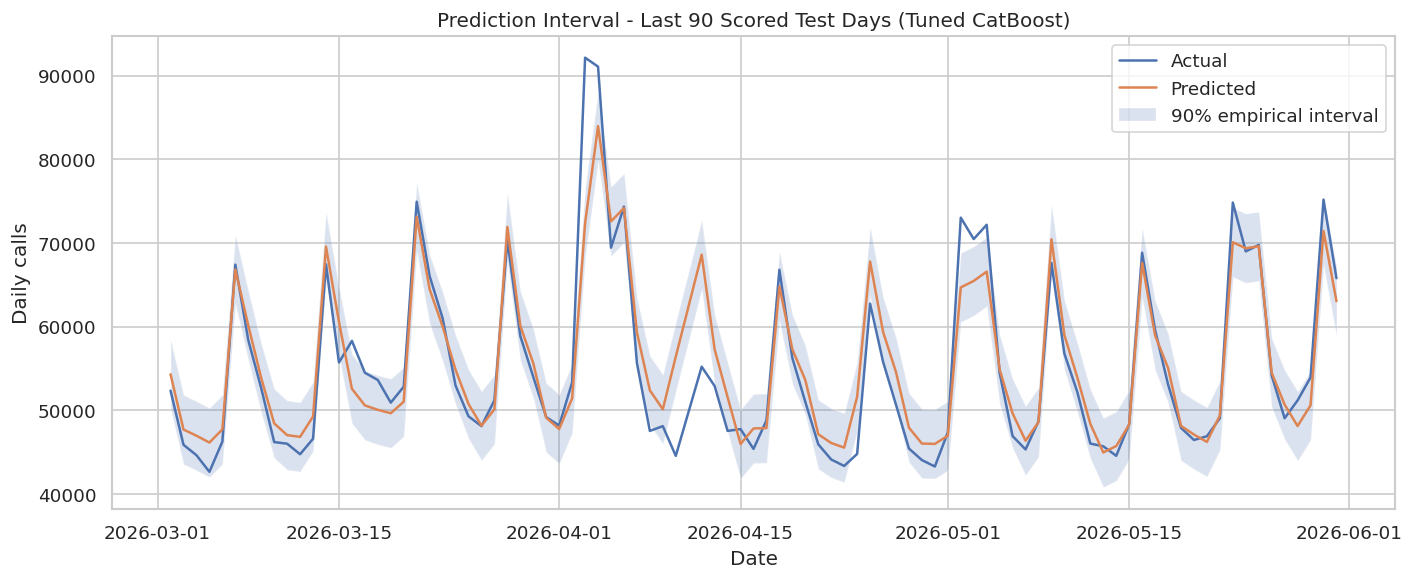

In [106]:
# Show the final 90 scored test days with the empirical interval

interval_plot = test_predictions[test_predictions["model_A01"].notna()].tail(90).copy()

plt.figure(figsize=(12, 5))
plt.plot(interval_plot["Date"], interval_plot["model_A01"], label="Actual")
plt.plot(interval_plot["Date"], interval_plot[selected_model], label="Predicted")
plt.fill_between(interval_plot["Date"], interval_plot["Lower_90"], interval_plot["Upper_90"], alpha=0.2, label="90% empirical interval")
plt.title(f"Prediction Interval - Last 90 Scored Test Days ({selected_model})")
plt.xlabel("Date")
plt.ylabel("Daily calls")
plt.legend()
plt.tight_layout()
plt.savefig(Figures / "25_prediction_interval.png", dpi=180, bbox_inches="tight")
plt.show()

In [ ]:
# Summarise prediction-interval coverage

required_interval_columns = [
    "Nominal_Coverage",
    "Empirical_Coverage",
    "Interval_Half_Width",
    "Scored_Days"
]

missing_interval_columns = [
    column for column in required_interval_columns
    if column not in interval_summary.columns
]

if missing_interval_columns:
    raise ValueError(
        f"Missing prediction interval columns: {missing_interval_columns}"
    )

interval_row = interval_summary.iloc[0]

print(
    "Nominal coverage (%):",
    round(interval_row["Nominal_Coverage"] * 100, 1)
)

print(
    "Empirical coverage (%):",
    round(interval_row["Empirical_Coverage"] * 100, 1)
)

print(
    "Interval half-width:",
    round(interval_row["Interval_Half_Width"], 2)
)

print(
    "Scored days:",
    int(interval_row["Scored_Days"])
)

# **22. Saving the Models and Final Outputs**

The selected forecasting model, the best boosting model, feature list and final result summaries are saved to Google Drive.

The best boosting model is saved separately because it is the model used for SHAP and factor interpretation even if a classical time-series model wins the overall forecasting comparison.

In [ ]:
# Save the best boosting model

joblib.dump(interpretability_model, Models / "best_boosting_model.joblib")
joblib.dump(ml_features, Models / "ml_features.joblib")

# Save the pre-selected overall model

if selected_model in final_ml_models:
    selected_object = final_ml_models[selected_model]
elif selected_model == "Prophet":
    selected_object = final_prophet
elif selected_model == "SARIMAX":
    selected_object = final_sarimax_result
else:
    selected_object = None

if selected_object is not None:
    joblib.dump(selected_object, Models / "selected_forecasting_model.joblib")

selected_test_metrics = test_leaderboard[test_leaderboard["Model"] == selected_model].copy()

model_summary = pd.DataFrame({
    "Selected_Model": [selected_model],
    "Best_Boosting_Model": [best_boosting],
    "Forecast_Horizon": ["1 day ahead"],
    "Training_Start": [train_calendar["Date"].min()],
    "Training_End": [train_calendar["Date"].max()],
    "Test_Start": [test_calendar["Date"].min()],
    "Test_End": [test_calendar["Date"].max()],
    "Test_MAE": [selected_test_metrics["MAE"].iloc[0]],
    "Test_RMSE": [selected_test_metrics["RMSE"].iloc[0]],
    "Test_R2": [selected_test_metrics["R2"].iloc[0]],
    "Interval_90_Coverage": [inside.mean()]
})

display(model_summary.round(3))
model_summary.to_csv(Saved_Outputs / "final_model_summary.csv", index=False)

print("Models and final outputs saved to:", Saved_Outputs)

# **23. Simple Streamlit Evaluation Interface**

A simple Python Streamlit interface is created for dissertation evaluation. It displays the held-out predictions, model comparison and prediction interval without changing the model.

The app is saved as a Python file in Google Drive. It is separate from the notebook but remains in the same programming language.

In [ ]:
# Create the final one-page Streamlit forecasting app

app_code = """
from pathlib import Path
import pandas as pd
import streamlit as st

BASE = Path(__file__).parent

pred = pd.read_csv(
    BASE / "final_test_predictions_with_intervals.csv",
    parse_dates=["Date"]
)

summary = pd.read_csv(
    BASE / "final_model_summary.csv"
)

selected_model = summary.loc[0, "Selected_Model"]

available = pred[
    pred["model_A01"].notna() &
    pred[selected_model].notna() &
    pred["Lower_90"].notna() &
    pred["Upper_90"].notna()
].copy()

available = available.sort_values("Date").reset_index(drop=True)

st.set_page_config(
    page_title="NHS 111 England Forecast",
    layout="centered"
)

st.title("NHS 111 Daily Call Demand Forecast — England")

st.write(
    "This tool shows one-day-ahead forecasts for the total number "
    "of NHS 111 calls across England during the held-out evaluation period."
)

if available.empty:
    st.error("No complete held-out forecast dates are available.")
    st.stop()

valid_dates = available["Date"].dt.strftime("%d %B %Y").tolist()

st.info(
    f"Available evaluation dates: "
    f"{available['Date'].min().strftime('%d %B %Y')} to "
    f"{available['Date'].max().strftime('%d %B %Y')}. "
    "Known partial-reporting targets are excluded."
)

selected_text = st.selectbox(
    "Select a forecast date",
    valid_dates
)

selected_date = pd.to_datetime(
    selected_text,
    format="%d %B %Y"
)

row = available[
    available["Date"] == selected_date
].iloc[0]

predicted = float(row[selected_model])
actual = float(row["model_A01"])
lower = float(row["Lower_90"])
upper = float(row["Upper_90"])
absolute_error = abs(actual - predicted)

st.subheader("Forecast result")

col1, col2 = st.columns(2)

col1.metric(
    "Predicted calls",
    f"{predicted:,.0f}"
)

col2.metric(
    "Actual reported calls",
    f"{actual:,.0f}"
)

col3, col4 = st.columns(2)

col3.metric(
    "Absolute error",
    f"{absolute_error:,.0f} calls"
)

col4.metric(
    "90% prediction interval",
    f"{lower:,.0f} to {upper:,.0f}"
)

st.caption(
    "The interval uses the 90th percentile of absolute one-day-ahead "
    "errors from training-period walk-forward validation."
)

chart_start = selected_date - pd.Timedelta(days=28)

chart = available[
    (available["Date"] >= chart_start) &
    (available["Date"] <= selected_date)
][
    ["Date", "model_A01", selected_model]
].copy()

chart = chart.set_index("Date")

chart.columns = [
    "Actual calls",
    "Predicted calls"
]

st.subheader("Recent actual and predicted demand")

st.line_chart(chart)

st.caption(
    f"Forecasting area: England. Model used: {selected_model}. "
    "The selectable dates are held-out evaluation dates."
)
"""

app_path = Saved_Outputs / "streamlit_app.py"

app_path.write_text(app_code)

print(
    "Final one-page Streamlit app saved to:",
    app_path
)

# **24. Final Research Outputs**

The final tables below bring together the three parts of the research question:

- how accurately daily NHS 111 demand can be forecast;
- whether the selected model improves on the seasonal baseline;
- which groups of factors contribute most to predictive performance.

The factor results must be interpreted as predictive associations rather than proof of causation.

In [ ]:
# Final forecasting comparison

print("Selected model:")
print(selected_model)

print("\nFinal held-out performance:")
display(selected_test_metrics.round(3))

print("\nComparison with seasonal naive:")
display(test_leaderboard[test_leaderboard["Model"].isin([selected_model, "Seasonal Naive"])].round(3))

print("\nFeature-group influence:")
display(ablation_results.round(2))

print("\nTop SHAP features:")
display(shap_importance.head(10).round(3))

print("\nAll outputs saved to:")
print(Saved_Outputs)

# Save the frozen feature set used by the final boosting models

pd.DataFrame({"Selected_Feature": ml_features}).to_csv(
    Saved_Outputs / "final_selected_features.csv",
    index=False
)

print("Final selected feature count:", len(ml_features))


In [ ]:
# Final result summary

selected_row = test_leaderboard[test_leaderboard["Model"] == selected_model].iloc[0]
numeric_best = test_leaderboard.iloc[0]
print("FINAL RESULT SUMMARY")
print("Selected model:", selected_model)
print("Held-out MAE:", round(selected_row["MAE"], 2))
print("Held-out RMSE:", round(selected_row["RMSE"], 2))
print("Held-out R2:", round(selected_row["R2"], 3))
print("Lowest numerical held-out MAE:", numeric_best["Model"], round(numeric_best["MAE"], 2))
print("See the tables and figures above for feature contribution, sensitivity and residual diagnostics.")

# **Methodological Basis**

The final workflow separates the modelling process chronologically:

- a broad leakage-safe candidate feature pool is created;
- early training-only folds are used for feature screening;
- later training-only folds are used for Optuna hyperparameter tuning;
- the latest training-period folds are used for model comparison and selection;
- the held-out test is evaluated only after those decisions are frozen.

The project remains a regression and time-series forecasting problem. MAE is the primary error measure, supported by RMSE, Mean Error, R², MASE and RMSSE.

Residual diagnostics, feature interpretation, sensitivity analysis and empirical prediction-interval coverage are reported after model selection.

# **End of Notebook**

This workflow keeps data preparation, chronological model development, final testing, interpretability and sensitivity analysis separate.

The final comparison uses a one-day-ahead forecasting design. Prophet, SARIMAX, the seasonal baseline and boosting models therefore answer the same operational question.

Known reporting-quality problems remain transparent. Same-day observed weather, same-day flu values and post-reporting quality information are excluded from the forecasting features.

Any large holiday errors or remaining residual autocorrelation found after final testing are reported as limitations and future work rather than being used to retrospectively improve the model.

# **Final Prototype Design**

The application is intentionally simple. It demonstrates the forecasting task directly:

- select a valid historical forecast date;
- view the England-wide predicted NHS 111 call volume;
- compare it with the actual reported value;
- inspect the absolute error;
- view the 90% empirical prediction interval;
- see the recent actual and predicted demand pattern.

The selectable dates are restricted to the held-out period because these are the dates for which the full model inputs and actual outcomes are available for a fair demonstration.

# **25. Launch the Final Streamlit App**

The Streamlit app is now a single-page forecasting interface for England.

The user selects a date from the held-out evaluation period. The app shows the model prediction, the actual reported call volume, the absolute error and the 90% empirical prediction interval.

The first cell starts the Streamlit server. The second cell prints the LocalTunnel password and creates the temporary web link.

In [ ]:
# Start Streamlit in Google Colab

!pkill -f "streamlit run" || true
!streamlit run "/content/drive/MyDrive/NHS111_Dissertation_Outputs/streamlit_app.py" --server.port 8501 --server.headless true > /content/streamlit.log 2>&1 &
!sleep 3

print("Streamlit server started.")

In [ ]:
# Create the temporary public link

print("Tunnel password:")
!curl -s https://loca.lt/mytunnelpassword

print("\nOpen the loca.lt link printed below:")
!npx --yes localtunnel --port 8501